In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore", category=Warning)

import sys
sys.path.append(f"./../")

from qiskit import transpile
from qiskit.quantum_info import Operator
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from src.core import MultiEdgeGraph, MatchingDecomposition, PauliDecomposition
from src.utils import get_exact_evolution_operator

In [2]:
# Create output directory for plots
output_dir = "trotterization_plots"
os.makedirs(output_dir, exist_ok=True)

# Set up publication-quality plotting style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False  # Set to True if you have LaTeX installed
})

In [3]:
# Global storage for gate count data
gate_count_data = []


def analyze_and_plot(edges, title, output_dir="trotterization_plots", delta_t=0.1):
    """
    Analyze quantum time evolution errors and plot results.
    Compares matching-based, compression-aware matching, and Pauli decomposition methods.

    Args:
        edges: Graph edges (set of tuples of binary strings)
               Example: {('00','01'), ('00','10'), ('00','11')}
        title: Plot title
        output_dir: Directory to save plots (default: "trotterization_plots")
        delta_t: Time step size (default: 0.1)

    Example:
        edges = {('00','01'), ('00','10'), ('00','11')}
        analyze_and_plot(edges, "Tree Graph T4")
    """
    global gate_count_data

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    n_steps_list = [1, 2, 5, 10, 20, 50, 100]

    print(f"\n{title}")
    print("="*60)
    print(f"Original edges: {edges}")

    # Create graph
    G = MultiEdgeGraph(edges)
    print(f"Number of qubits: {G.n_qubits}")

    # Display graph
    print("\nGraph:")
    try:
        display(G.draw())
    except:
        print("(Graph display not available)")

    # Create decomposition objects
    matching_decomp = MatchingDecomposition(G)
    comp_aware_decomp = MatchingDecomposition(G, heuristic='compression_aware', n_trials=30)
    pauli_decomp = PauliDecomposition(G)

    print(f"\nGreedy Matchings: {matching_decomp.num_matchings()}")
    print(f"Compression-Aware Matchings: {comp_aware_decomp.num_matchings()}")

    print(f"Number of qubits: {G.n_qubits}")

    # Hamming cost analysis
    print(f"\nHamming Cost Analysis:")
    print(f"Total = {G.hamming_cost()}, Edges = {G.n_edges}, Per Edge = {G.avg_hamming_cost():.3f}")

    # Display sample circuits (with n_steps=1)
    sample_qc_matching = matching_decomp.build_circuit(1, delta_t)
    print("\nSample Circuit - Greedy Matching (n_steps=1):")
    try:
        display(sample_qc_matching.draw('mpl'))
    except:
        print(sample_qc_matching.draw('text'))

    sample_qc_comp = comp_aware_decomp.build_circuit(1, delta_t)
    print("\nSample Circuit - Compression-Aware Matching (n_steps=1):")
    try:
        display(sample_qc_comp.draw('mpl'))
    except:
        print(sample_qc_comp.draw('text'))

    # Get exact evolution operator
    exact_operator = get_exact_evolution_operator(delta_t, G.hamiltonian)

    # Storage for results
    matching_vs_exact_errors = []
    comp_aware_vs_exact_errors = []
    pauli_vs_exact_errors = []

    matching_cx_no_opt = []
    matching_cx_opt = []
    matching_u3_no_opt = []
    matching_u3_opt = []
    comp_aware_cx_no_opt = []
    comp_aware_cx_opt = []
    comp_aware_u3_no_opt = []
    comp_aware_u3_opt = []
    pauli_cx_no_opt = []
    pauli_cx_opt = []
    pauli_u3_no_opt = []
    pauli_u3_opt = []

    # Analyze each n_steps
    for n_steps in n_steps_list:
        # Build greedy matching circuit
        matching_qc = matching_decomp.build_circuit(n_steps, delta_t)
        transpiled_matching_no_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_matching_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        matching_operator = Operator(transpiled_matching_opt)

        matching_counts_no_opt = transpiled_matching_no_opt.count_ops()
        matching_counts_opt = transpiled_matching_opt.count_ops()

        matching_cx_no_opt.append(matching_counts_no_opt.get('cx', 0))
        matching_cx_opt.append(matching_counts_opt.get('cx', 0))
        matching_u3_no_opt.append(matching_counts_no_opt.get('u3', 0))
        matching_u3_opt.append(matching_counts_opt.get('u3', 0))

        # Build compression-aware matching circuit
        comp_qc = comp_aware_decomp.build_circuit(n_steps, delta_t)
        transpiled_comp_no_opt = transpile(comp_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_comp_opt = transpile(comp_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        comp_operator = Operator(transpiled_comp_opt)

        comp_counts_no_opt = transpiled_comp_no_opt.count_ops()
        comp_counts_opt = transpiled_comp_opt.count_ops()

        comp_aware_cx_no_opt.append(comp_counts_no_opt.get('cx', 0))
        comp_aware_cx_opt.append(comp_counts_opt.get('cx', 0))
        comp_aware_u3_no_opt.append(comp_counts_no_opt.get('u3', 0))
        comp_aware_u3_opt.append(comp_counts_opt.get('u3', 0))

        # Build Pauli circuit
        pauli_qc = pauli_decomp.build_circuit(n_steps, delta_t)
        transpiled_pauli_no_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_pauli_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        pauli_operator = Operator(pauli_qc)

        pauli_counts_no_opt = transpiled_pauli_no_opt.count_ops()
        pauli_counts_opt = transpiled_pauli_opt.count_ops()

        pauli_cx_no_opt.append(pauli_counts_no_opt.get('cx', 0))
        pauli_cx_opt.append(pauli_counts_opt.get('cx', 0))
        pauli_u3_no_opt.append(pauli_counts_no_opt.get('u3', 0))
        pauli_u3_opt.append(pauli_counts_opt.get('u3', 0))

        # Store gate count data
        gate_count_data.extend([
            {
                'Case': title, 'Method': 'Matching (Greedy)', 'n_steps': n_steps,
                'Optimization': 'No', 'CX_gates': matching_cx_no_opt[-1], 'U3_gates': matching_u3_no_opt[-1]
            },
            {
                'Case': title, 'Method': 'Matching (Greedy)', 'n_steps': n_steps,
                'Optimization': 'Yes', 'CX_gates': matching_cx_opt[-1], 'U3_gates': matching_u3_opt[-1]
            },
            {
                'Case': title, 'Method': 'Matching (Comp-Aware)', 'n_steps': n_steps,
                'Optimization': 'No', 'CX_gates': comp_aware_cx_no_opt[-1], 'U3_gates': comp_aware_u3_no_opt[-1]
            },
            {
                'Case': title, 'Method': 'Matching (Comp-Aware)', 'n_steps': n_steps,
                'Optimization': 'Yes', 'CX_gates': comp_aware_cx_opt[-1], 'U3_gates': comp_aware_u3_opt[-1]
            },
            {
                'Case': title, 'Method': 'Pauli', 'n_steps': n_steps,
                'Optimization': 'No', 'CX_gates': pauli_cx_no_opt[-1], 'U3_gates': pauli_u3_no_opt[-1]
            },
            {
                'Case': title, 'Method': 'Pauli', 'n_steps': n_steps,
                'Optimization': 'Yes', 'CX_gates': pauli_cx_opt[-1], 'U3_gates': pauli_u3_opt[-1]
            }
        ])

        # Calculate errors
        matching_vs_exact = np.linalg.norm(matching_operator - exact_operator, ord=2)
        comp_vs_exact = np.linalg.norm(comp_operator - exact_operator, ord=2)
        pauli_vs_exact = np.linalg.norm(pauli_operator - exact_operator, ord=2)

        matching_vs_exact_errors.append(matching_vs_exact)
        comp_aware_vs_exact_errors.append(comp_vs_exact)
        pauli_vs_exact_errors.append(pauli_vs_exact)

    # Print gate count summary
    print(f"\nGate Count Summary (U3/CX) for {title}:")
    print("="*140)

    table_data = []
    for i, n_steps in enumerate(n_steps_list):
        table_data.append({
            "n_steps": n_steps,
            "Greedy (No Opt)": f"{matching_u3_no_opt[i]}/{matching_cx_no_opt[i]}",
            "Greedy (Opt)": f"{matching_u3_opt[i]}/{matching_cx_opt[i]}",
            "Comp-Aware (No Opt)": f"{comp_aware_u3_no_opt[i]}/{comp_aware_cx_no_opt[i]}",
            "Comp-Aware (Opt)": f"{comp_aware_u3_opt[i]}/{comp_aware_cx_opt[i]}",
            "Pauli (No Opt)": f"{pauli_u3_no_opt[i]}/{pauli_cx_no_opt[i]}",
            "Pauli (Opt)": f"{pauli_u3_opt[i]}/{pauli_cx_opt[i]}"
        })

    df = pd.DataFrame(table_data)
    print(df.to_string(index=False))

    # Print CX improvement summary (n_steps=1, optimized)
    print(f"\n--- CX Summary (n_steps=1, optimized) ---")
    print(f"  Greedy Matching:      {matching_cx_opt[0]} CX")
    print(f"  Comp-Aware Matching:  {comp_aware_cx_opt[0]} CX", end="")
    if matching_cx_opt[0] > 0:
        improv = (1 - comp_aware_cx_opt[0] / matching_cx_opt[0]) * 100
        print(f"  ({improv:+.1f}% vs greedy)")
    else:
        print()
    print(f"  Pauli:                {pauli_cx_opt[0]} CX")

    print(f"\nHamming cost/edge: {G.avg_hamming_cost():.3f}")
    print("="*140)

    # Create error plot (now with 3 lines)
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.loglog(n_steps_list, matching_vs_exact_errors, 'o-',
              label='Matching (Greedy)', linewidth=2.5, markersize=8,
              color='#1f77b4', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#1f77b4')
    ax.loglog(n_steps_list, comp_aware_vs_exact_errors, 'D-',
              label='Matching (Comp-Aware)', linewidth=2.5, markersize=8,
              color='#2ca02c', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#2ca02c')
    ax.loglog(n_steps_list, pauli_vs_exact_errors, 's-',
              label='Pauli', linewidth=2.5, markersize=8,
              color='#d62728', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#d62728')

    ax.set_xlabel('Number of Trotter steps', fontsize=14)
    ax.set_ylabel('2-norm Operator Difference (vs exact CTQW)', fontsize=14)

    plot_title = title.split(":")[1].strip() if ":" in title else title
    ax.set_title(plot_title, fontsize=16, pad=20)

    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=True,
              fancybox=True, shadow=True, ncol=3)

    plt.tight_layout()

    # Save plot
    filename_base = title.lower().replace(" ", "_").replace(":", "").replace(
        "(", "").replace(")", "").replace("-", "_")
    filename_base = "_".join([part for part in filename_base.split("_") if part])
    filename = f"{output_dir}/{filename_base}_error_analysis.pdf"
    plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Error plot saved as: {filename}")

    plt.show()



Cycle Graph C4
Original edges: {('10', '11'), ('01', '11'), ('00', '10'), ('00', '01')}
Number of qubits: 2

Graph:


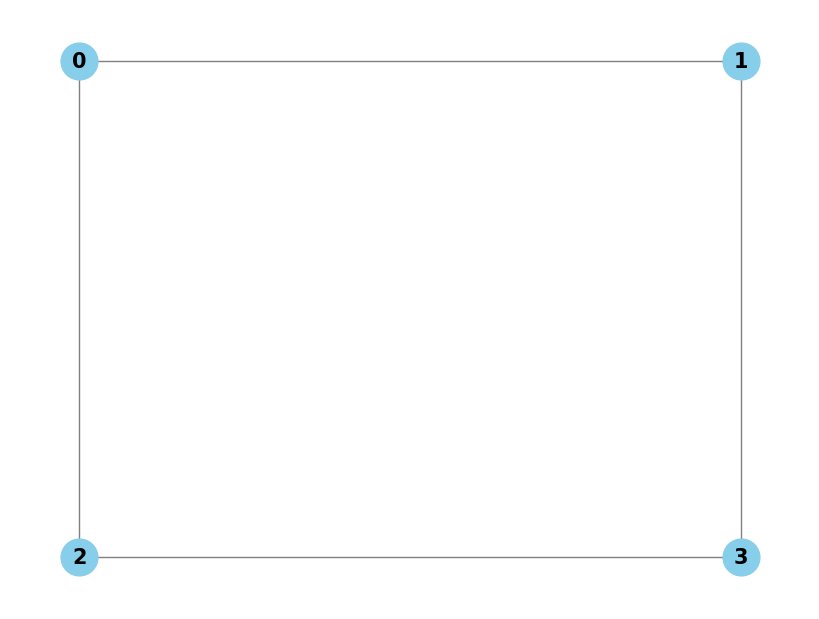

None


Greedy Matchings: 2
Compression-Aware Matchings: 2
Number of qubits: 2

Hamming Cost Analysis:
Total = 4, Edges = 4, Per Edge = 1.000

Sample Circuit - Greedy Matching (n_steps=1):


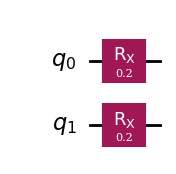


Sample Circuit - Compression-Aware Matching (n_steps=1):


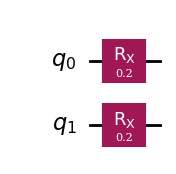


Gate Count Summary (U3/CX) for Cycle Graph C4:
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1             2/0          2/0                 2/0              2/0            2/0         2/0
       2             4/0          2/0                 4/0              2/0            4/0         2/0
       5            10/0          2/0                10/0              2/0           10/0         2/0
      10            20/0          2/0                20/0              2/0           20/0         2/0
      20            40/0          2/0                40/0              2/0           40/0         2/0
      50           100/0          2/0               100/0              2/0          100/0         2/0
     100           200/0          2/0               200/0              2/0          200/0         2/0

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      0 CX
  Comp-Aware Matching:  0 CX
  Pauli:                0 CX

Hammi

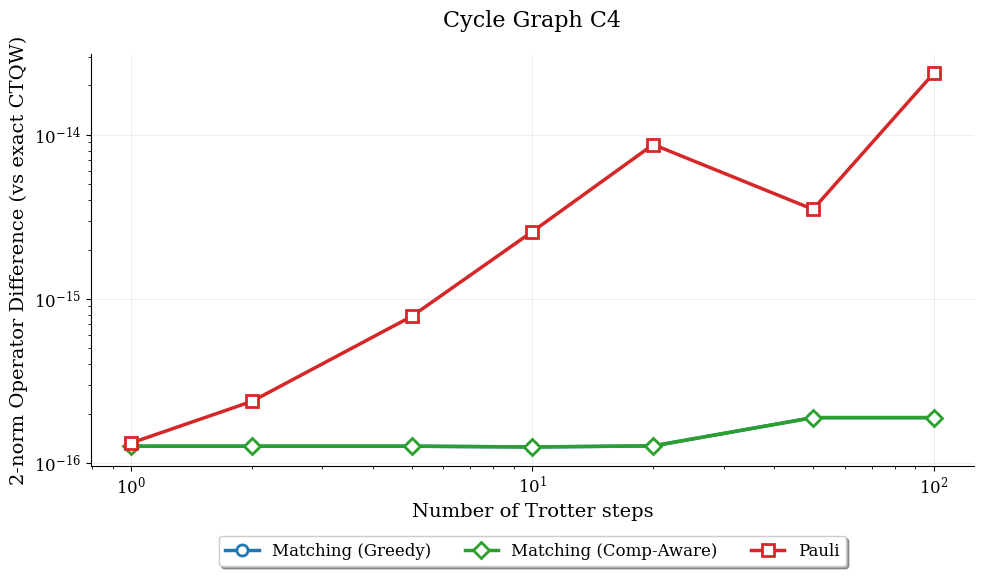

In [4]:
edges = {('00', '10'), ('01', '11'), ('10', '11'), ('00', '01')}
analyze_and_plot(edges, "Cycle Graph C4")


Complete Graph K4 - C2
Original edges: {('01', '11'), ('00', '01'), ('01', '10'), ('00', '11'), ('00', '10')}
Number of qubits: 2

Graph:


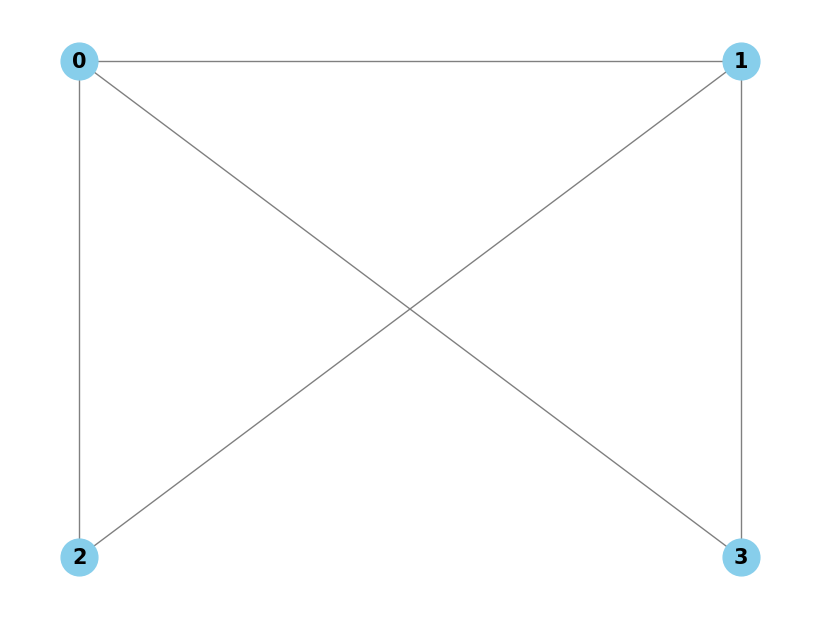

None


Greedy Matchings: 3
Compression-Aware Matchings: 3
Number of qubits: 2

Hamming Cost Analysis:
Total = 7, Edges = 5, Per Edge = 1.400

Sample Circuit - Greedy Matching (n_steps=1):


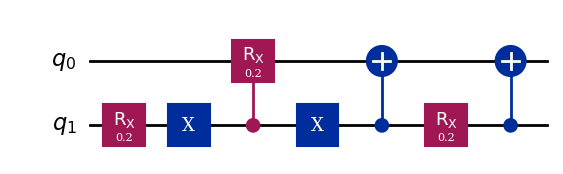


Sample Circuit - Compression-Aware Matching (n_steps=1):


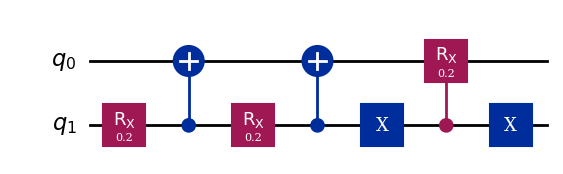


Gate Count Summary (U3/CX) for Complete Graph K4 - C2:
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1             7/4          6/2                 7/4              6/2           10/4         6/2
       2            14/8          6/2                14/8              6/2           20/8         6/2
       5           35/20          6/2               35/20              6/2          50/20         6/2
      10           70/40          6/2               70/40              6/2         100/40         6/2
      20          140/80          6/2              140/80              6/2         200/80         6/2
      50         350/200          6/2             350/200              6/2        500/200         6/2
     100         700/400          6/2             700/400              6/2       1000/400         6/2

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      2 CX
  Comp-Aware Matching:  2 CX  (+0.0% vs greedy)
  Pauli:

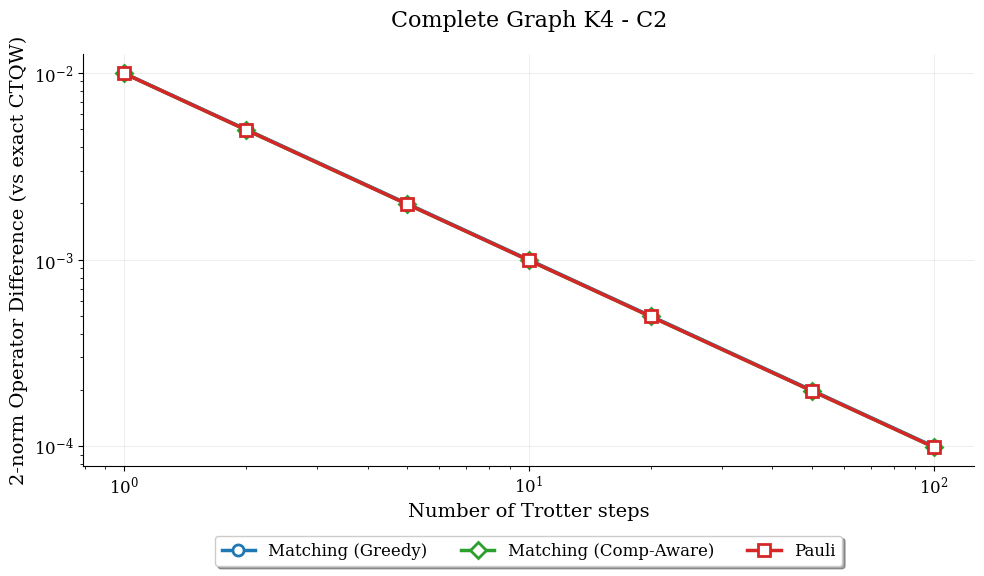

In [5]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11'), ('00', '01')}
analyze_and_plot(edges, "Complete Graph K4 - C2")


Path Graph P3
Original edges: {('10', '11'), ('00', '01'), ('01', '10')}
Number of qubits: 2

Graph:


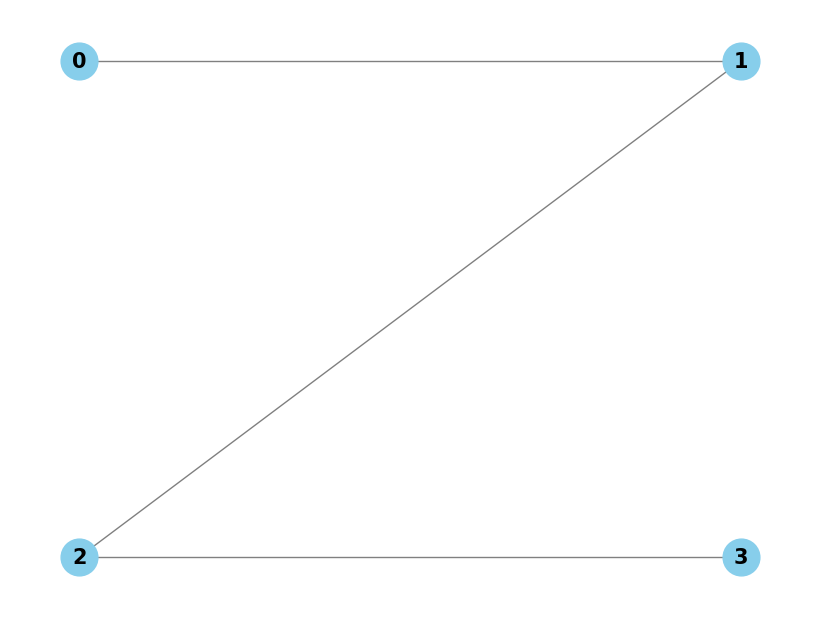

None


Greedy Matchings: 2
Compression-Aware Matchings: 2
Number of qubits: 2

Hamming Cost Analysis:
Total = 4, Edges = 3, Per Edge = 1.333

Sample Circuit - Greedy Matching (n_steps=1):


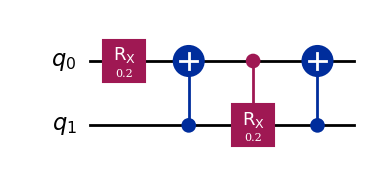


Sample Circuit - Compression-Aware Matching (n_steps=1):


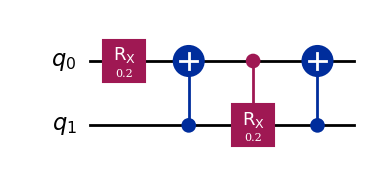


Gate Count Summary (U3/CX) for Path Graph P3:
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1             4/4          6/2                 4/4              6/2           11/4         6/2
       2             8/8          6/2                 8/8              6/2           22/8         6/2
       5           20/20          6/2               20/20              6/2          55/20         6/2
      10           40/40          6/2               40/40              6/2         110/40         6/2
      20           80/80          6/2               80/80              6/2         220/80         6/2
      50         200/200          6/2             200/200              6/2        550/200         6/2
     100         400/400          6/2             400/400              6/2       1100/400         6/2

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      2 CX
  Comp-Aware Matching:  2 CX  (+0.0% vs greedy)
  Pauli:         

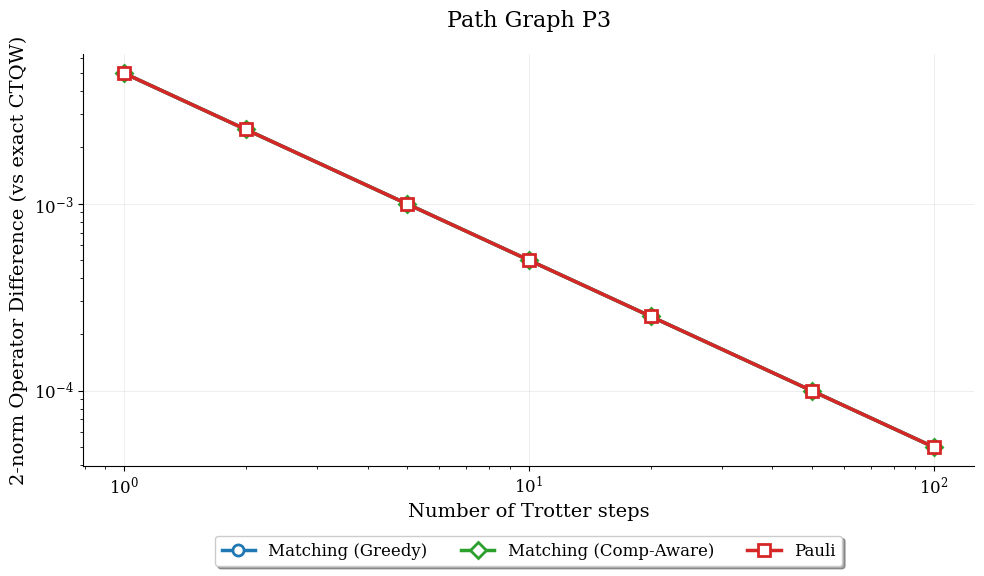

In [6]:
edges = {('00', '01'), ('01', '10'), ('10', '11')}
analyze_and_plot(edges, "Path Graph P3")


Tree Graph (2 qubits)
Original edges: {('00', '11'), ('00', '01'), ('00', '10')}
Number of qubits: 2

Graph:


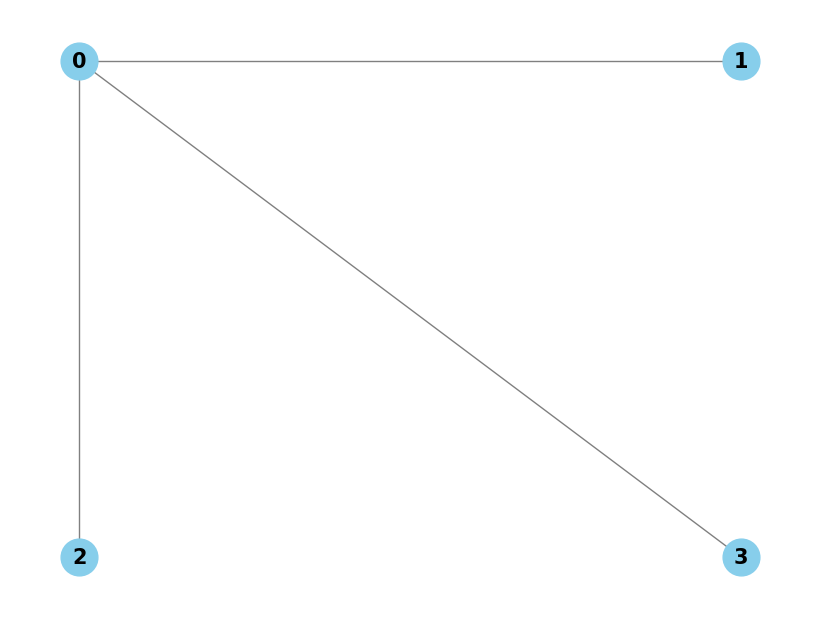

None


Greedy Matchings: 3
Compression-Aware Matchings: 3
Number of qubits: 2

Hamming Cost Analysis:
Total = 4, Edges = 3, Per Edge = 1.333

Sample Circuit - Greedy Matching (n_steps=1):


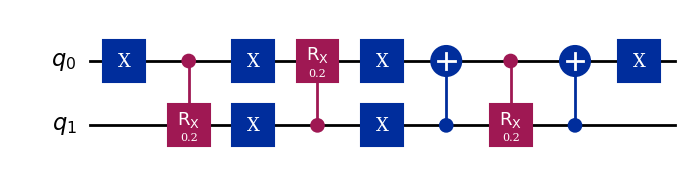


Sample Circuit - Compression-Aware Matching (n_steps=1):


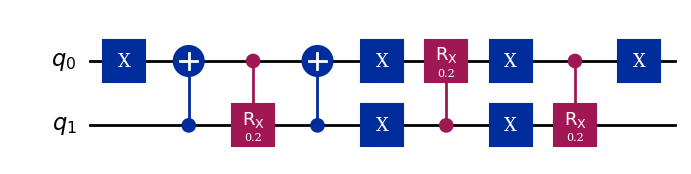


Gate Count Summary (U3/CX) for Tree Graph (2 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1            15/8          8/3                15/8              8/3           18/8         8/3
       2           30/16          8/3               30/16              8/3          36/16         8/3
       5           75/40          8/3               75/40              8/3          90/40         8/3
      10          150/80          8/3              150/80              8/3         180/80         8/3
      20         300/160          8/3             300/160              8/3        360/160         8/3
      50         750/400          8/3             750/400              8/3        900/400         8/3
     100        1500/800          8/3            1500/800              8/3       1800/800         8/3

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      3 CX
  Comp-Aware Matching:  3 CX  (+0.0% vs greedy)
  Pauli: 

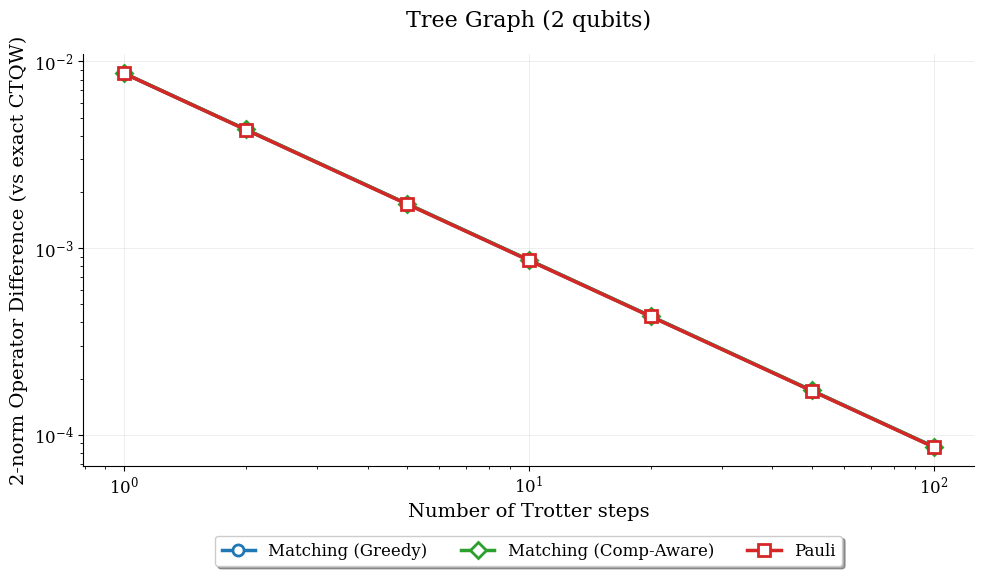

In [7]:
edges = {('00','01'), ('00','10'), ('00','11')}
analyze_and_plot(edges, "Tree Graph (2 qubits)")


Tree Graph (3 qubits)
Original edges: {('000', '101'), ('000', '010'), ('000', '100'), ('000', '001'), ('000', '011'), ('000', '111'), ('000', '110')}
Number of qubits: 3

Graph:


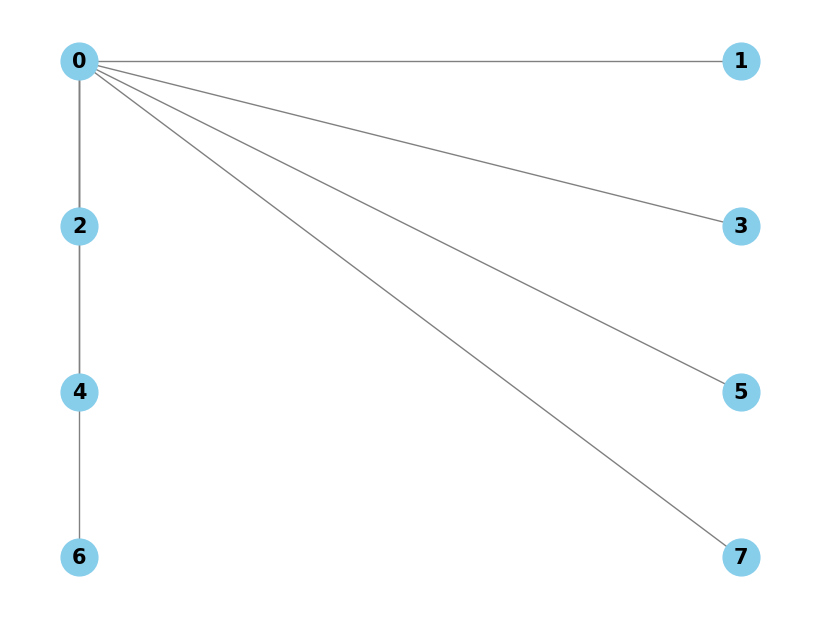

None


Greedy Matchings: 7
Compression-Aware Matchings: 7
Number of qubits: 3

Hamming Cost Analysis:
Total = 12, Edges = 7, Per Edge = 1.714

Sample Circuit - Greedy Matching (n_steps=1):


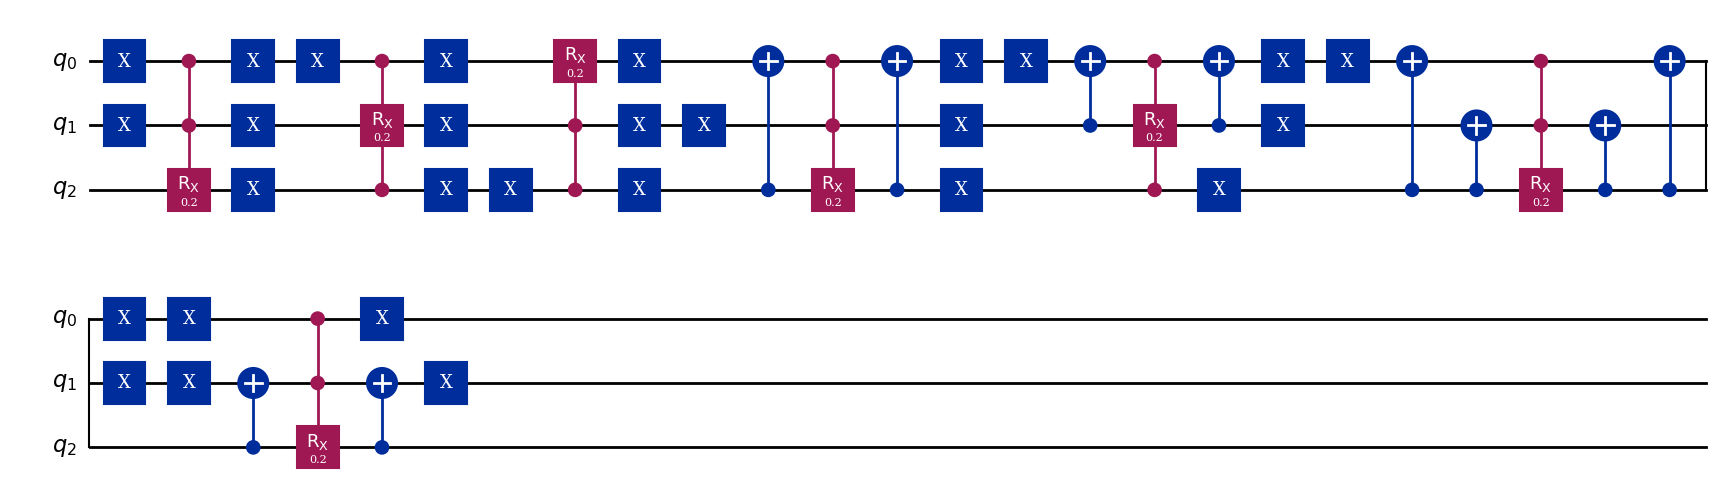


Sample Circuit - Compression-Aware Matching (n_steps=1):


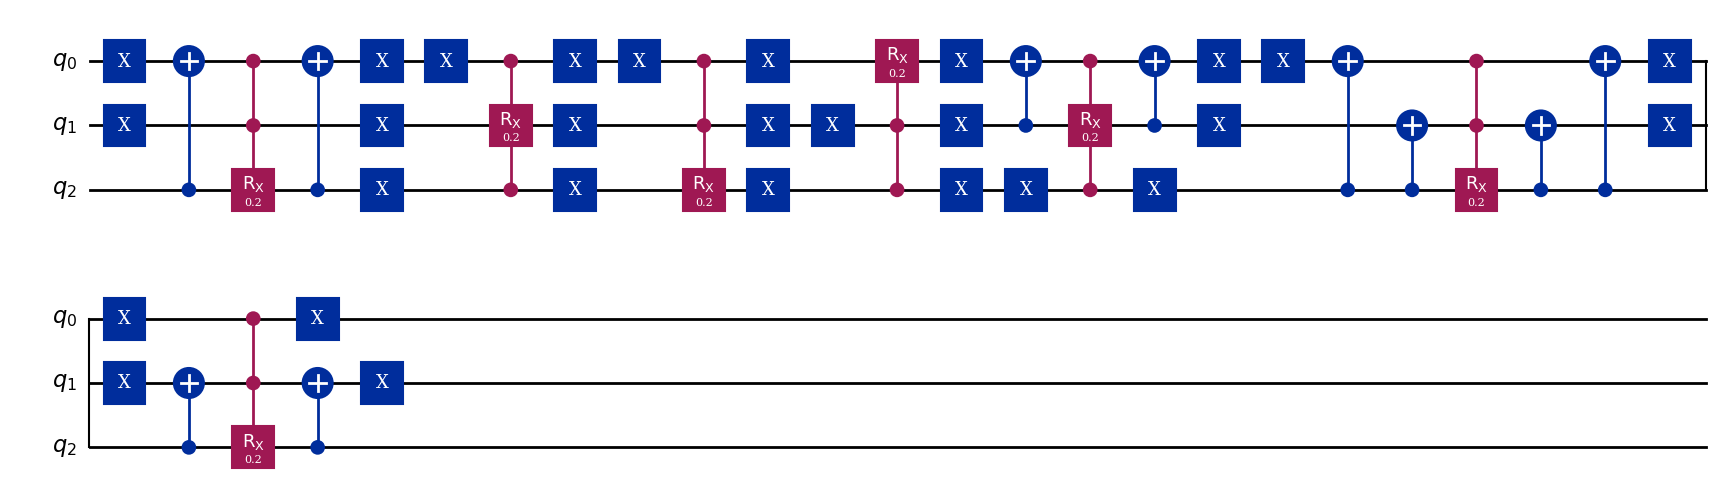


Gate Count Summary (U3/CX) for Tree Graph (3 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1          133/66        66/60              133/66            66/57         118/76       55/30
       2         266/132      130/119             266/132          128/114        236/152      109/60
       5         665/330      322/296             665/330          314/285        590/380     271/150
      10        1330/660      642/591            1330/660          624/570       1180/760     541/300
      20       2660/1320    1282/1181           2660/1320        1244/1140      2360/1520    1081/600
      50       6650/3300    3202/2951           6650/3300        3104/2850      5900/3800   2651/1500
     100      13300/6600    6402/5901          13300/6600        6204/5700     11800/7600   5401/3000

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      60 CX
  Comp-Aware Matching:  57 CX  (+5.0% vs greedy)
  Pauli

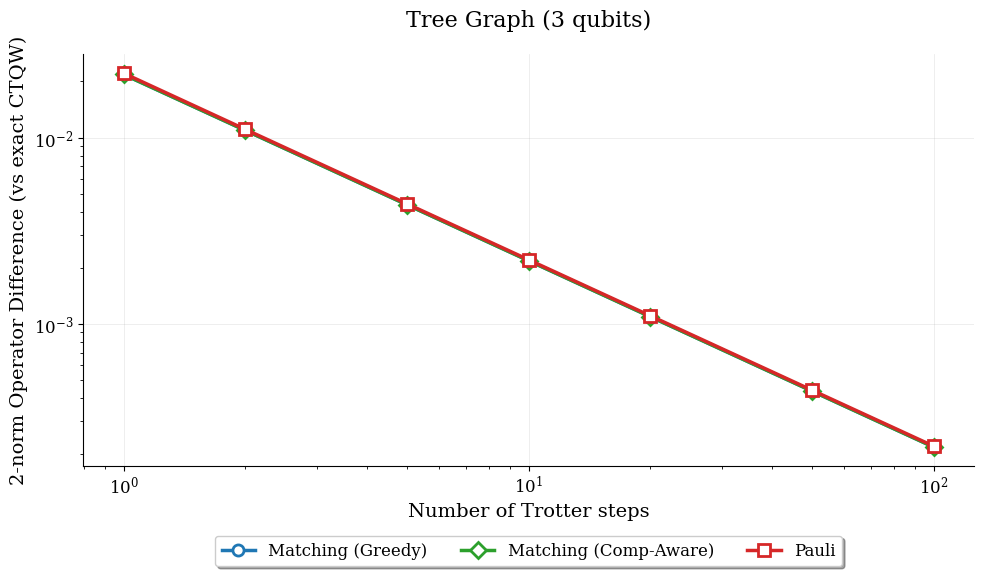

In [8]:
edges = {('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'), ('000','111')}
analyze_and_plot(edges, "Tree Graph (3 qubits)")


Dense Non-Bipartite Graph (3 qubits)
Original edges: {('000', '010'), ('001', '100'), ('100', '111'), ('000', '001'), ('001', '111'), ('001', '011'), ('110', '111'), ('011', '101'), ('000', '110'), ('000', '100'), ('010', '110'), ('100', '101'), ('000', '011'), ('101', '110'), ('010', '100'), ('001', '101'), ('010', '011'), ('010', '111'), ('101', '111'), ('000', '101'), ('011', '100'), ('001', '010'), ('100', '110'), ('011', '111')}
Number of qubits: 3

Graph:


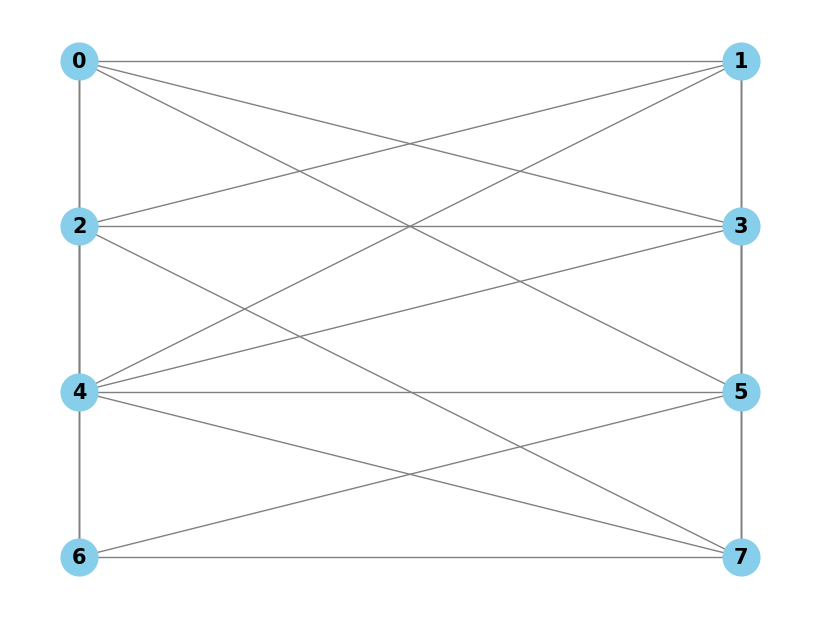

None


Greedy Matchings: 7
Compression-Aware Matchings: 7
Number of qubits: 3

Hamming Cost Analysis:
Total = 37, Edges = 24, Per Edge = 1.542

Sample Circuit - Greedy Matching (n_steps=1):


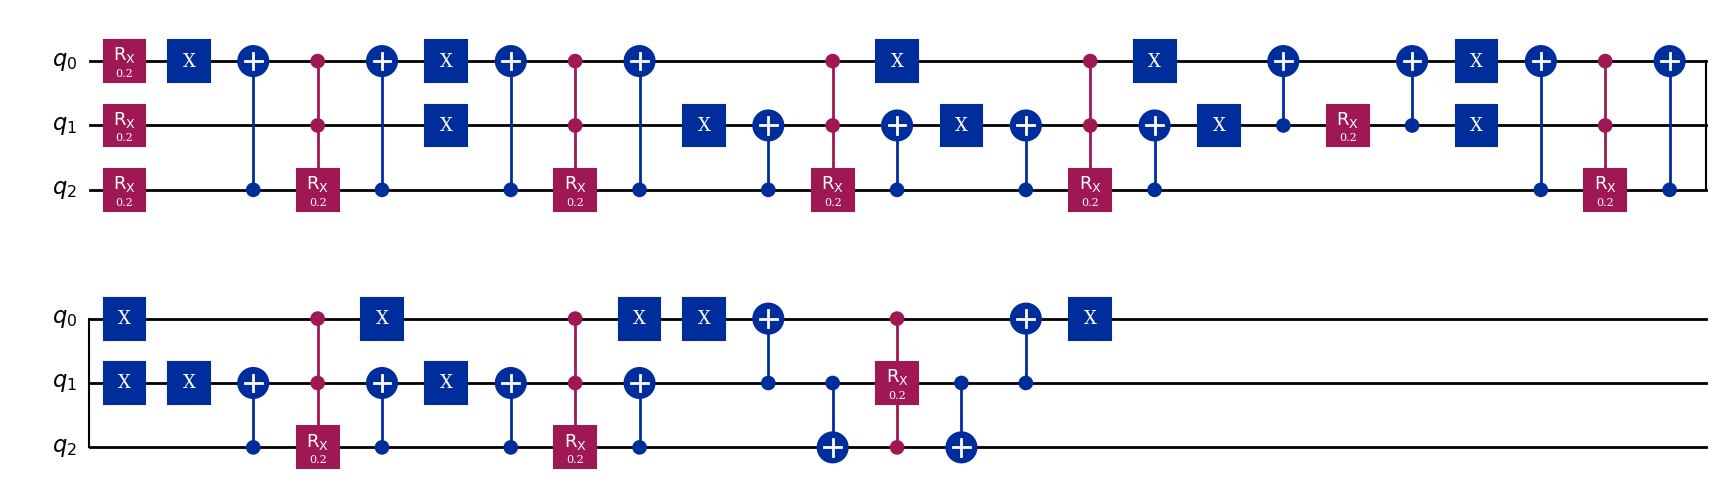


Sample Circuit - Compression-Aware Matching (n_steps=1):


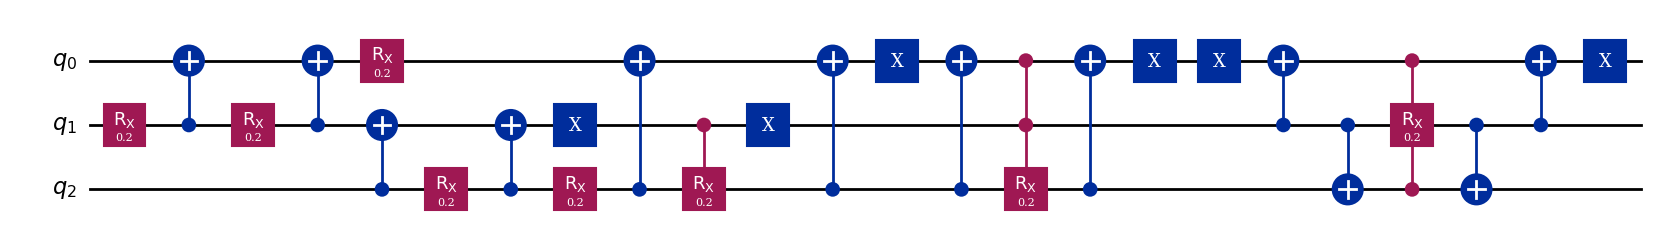


Gate Count Summary (U3/CX) for Dense Non-Bipartite Graph (3 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1          142/84        79/73               44/30            27/24          61/32       32/20
       2         284/168      157/146               88/60            56/46         122/64       60/40
       5         710/420      391/365             220/150          140/112        305/160     147/100
      10        1420/840      781/730             440/300          280/222        610/320     292/200
      20       2840/1680    1561/1460             880/600          560/442       1220/640     582/400
      50       7100/4200    3901/3650           2200/1500        1400/1102      3050/1600   1502/1000
     100      14200/8400    7801/7300           4400/3000        2800/2202      6100/3200   3002/2000

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      73 CX
  Comp-Aware Matching:  24 CX  (+67.1% vs

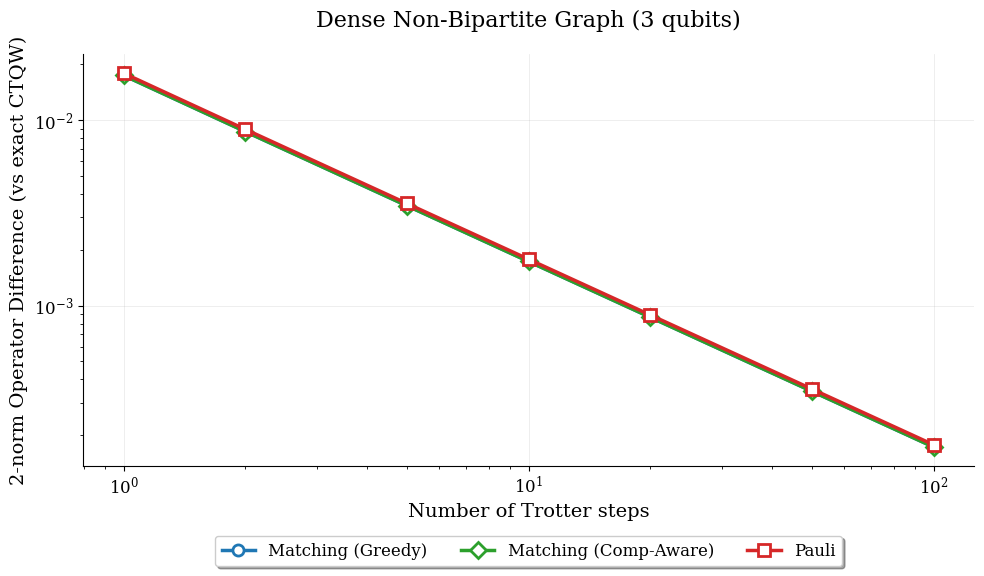

In [9]:
dense_nonbipartite_8 = {
    ('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'),
    ('001','010'), ('001','011'), ('001','100'), ('001','101'), ('001','111'),
    ('010','011'), ('010','100'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','111'),
    ('100','101'), ('100','110'), ('100','111'),
    ('101','110'), ('101','111'),
    ('110','111')
}

analyze_and_plot(dense_nonbipartite_8, "Dense Non-Bipartite Graph (3 qubits)")


Dense Bipartite Graph (3 qubits)
Original edges: {('001', '100'), ('001', '111'), ('011', '101'), ('000', '110'), ('000', '100'), ('010', '110'), ('000', '111'), ('010', '100'), ('001', '101'), ('010', '111'), ('011', '111'), ('011', '110'), ('000', '101'), ('011', '100'), ('010', '101'), ('001', '110')}
Number of qubits: 3

Graph:


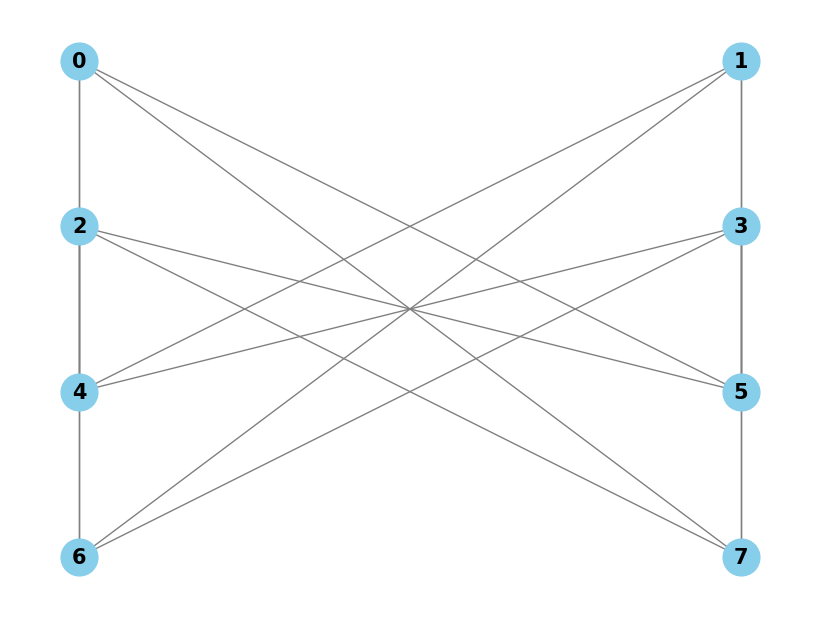

None


Greedy Matchings: 4
Compression-Aware Matchings: 4
Number of qubits: 3

Hamming Cost Analysis:
Total = 32, Edges = 16, Per Edge = 2.000

Sample Circuit - Greedy Matching (n_steps=1):


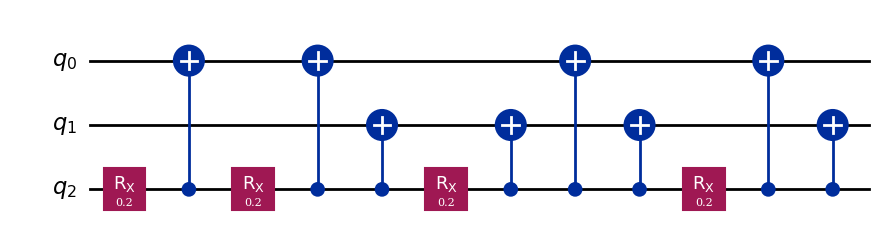


Sample Circuit - Compression-Aware Matching (n_steps=1):


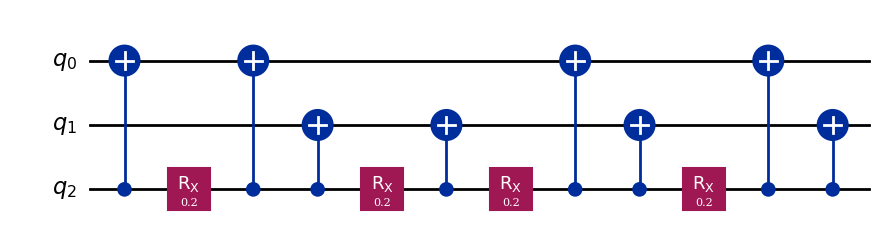


Gate Count Summary (U3/CX) for Dense Bipartite Graph (3 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1             4/8          4/6                 4/8              4/8           18/8        11/6
       2            8/16         8/12                8/16             8/14          36/16       17/12
       5           20/40        20/30               20/40            20/32          90/40       38/30
      10           40/80        40/60               40/80            40/62         180/80       73/60
      20          80/160       80/120              80/160           80/122        360/160     143/120
      50         200/400      200/300             200/400          200/302        900/400     354/300
     100         400/800      400/600             400/800          400/602       1800/800     704/600

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      6 CX
  Comp-Aware Matching:  8 CX  (-33.3% vs greed

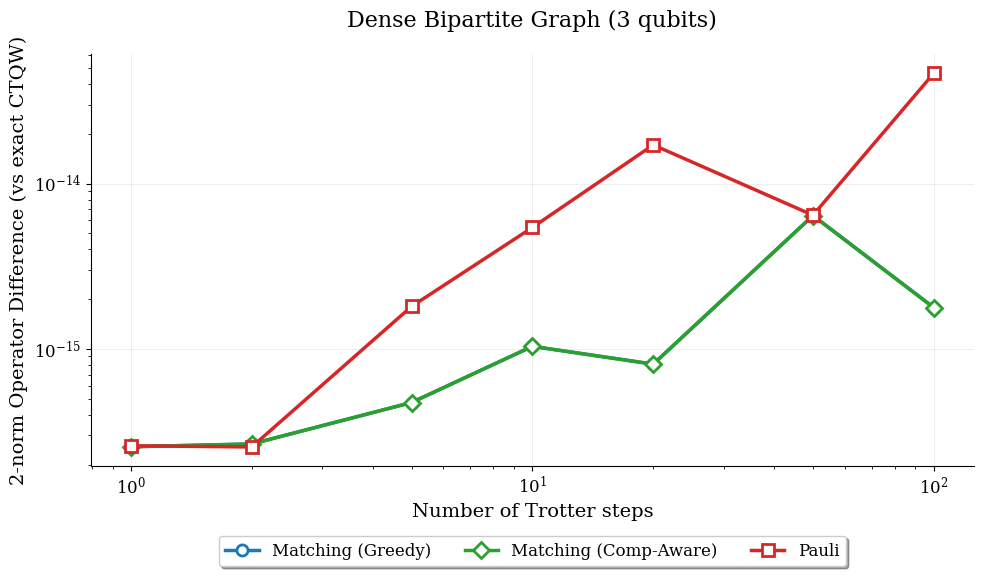

In [10]:
dense_bipartite_8 = {
    ('000','100'), ('000','101'), ('000','110'), ('000','111'),
    ('001','100'), ('001','101'), ('001','110'), ('001','111'),
    ('010','100'), ('010','101'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','110'), ('011','111')  
}
analyze_and_plot(dense_bipartite_8, "Dense Bipartite Graph (3 qubits)")


Sparse Non-Bipartite Graph (3 qubits)
Original edges: {('010', '011'), ('100', '011'), ('110', '101'), ('000', '001'), ('100', '101'), ('110', '111')}
Number of qubits: 3

Graph:


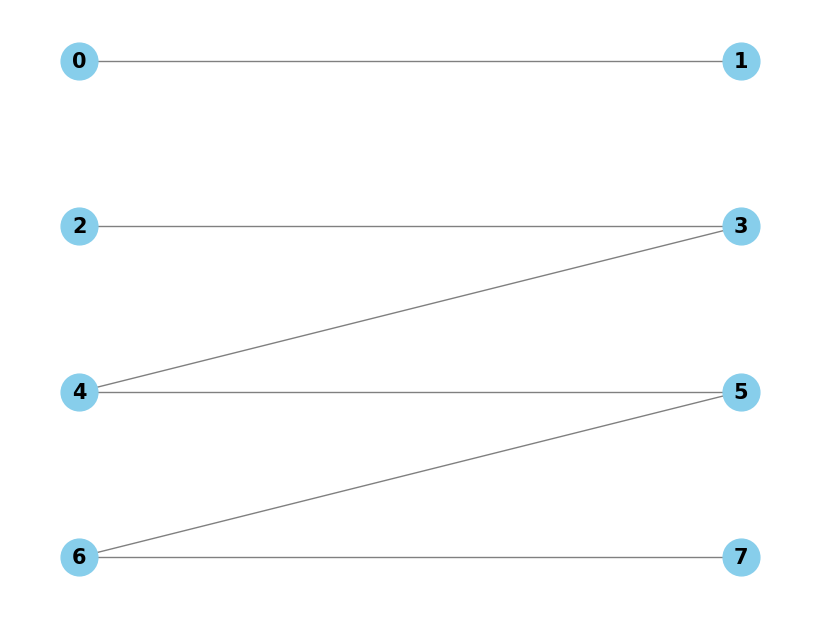

None


Greedy Matchings: 2
Compression-Aware Matchings: 2
Number of qubits: 3

Hamming Cost Analysis:
Total = 9, Edges = 6, Per Edge = 1.500

Sample Circuit - Greedy Matching (n_steps=1):


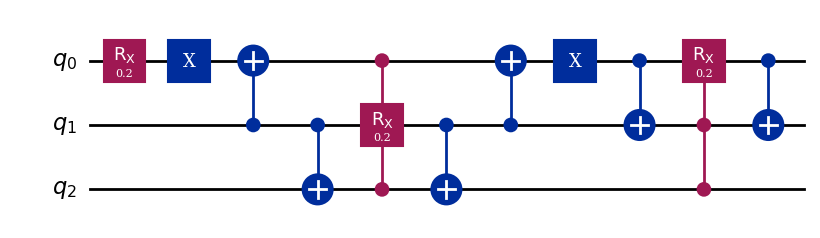


Sample Circuit - Compression-Aware Matching (n_steps=1):


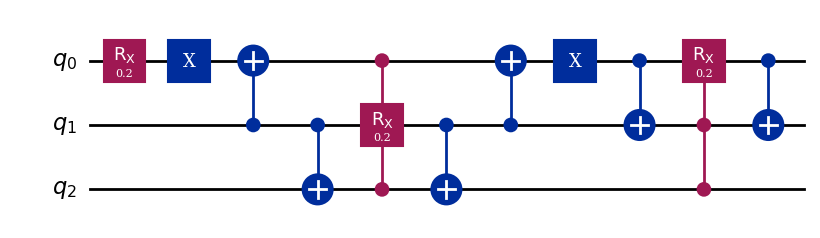


Gate Count Summary (U3/CX) for Sparse Non-Bipartite Graph (3 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1           33/22        22/20               33/22            22/20          49/28       34/23
       2           66/44        44/40               66/44            44/40          98/56       66/46
       5         165/110      110/100             165/110          110/100        245/140     162/115
      10         330/220      220/200             330/220          220/200        490/280     322/230
      20         660/440      440/400             660/440          440/400        980/560     642/460
      50       1650/1100    1100/1000           1650/1100        1100/1000      2450/1400   1602/1150
     100       3300/2200    2200/2000           3300/2200        2200/2000      4900/2800   3202/2300

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      20 CX
  Comp-Aware Matching:  20 CX  (+0.0% vs

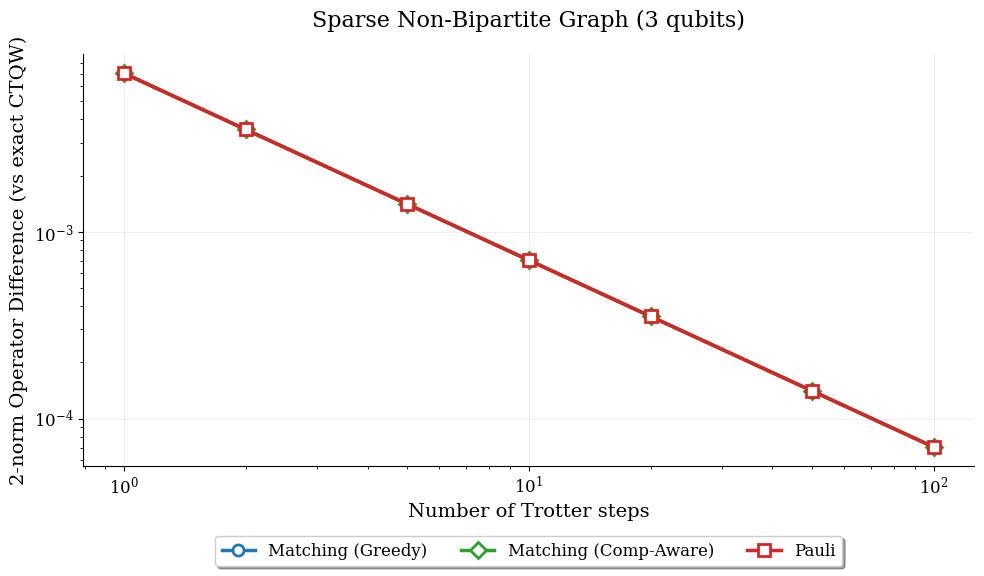

In [11]:
sparse_nonbipartite_8 = {
    ('000','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}
analyze_and_plot(sparse_nonbipartite_8, "Sparse Non-Bipartite Graph (3 qubits)")


Sparse Bipartite Graph (3 qubits)
Original edges: {('010', '011'), ('100', '011'), ('110', '101'), ('000', '001'), ('100', '101'), ('110', '111'), ('010', '001')}
Number of qubits: 3

Graph:


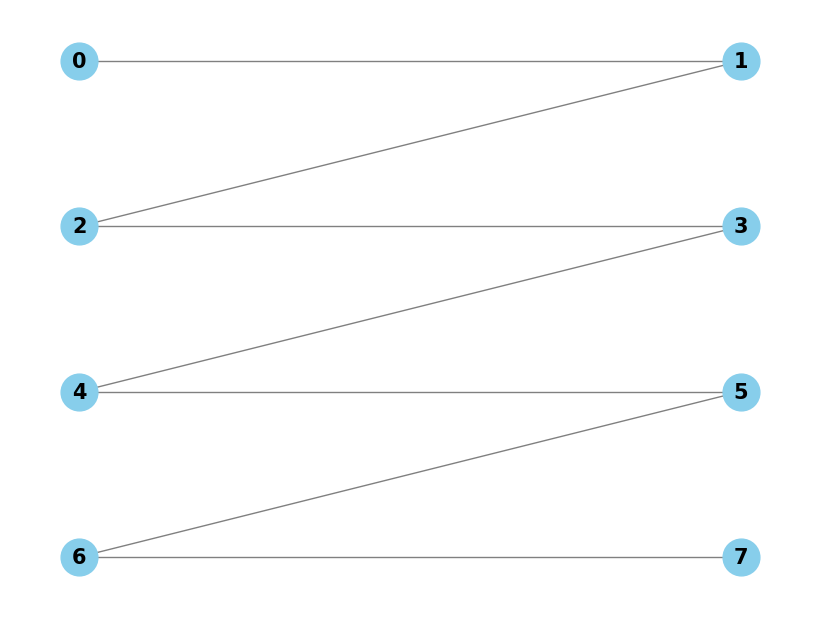

None


Greedy Matchings: 2
Compression-Aware Matchings: 2
Number of qubits: 3

Hamming Cost Analysis:
Total = 11, Edges = 7, Per Edge = 1.571

Sample Circuit - Greedy Matching (n_steps=1):


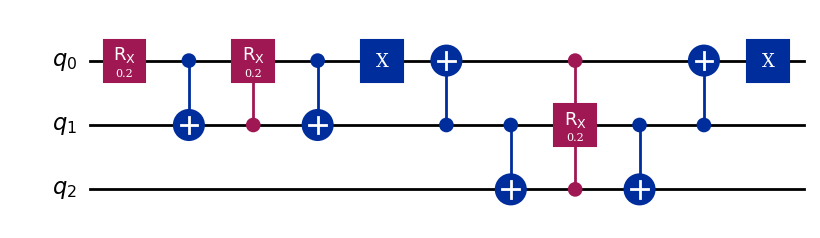


Sample Circuit - Compression-Aware Matching (n_steps=1):


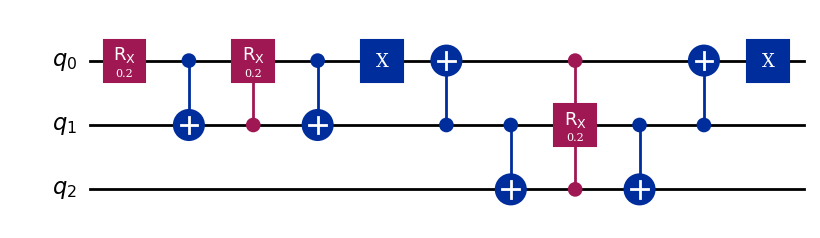


Gate Count Summary (U3/CX) for Sparse Bipartite Graph (3 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1           21/16        16/12               21/16            16/12          39/20       26/16
       2           42/32        31/23               42/32            31/23          78/40       49/32
       5          105/80        76/56              105/80            76/56        195/100      118/80
      10         210/160      151/111             210/160          151/111        390/200     233/160
      20         420/320      301/221             420/320          301/221        780/400     463/320
      50        1050/800      751/551            1050/800          751/551      1950/1000    1153/800
     100       2100/1600    1501/1101           2100/1600        1501/1101      3900/2000   2303/1600

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      12 CX
  Comp-Aware Matching:  12 CX  (+0.0% vs gre

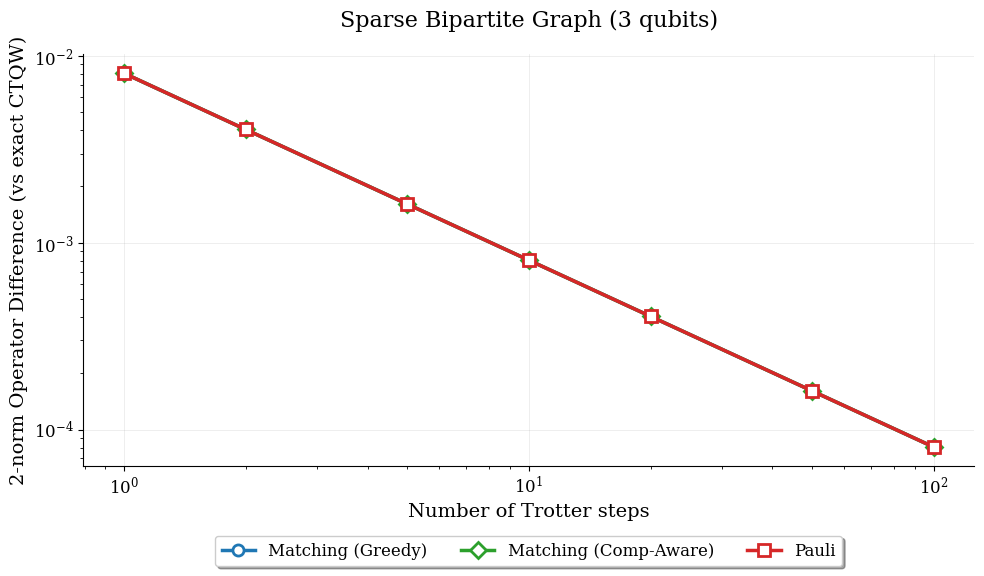

In [12]:
sparse_bipartite_8 = {
    ('000','001'), ('010','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}

analyze_and_plot(sparse_bipartite_8, "Sparse Bipartite Graph (3 qubits)")


Dense Non-Bipartite Graph (4 qubits)
Original edges: {('1001', '1110'), ('0111', '1011'), ('1000', '1011'), ('1000', '1001'), ('1001', '1010'), ('0100', '1010'), ('0001', '1001'), ('1010', '1111'), ('0111', '1101'), ('0100', '1100'), ('0001', '0010'), ('0011', '0111'), ('0011', '0100'), ('0000', '0110'), ('1010', '1110'), ('1011', '1100'), ('0110', '1110'), ('1101', '1110'), ('0010', '1000'), ('0101', '0110'), ('0001', '0101'), ('0101', '1101'), ('0000', '0101'), ('0110', '1010'), ('0010', '0110'), ('0000', '0011'), ('0110', '0111'), ('1100', '1101'), ('1001', '1011'), ('0000', '0100'), ('0000', '0111'), ('0001', '1000'), ('0011', '1011'), ('1010', '1100'), ('0011', '1001'), ('0110', '1100'), ('0111', '1111'), ('0010', '0011'), ('1110', '1111'), ('0101', '0111'), ('1001', '1101'), ('0010', '1010'), ('1011', '1101'), ('0010', '0100'), ('0100', '0101'), ('1010', '1011'), ('0011', '0101'), ('0000', '0001'), ('0100', '1000'), ('1100', '1111'), ('0001', '0011'), ('1000', '1010'), ('1100', 

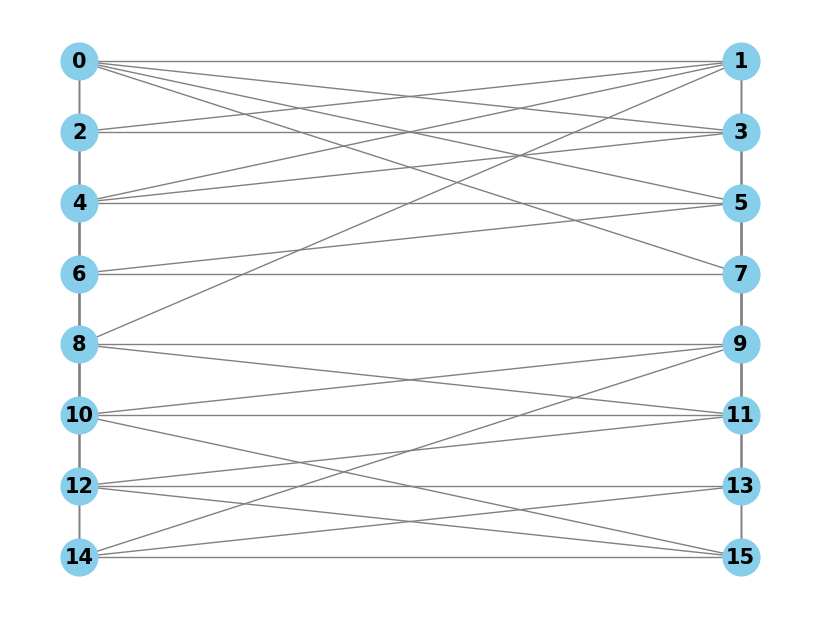

None


Greedy Matchings: 10
Compression-Aware Matchings: 10
Number of qubits: 4

Hamming Cost Analysis:
Total = 97, Edges = 61, Per Edge = 1.590

Sample Circuit - Greedy Matching (n_steps=1):


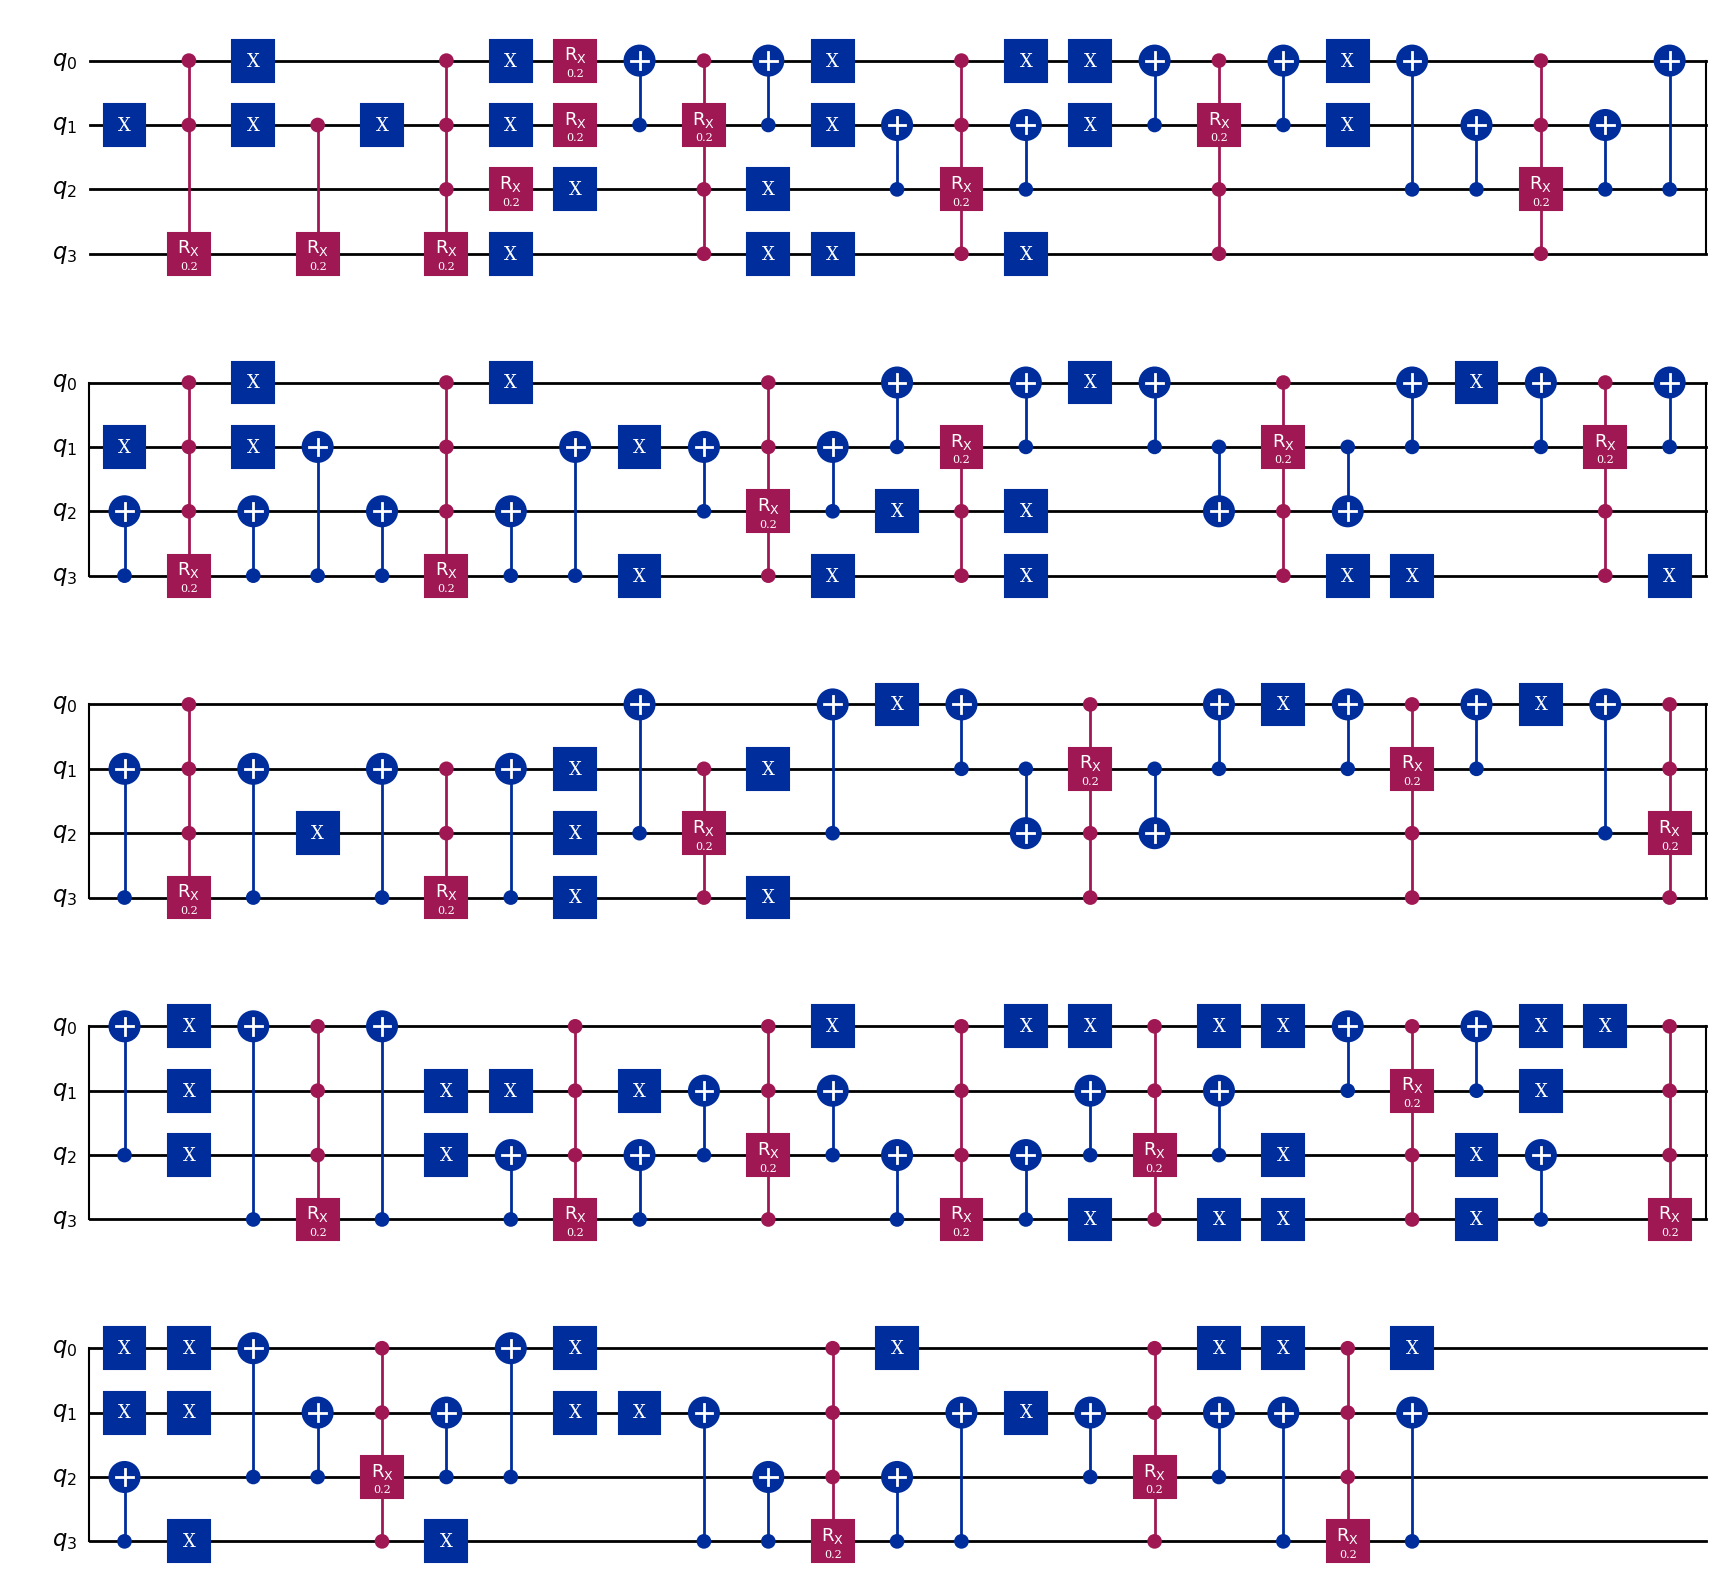


Sample Circuit - Compression-Aware Matching (n_steps=1):


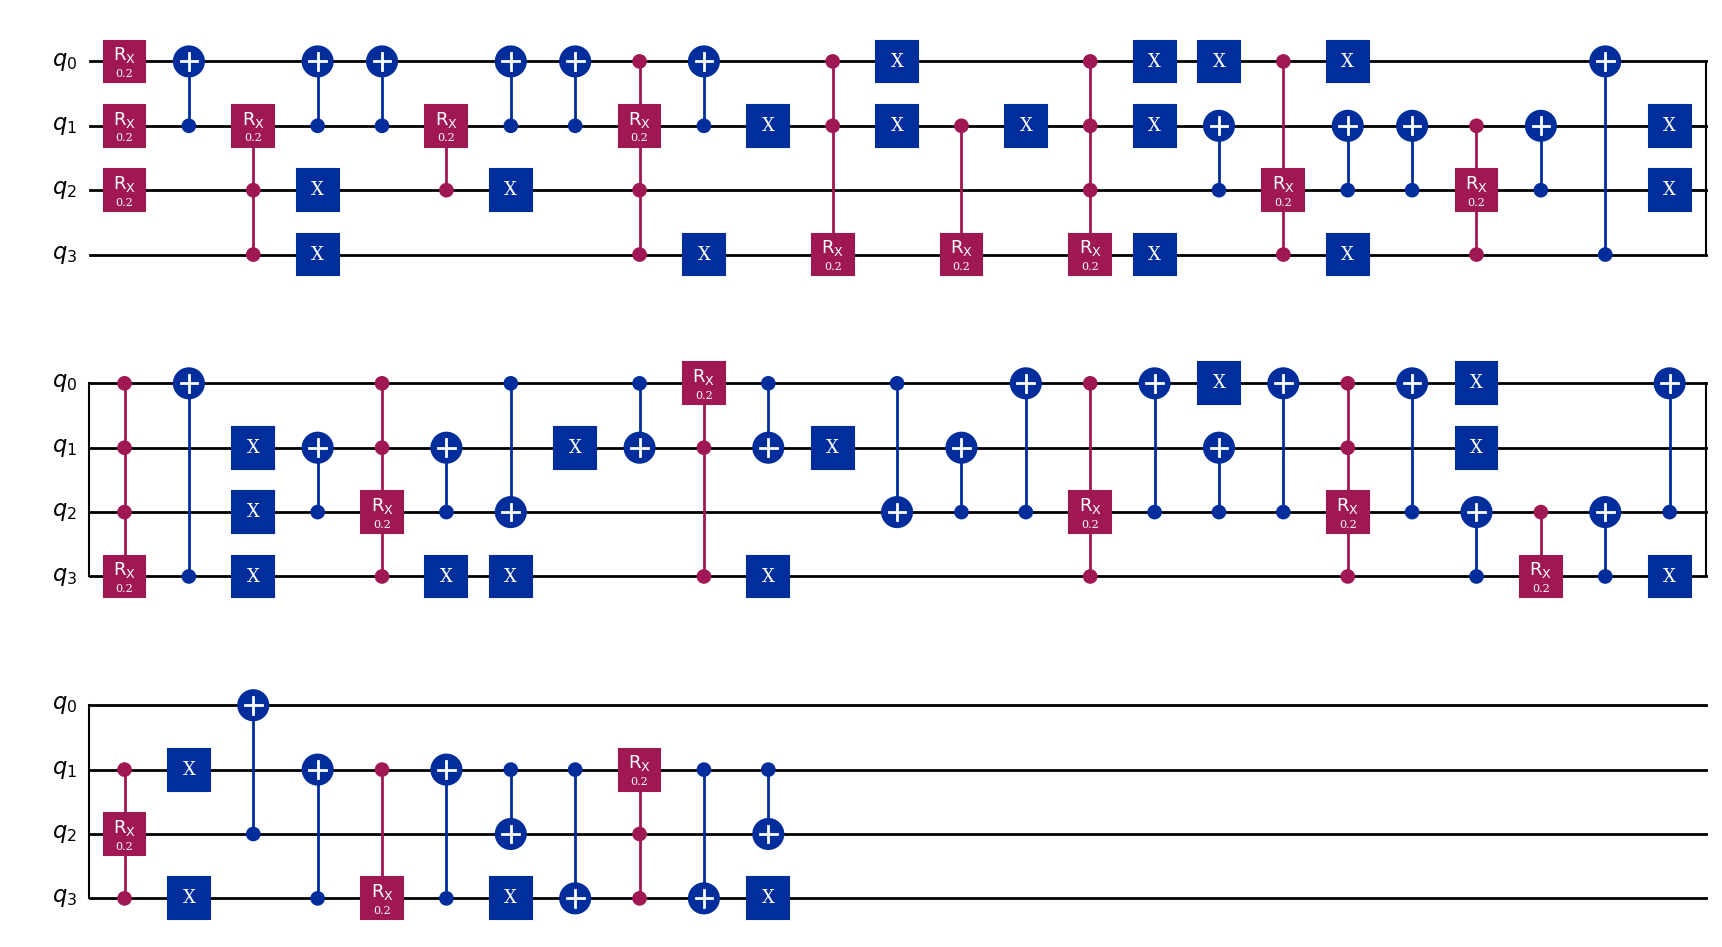


Gate Count Summary (U3/CX) for Dense Non-Bipartite Graph (4 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1        1019/600      482/574             342/206          177/186        268/200     155/101
       2       2038/1200     965/1147             684/412          353/372        536/400     310/202
       5       5095/3000    2414/2866           1710/1030          881/930      1340/1000     763/505
      10      10190/6000    4829/5731           3420/2060        1761/1860      2680/2000   1532/1010
      20     20380/12000   9659/11461           6840/4120        3541/3720      5360/4000   3062/2020
      50     50950/30000  24149/28651         17100/10300        8851/9300    13400/10000   7653/5050
     100    101900/60000  48299/57301         34200/20600      17701/18600    26800/20000 15203/10100

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      574 CX
  Comp-Aware Matching:  186 CX  (+67.6% 

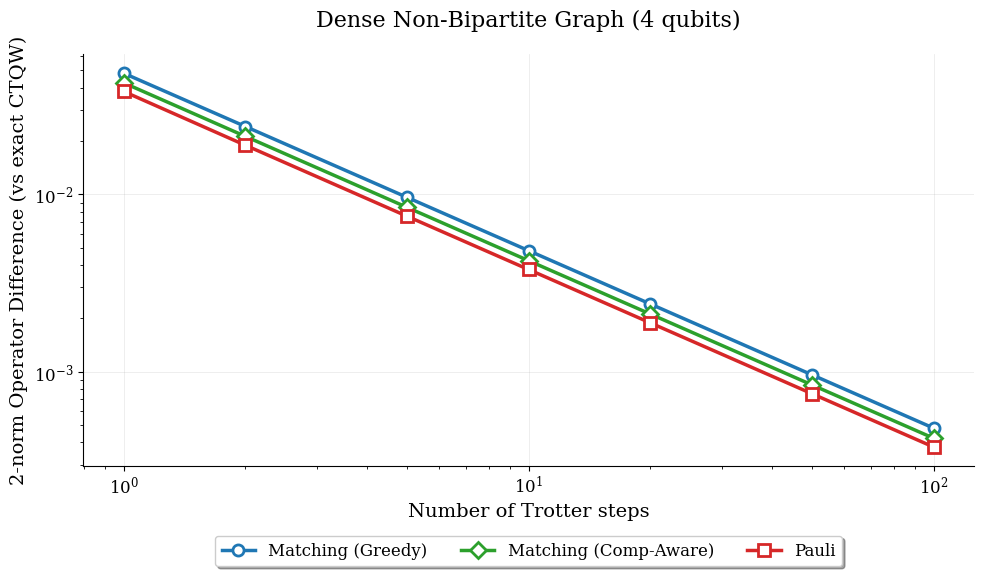

In [13]:
dense_nonbipartite_16 = {
    ('0000','0001'), ('0000','0010'), ('0000','0011'), ('0000','0100'), ('0000','0101'), ('0000','0110'), ('0000','0111'),
    ('0001','0010'), ('0001','0011'), ('0001','0100'), ('0001','0101'), ('0001','1000'), ('0001','1001'),
    ('0010','0011'), ('0010','0100'), ('0010','0110'), ('0010','1000'), ('0010','1010'),
    ('0011','0100'), ('0011','0101'), ('0011','0111'), ('0011','1001'), ('0011','1011'),
    ('0100','0101'), ('0100','0110'), ('0100','1000'), ('0100','1010'), ('0100','1100'),
    ('0101','0110'), ('0101','0111'), ('0101','1001'), ('0101','1011'), ('0101','1101'),
    ('0110','0111'), ('0110','1010'), ('0110','1100'), ('0110','1110'),
    ('0111','1011'), ('0111','1101'), ('0111','1111'),
    ('1000','1001'), ('1000','1010'), ('1000','1011'), ('1000','1100'),
    ('1001','1010'), ('1001','1011'), ('1001','1101'), ('1001','1110'),
    ('1010','1011'), ('1010','1100'), ('1010','1110'), ('1010','1111'),
    ('1011','1100'), ('1011','1101'), ('1011','1111'),
    ('1100','1101'), ('1100','1110'), ('1100','1111'),
    ('1101','1110'), ('1101','1111'),
    ('1110','1111')
}
analyze_and_plot(dense_nonbipartite_16, "Dense Non-Bipartite Graph (4 qubits)")


Dense Bipartite Graph (4 qubits)
Original edges: {('0010', '1101'), ('0110', '1000'), ('0000', '1000'), ('0011', '1110'), ('0111', '1011'), ('0100', '1010'), ('0001', '1001'), ('0000', '1111'), ('0001', '1101'), ('0011', '1100'), ('0101', '1111'), ('0010', '1111'), ('0111', '1000'), ('0101', '1110'), ('0100', '1011'), ('0011', '1001'), ('0101', '1010'), ('0010', '1010'), ('0001', '1111'), ('0011', '1101'), ('0101', '1100'), ('0110', '1001'), ('0010', '1100'), ('0000', '1011'), ('0001', '1110'), ('0011', '1000'), ('0110', '1101'), ('0101', '1011'), ('0001', '1010'), ('0010', '1011'), ('0001', '1100'), ('0011', '1111'), ('0100', '1110'), ('0111', '1001'), ('0001', '1011'), ('0110', '1111'), ('0101', '1000'), ('0111', '1101'), ('0011', '1010'), ('0100', '1100'), ('0010', '1000'), ('0110', '1110'), ('0000', '1110'), ('0110', '1010'), ('0000', '1010'), ('0010', '1110'), ('0100', '1001'), ('0001', '1000'), ('0011', '1011'), ('0110', '1100'), ('0000', '1100'), ('0111', '1111'), ('0100', '110

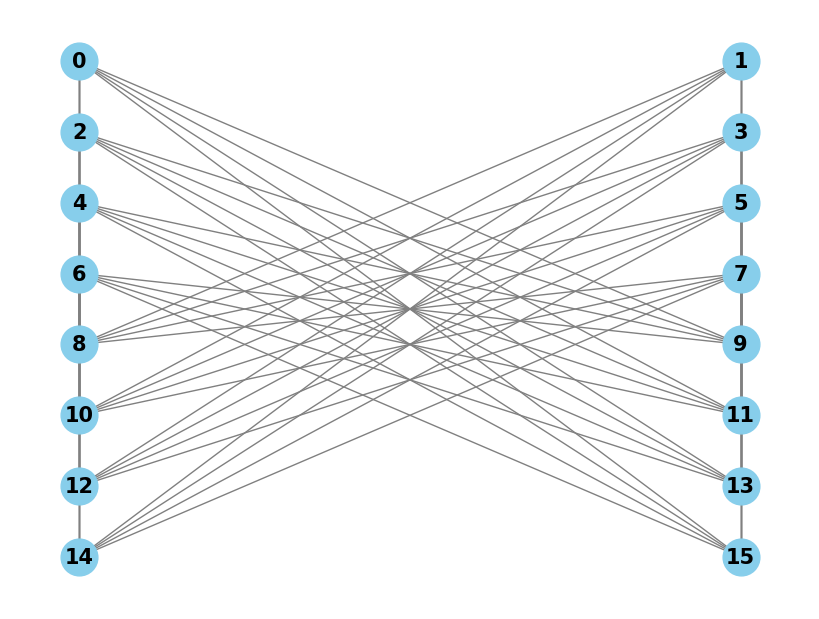

None


Greedy Matchings: 8
Compression-Aware Matchings: 8
Number of qubits: 4

Hamming Cost Analysis:
Total = 160, Edges = 64, Per Edge = 2.500

Sample Circuit - Greedy Matching (n_steps=1):


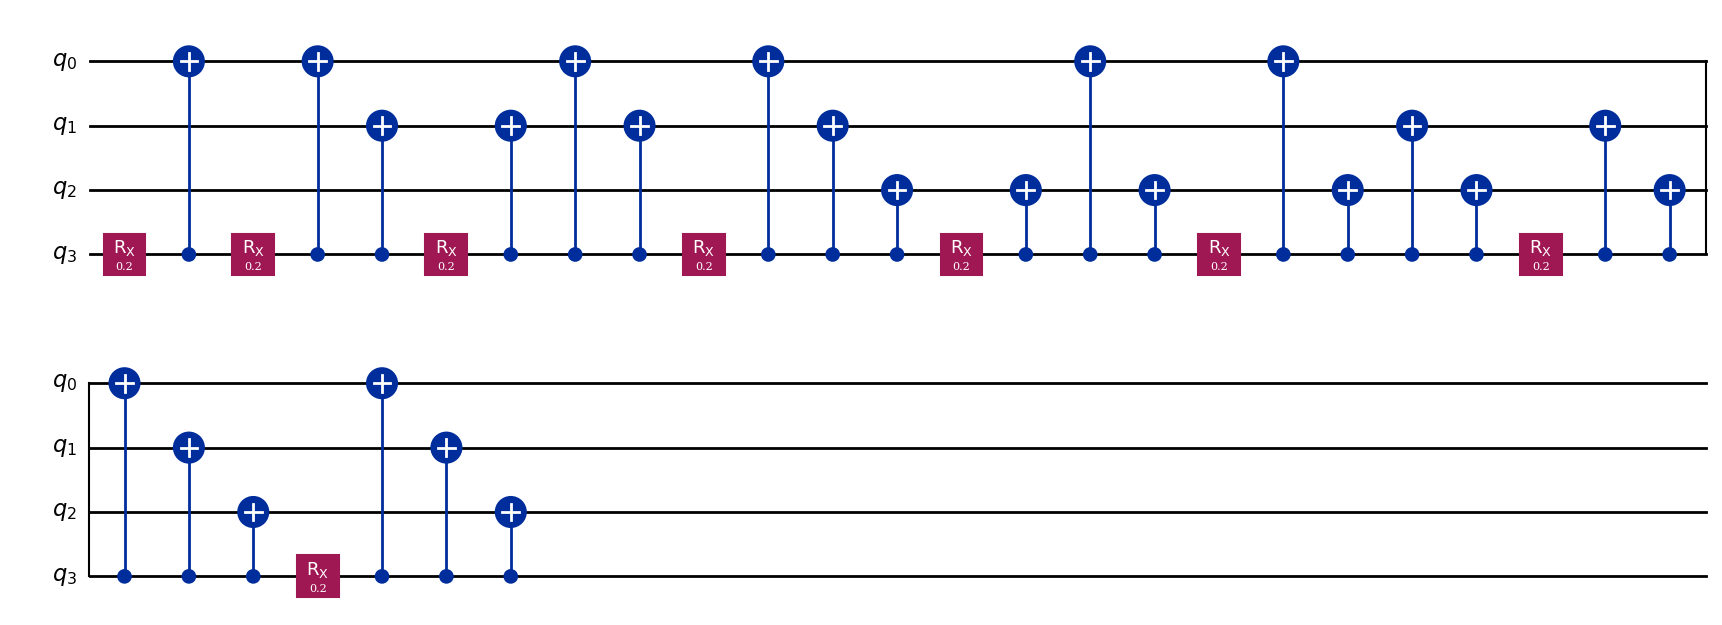


Sample Circuit - Compression-Aware Matching (n_steps=1):


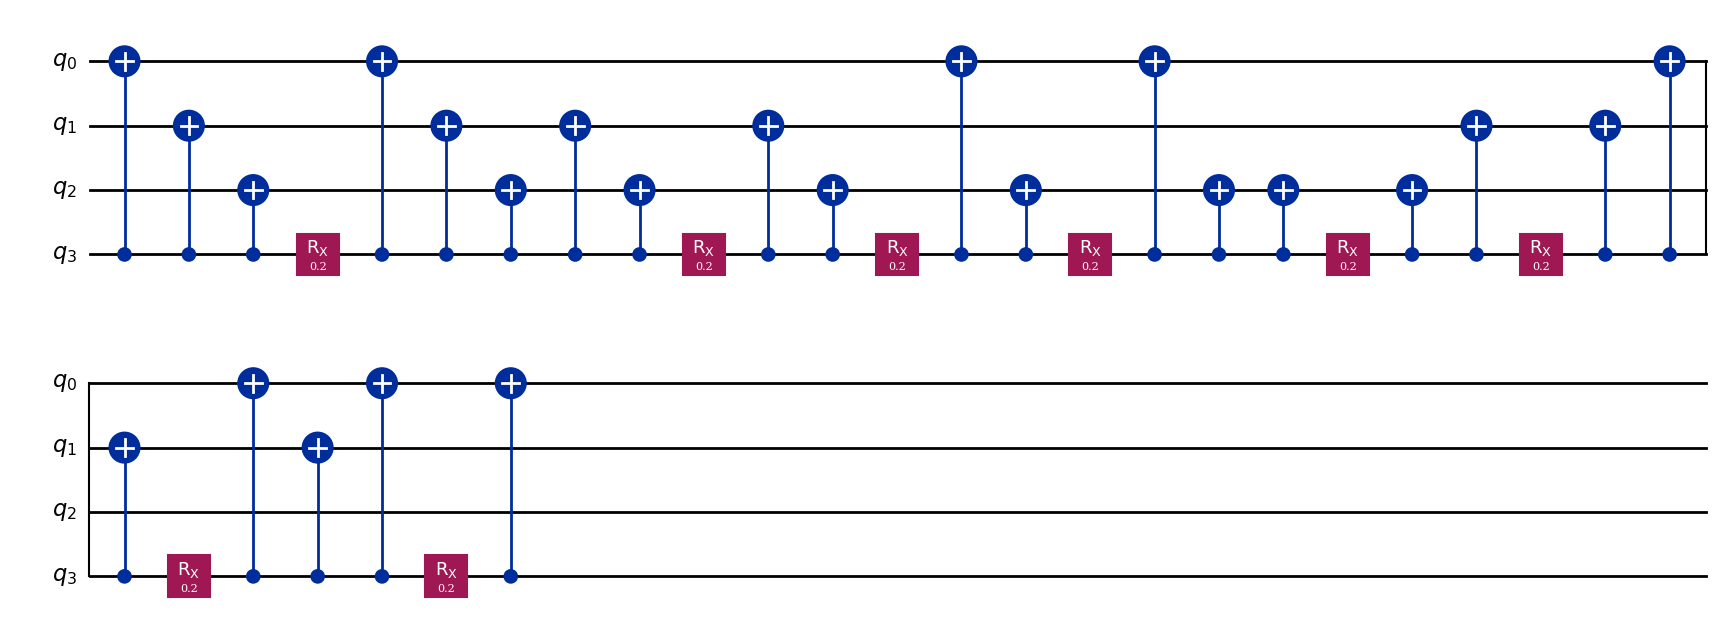


Gate Count Summary (U3/CX) for Dense Bipartite Graph (4 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1            8/24         8/14                8/24             8/14          46/24       22/14
       2           16/48        16/28               16/48            16/26          92/48       37/28
       5          40/120        40/70              40/120            40/62        230/120       88/70
      10          80/240       80/140              80/240           80/122        460/240     173/140
      20         160/480      160/280             160/480          160/242        920/480     343/280
      50        400/1200      400/700            400/1200          400/602      2300/1200     855/700
     100        800/2400     800/1400            800/2400         800/1202      4600/2400   1705/1400

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      14 CX
  Comp-Aware Matching:  14 CX  (+0.0% vs gree

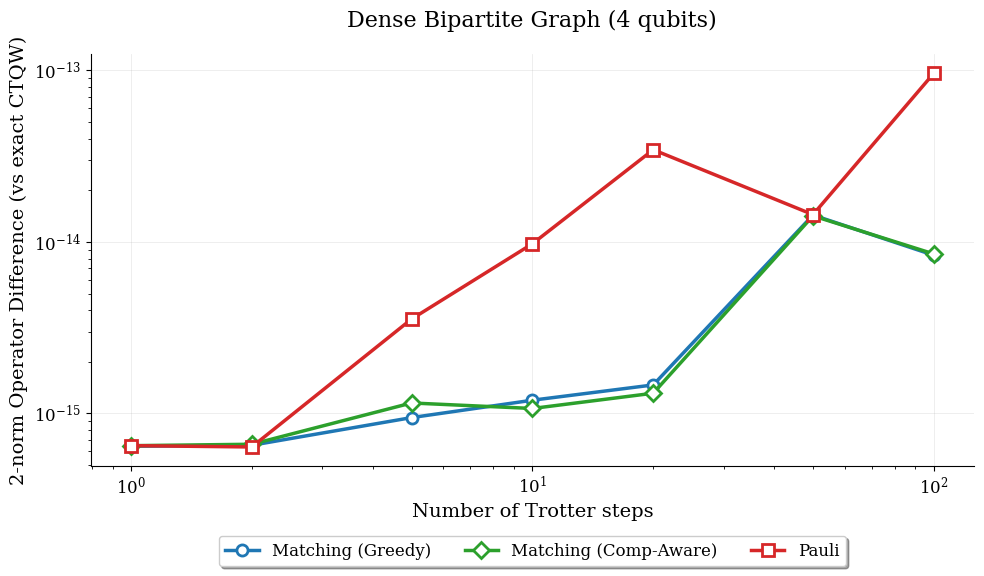

In [14]:
dense_bipartite_16 = {
    ('0000','1000'), ('0000','1001'), ('0000','1010'), ('0000','1011'), ('0000','1100'), ('0000','1101'), ('0000','1110'), ('0000','1111'),
    ('0001','1000'), ('0001','1001'), ('0001','1010'), ('0001','1011'), ('0001','1100'), ('0001','1101'), ('0001','1110'), ('0001','1111'),
    ('0010','1000'), ('0010','1001'), ('0010','1010'), ('0010','1011'), ('0010','1100'), ('0010','1101'), ('0010','1110'), ('0010','1111'),
    ('0011','1000'), ('0011','1001'), ('0011','1010'), ('0011','1011'), ('0011','1100'), ('0011','1101'), ('0011','1110'), ('0011','1111'),
    ('0100','1000'), ('0100','1001'), ('0100','1010'), ('0100','1011'), ('0100','1100'), ('0100','1101'), ('0100','1110'), ('0100','1111'),
    ('0101','1000'), ('0101','1001'), ('0101','1010'), ('0101','1011'), ('0101','1100'), ('0101','1101'), ('0101','1110'), ('0101','1111'),
    ('0110','1000'), ('0110','1001'), ('0110','1010'), ('0110','1011'), ('0110','1100'), ('0110','1101'), ('0110','1110'), ('0110','1111'),
    ('0111','1000'), ('0111','1001'), ('0111','1010'), ('0111','1011'), ('0111','1100'), ('0111','1101'), ('0111','1110'), ('0111','1111')
}

analyze_and_plot(dense_bipartite_16, "Dense Bipartite Graph (4 qubits)")


Sparse Non-Bipartite Graph (4 qubits)
Original edges: {('0001', '0100'), ('0010', '0110'), ('1010', '0101'), ('0010', '0011'), ('0001', '0011'), ('0111', '0110'), ('0000', '0100')}
Number of qubits: 4

Graph:


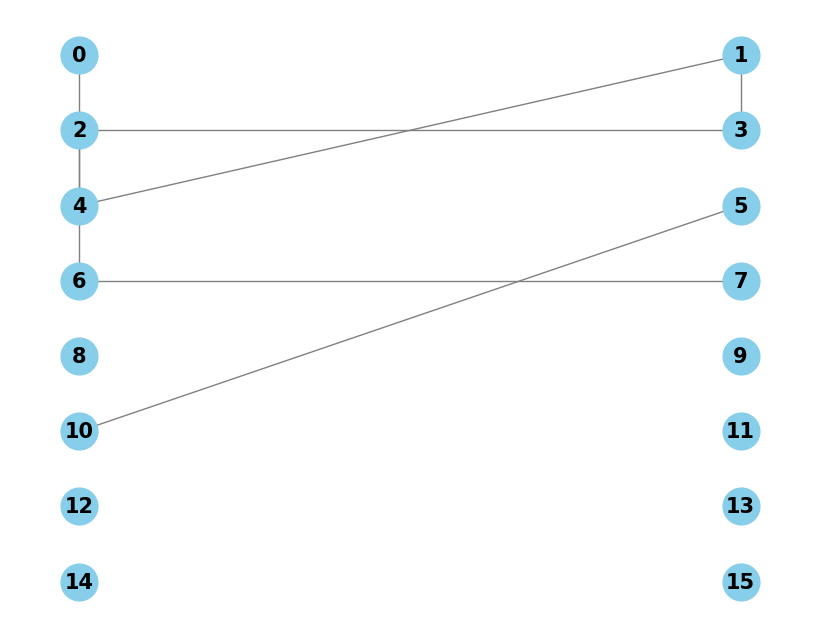

None


Greedy Matchings: 3
Compression-Aware Matchings: 2
Number of qubits: 4

Hamming Cost Analysis:
Total = 11, Edges = 7, Per Edge = 1.571

Sample Circuit - Greedy Matching (n_steps=1):


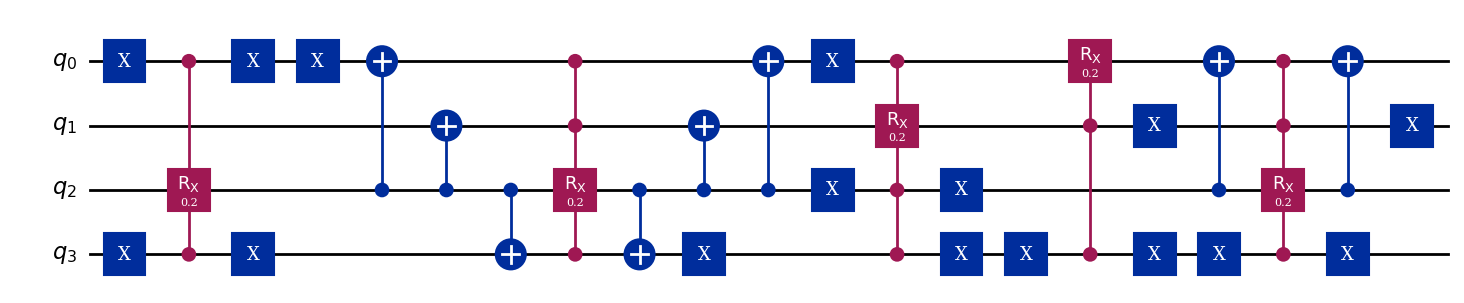


Sample Circuit - Compression-Aware Matching (n_steps=1):


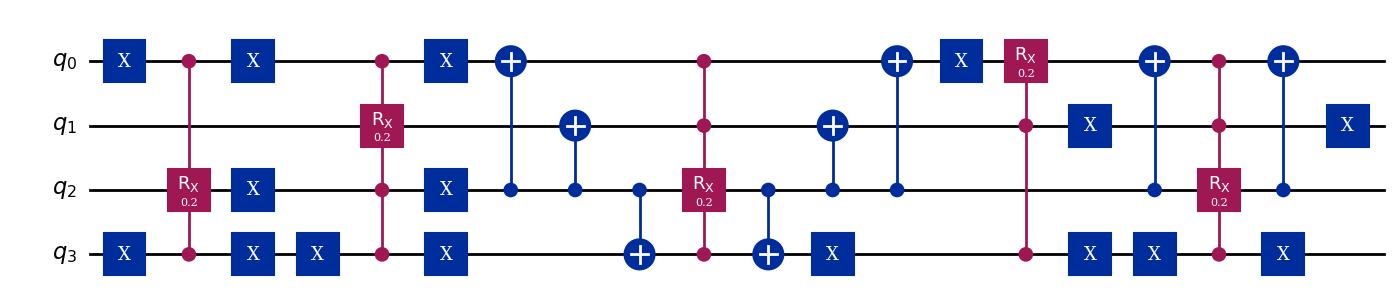


Gate Count Summary (U3/CX) for Sparse Non-Bipartite Graph (4 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1          151/84        77/81              151/84            74/82        154/120      104/80
       2         302/168      150/162             302/168          143/164        308/240     205/160
       5         755/420      369/405             755/420          350/410        770/600     511/400
      10        1510/840      734/810            1510/840          695/820      1540/1200    1031/800
      20       3020/1680    1464/1620           3020/1680        1385/1640      3080/2400   2061/1600
      50       7550/4200    3654/4050           7550/4200        3455/4100      7700/6000   5201/4000
     100      15100/8400    7304/8100          15100/8400        6905/8200    15400/12000  10201/8000

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      81 CX
  Comp-Aware Matching:  82 CX  (-1.2% vs

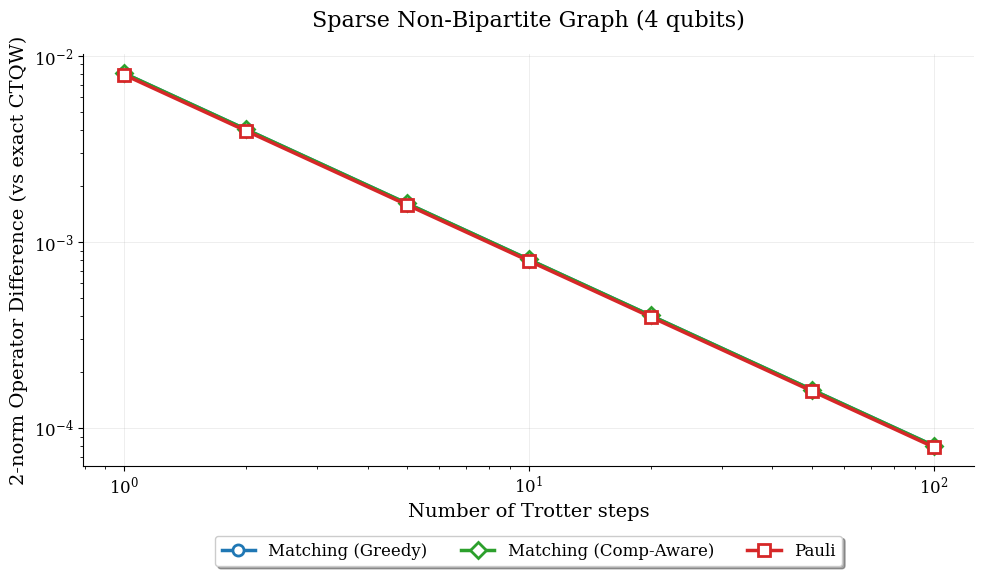

In [15]:
sparse_nonbipartite_16 = {
    ('0000','0100'),  # H=1, start cluster in 0xxx
    ('0001','0100'),  # H=2, degree-2 at 0100
    ('0001','0011'),  # H=1, degree-2 at 0001
    ('0010','0011'),  # H=1, degree-2 at 0011
    ('0010','0110'),  # H=1, degree-2 at 0010
    ('0111','0110'),  # H=1, degree-2 at 0110
    ('1010','0101'),  # H=3, high-Hamming bridge to 1xxx
}

analyze_and_plot(sparse_nonbipartite_16, "Sparse Non-Bipartite Graph (4 qubits)")


Sparse Bipartite Graph (4 qubits)
Original edges: {('1100', '1111'), ('1010', '1101'), ('1000', '0111'), ('0010', '0101'), ('0100', '0011'), ('0010', '0001'), ('1000', '1011'), ('0110', '1001'), ('0110', '0101'), ('0000', '0011'), ('1010', '1001'), ('0100', '0111'), ('1110', '1101'), ('1100', '1011'), ('0000', '0001')}
Number of qubits: 4

Graph:


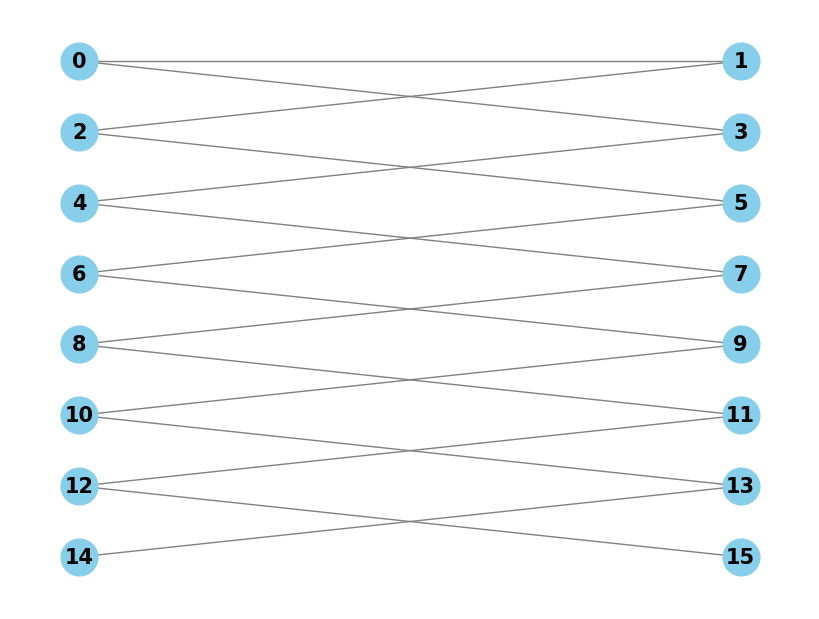

None


Greedy Matchings: 3
Compression-Aware Matchings: 2
Number of qubits: 4

Hamming Cost Analysis:
Total = 37, Edges = 15, Per Edge = 2.467

Sample Circuit - Greedy Matching (n_steps=1):


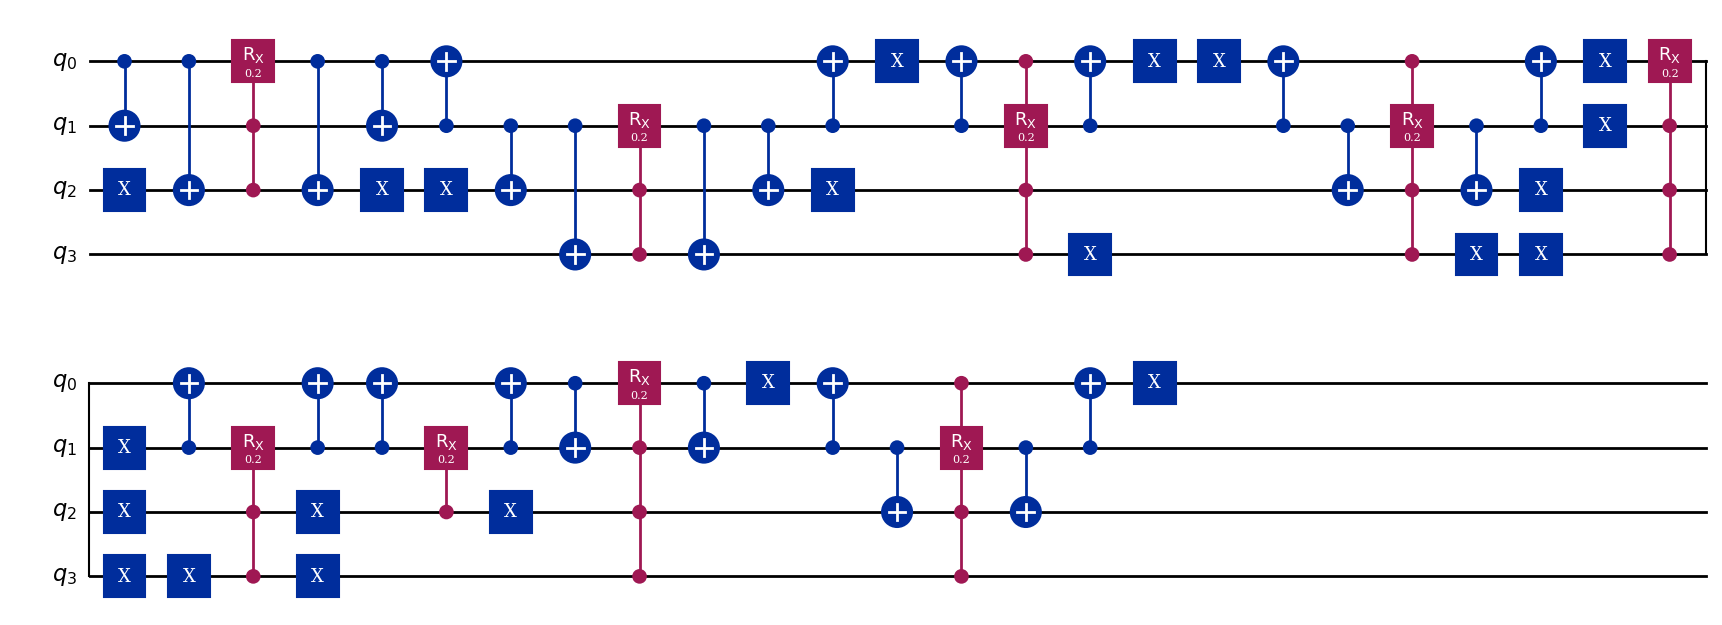


Sample Circuit - Compression-Aware Matching (n_steps=1):


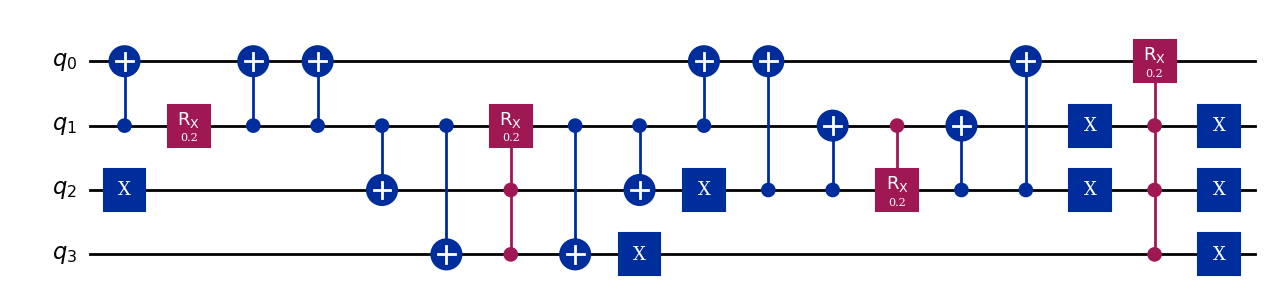


Gate Count Summary (U3/CX) for Sparse Bipartite Graph (4 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1         245/152      120/140               62/42            39/37          77/58       42/52
       2         490/304      240/280              124/84            76/73        154/116      83/104
       5        1225/760      600/700             310/210          187/181        385/290     206/260
      10       2450/1520    1200/1400             620/420          372/361        770/580     411/520
      20       4900/3040    2400/2800            1240/840          742/721      1540/1160    821/1040
      50      12250/7600    6000/7000           3100/2100        1852/1801      3850/2900   2051/2600
     100     24500/15200  12000/14000           6200/4200        3702/3601      7700/5800   4101/5200

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      140 CX
  Comp-Aware Matching:  37 CX  (+73.6% vs g

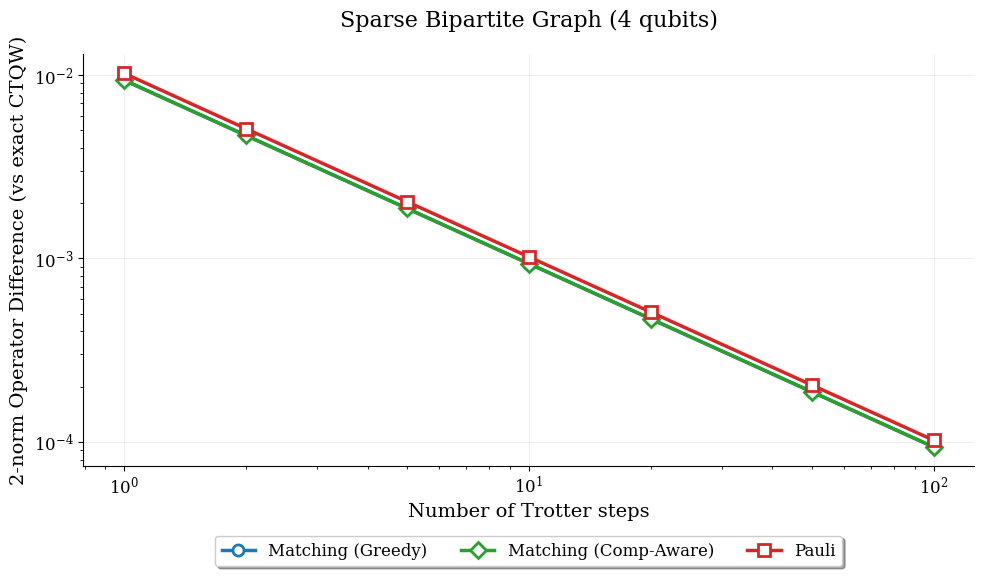

In [16]:
sparse_bipartite_16 = {
    ('0000','0001'), ('0000','0011'),
    ('0010','0001'), ('0010','0101'),
    ('0100','0011'), ('0100','0111'),
    ('0110','0101'), ('0110','1001'),
    ('1000','0111'), ('1000','1011'),
    ('1010','1001'), ('1010','1101'),
    ('1100','1011'), ('1100','1111'),
    ('1110','1101')
}

analyze_and_plot(sparse_bipartite_16, "Sparse Bipartite Graph (4 qubits)")


Sparse Non Bipartite Graph (5 qubits)
Original edges: {('00010', '00001'), ('01000', '00111'), ('00100', '00011'), ('00110', '00101'), ('01001', '01011'), ('10000', '01111'), ('00000', '00001'), ('00010', '00011'), ('00100', '00101')}
Number of qubits: 5

Graph:


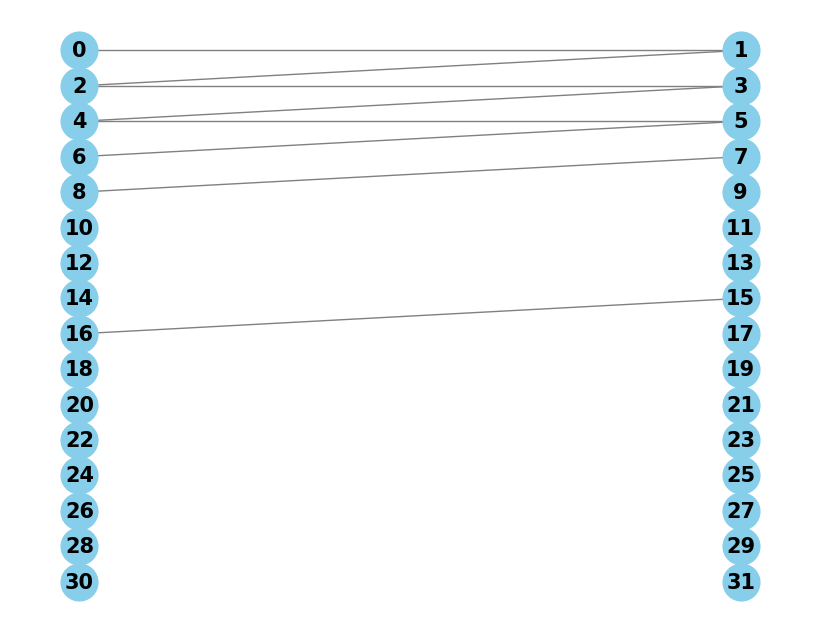

None


Greedy Matchings: 2
Compression-Aware Matchings: 2
Number of qubits: 5

Hamming Cost Analysis:
Total = 20, Edges = 9, Per Edge = 2.222

Sample Circuit - Greedy Matching (n_steps=1):


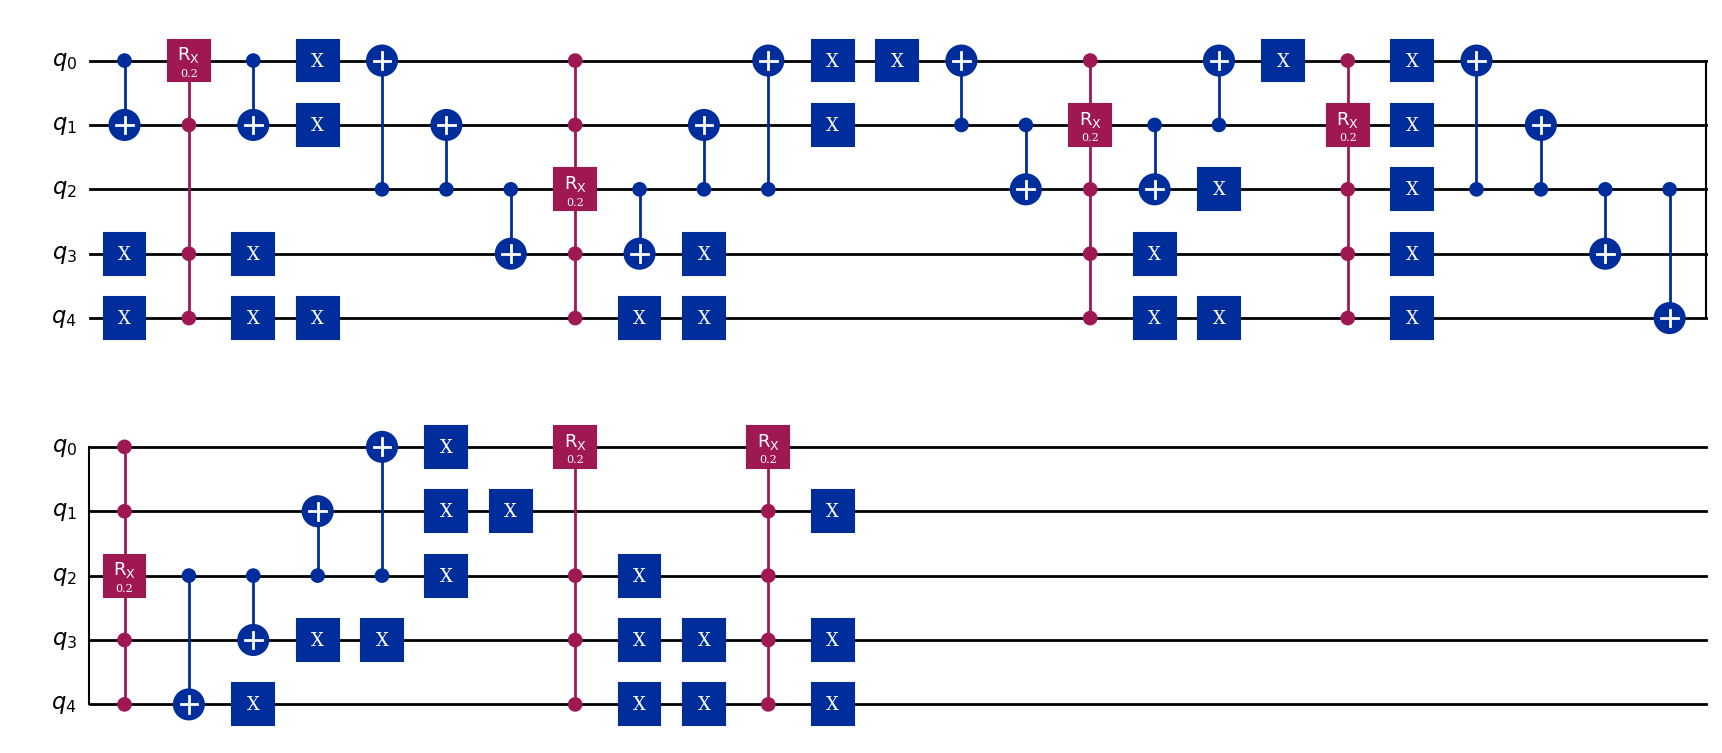


Sample Circuit - Compression-Aware Matching (n_steps=1):


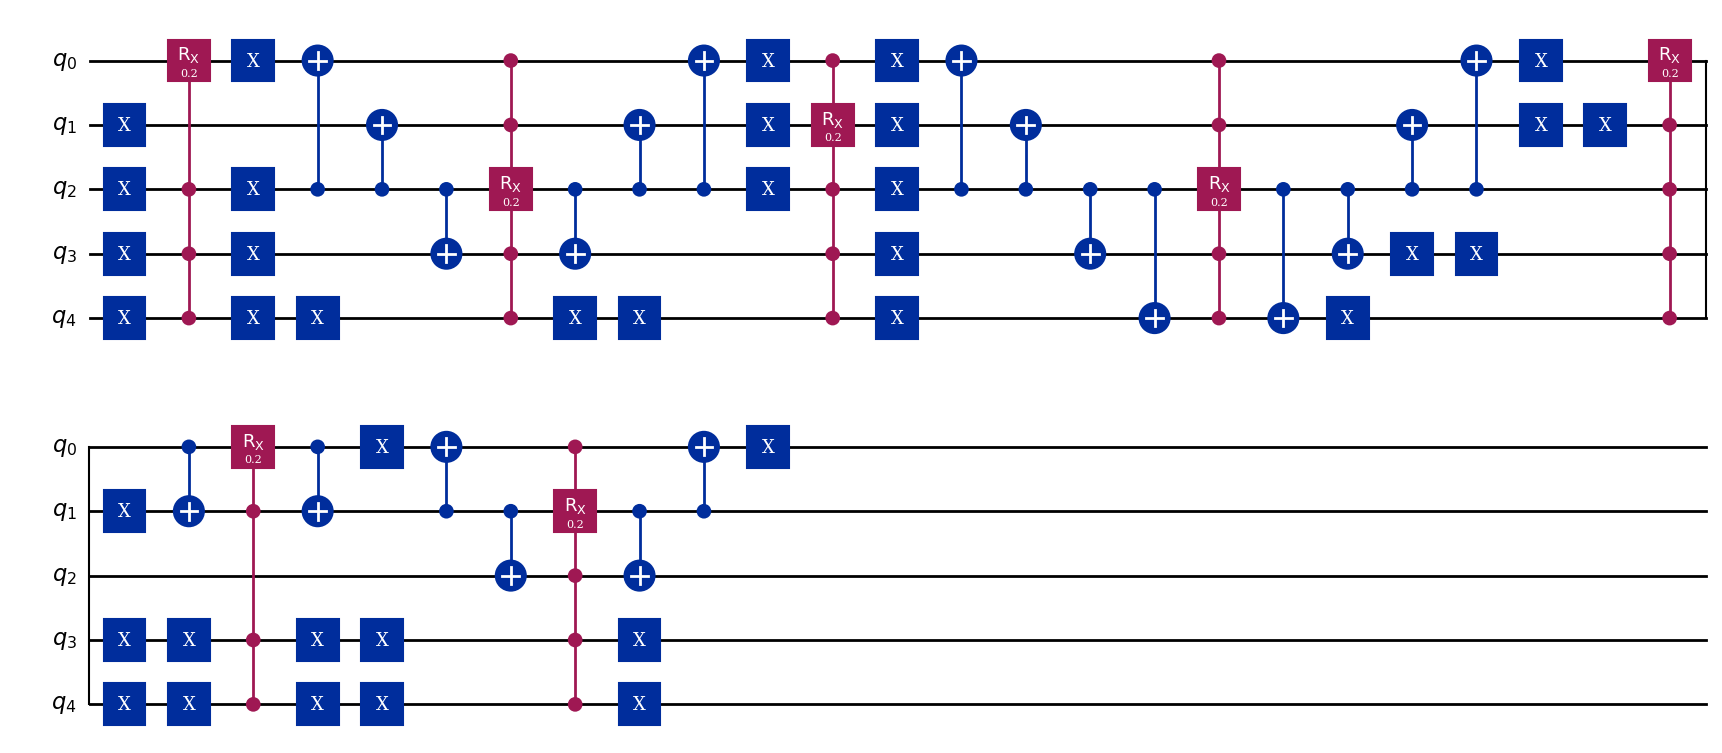


Gate Count Summary (U3/CX) for Sparse Non Bipartite Graph (5 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1         318/180      181/176             318/180          185/174        564/496     380/276
       2         636/360      360/352             636/360          365/348       1128/992     763/552
       5        1590/900      894/880            1590/900          905/870      2820/2480   1891/1380
      10       3180/1800    1774/1760           3180/1800        1805/1740      5640/4960   3811/2760
      20       6360/3600    3544/3520           6360/3600        3605/3480     11280/9920   7601/5520
      50      15900/9000    8854/8800          15900/9000        9005/8700    28200/24800 19001/13800
     100     31800/18000  17704/17600         31800/18000      18005/17400    56400/49600 37901/27600

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      176 CX
  Comp-Aware Matching:  174 CX  (+1.1% 

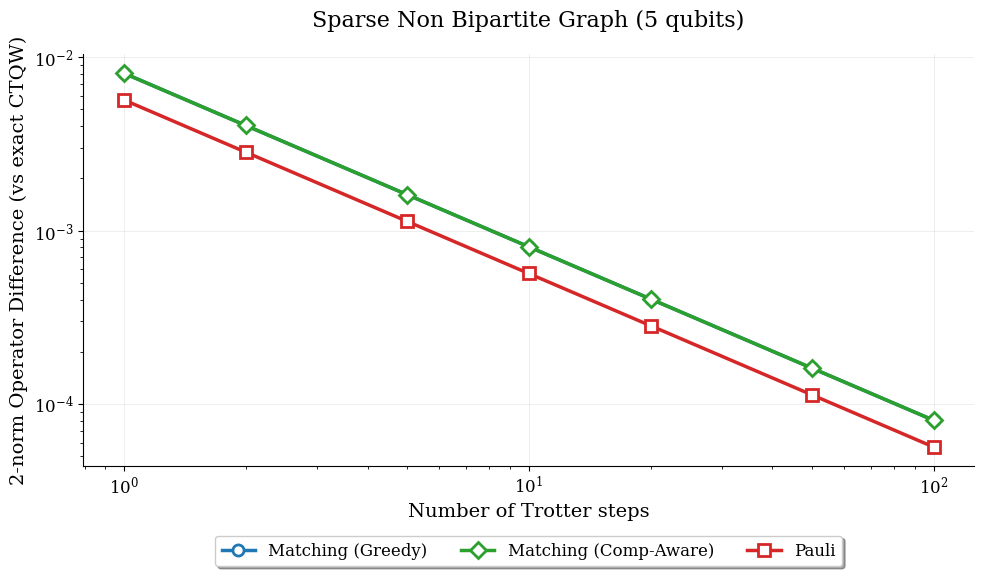

In [17]:
sparse_nonbipartite_32 = {
    # Cluster in 0xxxx region
    ('00000','00001'),  # H=1
    ('00010','00001'),  # H=2, degree-2 at 00001
    ('00010','00011'),  # H=1, degree-2 at 00010
    ('00100','00011'),  # H=2, degree-2 at 00011
    ('00100','00101'),  # H=1, degree-2 at 00100
    ('00110','00101'),  # H=2, degree-2 at 00101
    ('01000','00111'),  # H=3, bridge
    ('01001','01011'),  # H=1, small cluster in 01xxx
    ('10000','01111'),  # H=4, high-Hamming bridge to 1xxxx
}

analyze_and_plot(sparse_nonbipartite_32, "Sparse Non Bipartite Graph (5 qubits)" )


Cayley Graph of Z2 x Z2 x Z2 (3 qubits)
Original edges: {('010', '011'), ('000', '010'), ('000', '001'), ('001', '011'), ('101', '111'), ('110', '111'), ('000', '100'), ('010', '110'), ('100', '110'), ('100', '101'), ('011', '111'), ('001', '101')}
Number of qubits: 3

Graph:


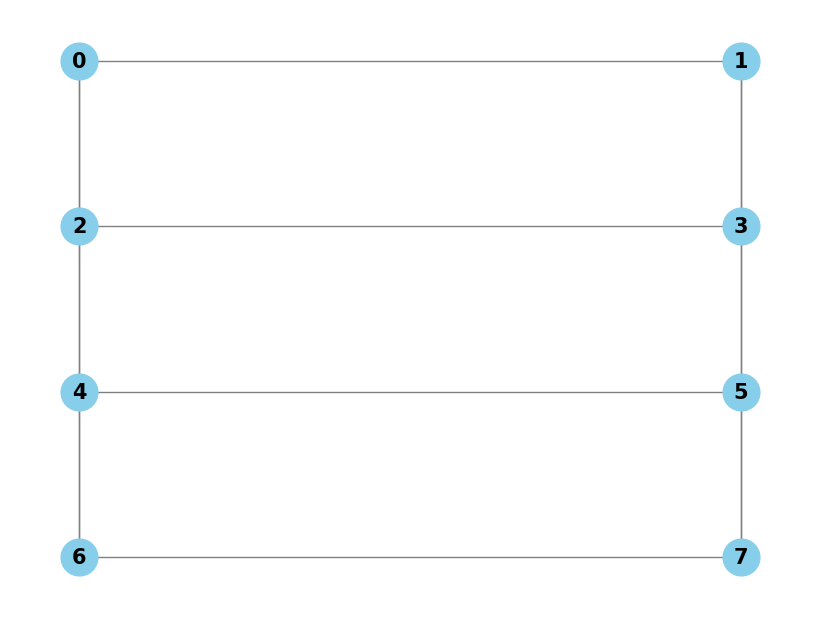

None


Greedy Matchings: 3
Compression-Aware Matchings: 3
Number of qubits: 3

Hamming Cost Analysis:
Total = 12, Edges = 12, Per Edge = 1.000

Sample Circuit - Greedy Matching (n_steps=1):


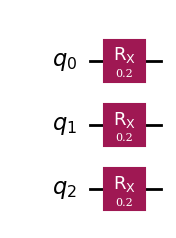


Sample Circuit - Compression-Aware Matching (n_steps=1):


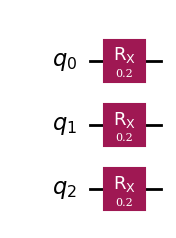


Gate Count Summary (U3/CX) for Cayley Graph of Z2 x Z2 x Z2 (3 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1             3/0          3/0                 3/0              3/0            3/0         3/0
       2             6/0          3/0                 6/0              3/0            6/0         3/0
       5            15/0          3/0                15/0              3/0           15/0         3/0
      10            30/0          3/0                30/0              3/0           30/0         3/0
      20            60/0          3/0                60/0              3/0           60/0         3/0
      50           150/0          3/0               150/0              3/0          150/0         3/0
     100           300/0          3/0               300/0              3/0          300/0         3/0

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      0 CX
  Comp-Aware Matching:  0 CX
  Pauli:  

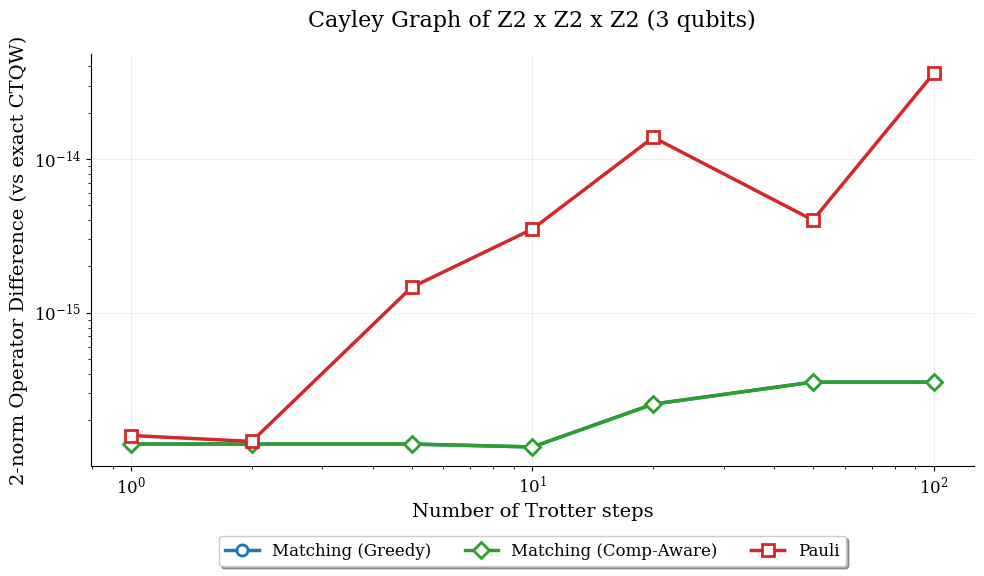

In [18]:
cayley_8 = set()
vertices_8 = [format(i, '03b') for i in range(8)]
generators_8 = ['001', '010', '100']
for v in vertices_8:
    v_int = int(v, 2)
    for g in generators_8:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '03b')
        if v < neighbor:  # Avoid duplicates
            cayley_8.add((v, neighbor))

analyze_and_plot(cayley_8, "Cayley Graph of Z2 x Z2 x Z2 (3 qubits)")


Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)
Original edges: {('0000', '1000'), ('1000', '1001'), ('0001', '1001'), ('0100', '1100'), ('0011', '0111'), ('1010', '1110'), ('1101', '1111'), ('0110', '1110'), ('0100', '0110'), ('0001', '0101'), ('0010', '0110'), ('1100', '1101'), ('0110', '0111'), ('1001', '1011'), ('0000', '0100'), ('0011', '1011'), ('0111', '1111'), ('0010', '0011'), ('1110', '1111'), ('0101', '0111'), ('1001', '1101'), ('0010', '1010'), ('0100', '0101'), ('1010', '1011'), ('0000', '0001'), ('0001', '0011'), ('1000', '1010'), ('1100', '1110'), ('0000', '0010'), ('1000', '1100'), ('0101', '1101'), ('1011', '1111')}
Number of qubits: 4

Graph:


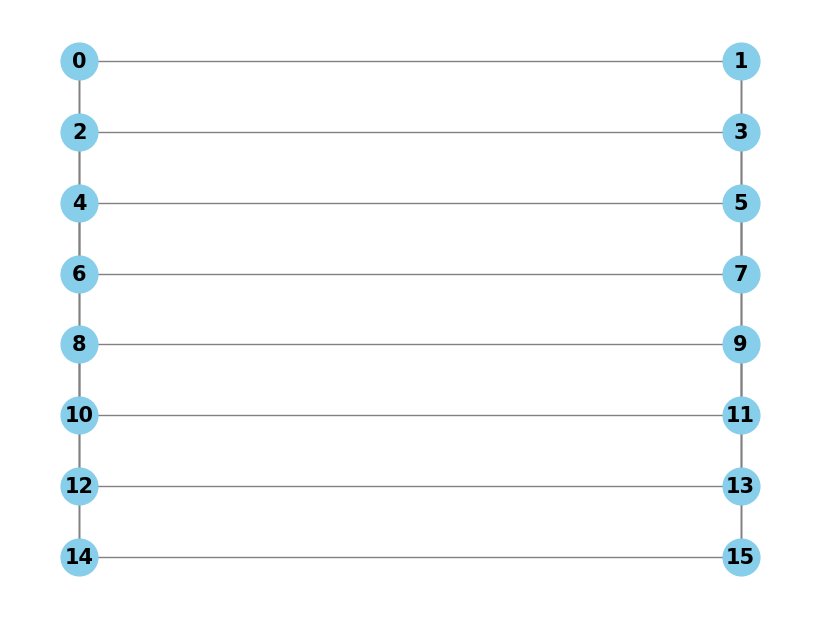

None


Greedy Matchings: 4
Compression-Aware Matchings: 4
Number of qubits: 4

Hamming Cost Analysis:
Total = 32, Edges = 32, Per Edge = 1.000

Sample Circuit - Greedy Matching (n_steps=1):


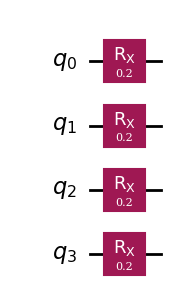


Sample Circuit - Compression-Aware Matching (n_steps=1):


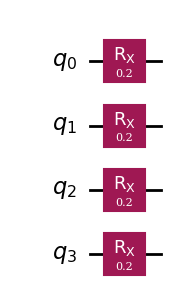


Gate Count Summary (U3/CX) for Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1             4/0          4/0                 4/0              4/0            4/0         4/0
       2             8/0          4/0                 8/0              4/0            8/0         4/0
       5            20/0          4/0                20/0              4/0           20/0         4/0
      10            40/0          4/0                40/0              4/0           40/0         4/0
      20            80/0          4/0                80/0              4/0           80/0         4/0
      50           200/0          4/0               200/0              4/0          200/0         4/0
     100           400/0          4/0               400/0              4/0          400/0         4/0

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      0 CX
  Comp-Aware Matching:  0 CX
  Pau

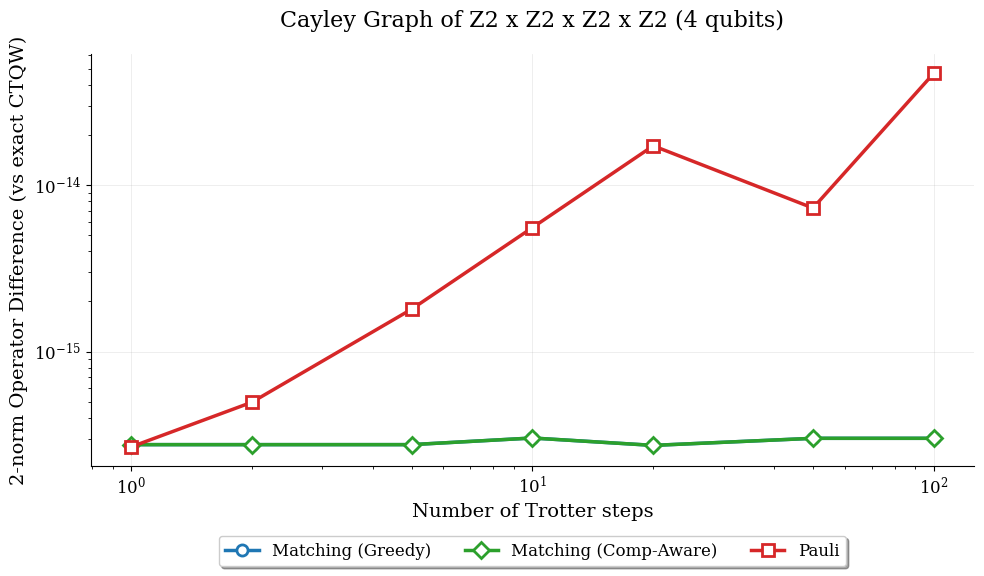

In [19]:
cayley_16 = set()
vertices_16 = [format(i, '04b') for i in range(16)]
generators_16 = ['0001', '0010', '0100', '1000']
for v in vertices_16:
    v_int = int(v, 2)
    for g in generators_16:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '04b')
        if v < neighbor:  # Avoid duplicates
            cayley_16.add((v, neighbor))
analyze_and_plot(cayley_16, "Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)")


Circulant Graph C8(1,2) (3 qubits)
Original edges: {('010', '011'), ('000', '010'), ('101', '110'), ('000', '001'), ('001', '011'), ('001', '111'), ('011', '101'), ('101', '111'), ('110', '111'), ('000', '110'), ('011', '100'), ('001', '010'), ('100', '110'), ('100', '101'), ('000', '111'), ('010', '100')}
Number of qubits: 3

Graph:


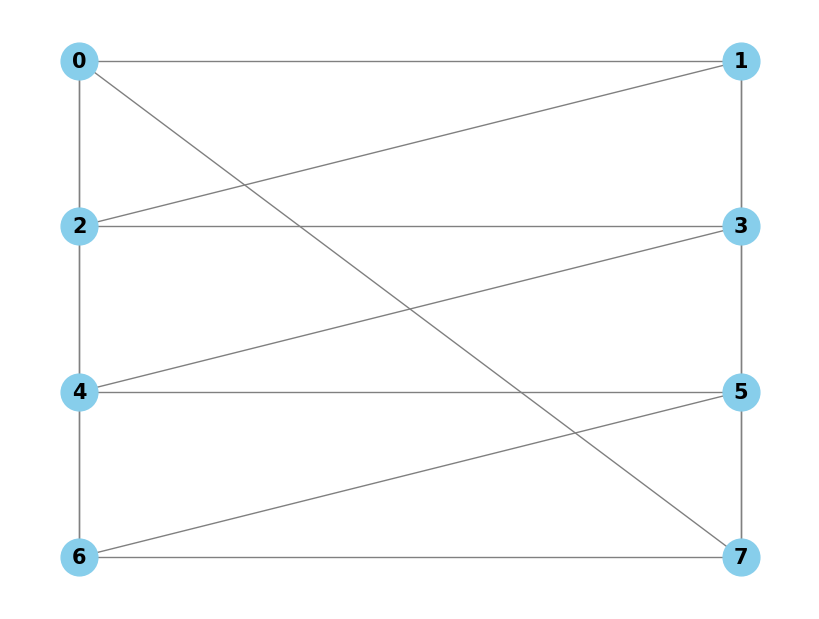

None


Greedy Matchings: 5
Compression-Aware Matchings: 4
Number of qubits: 3

Hamming Cost Analysis:
Total = 26, Edges = 16, Per Edge = 1.625

Sample Circuit - Greedy Matching (n_steps=1):


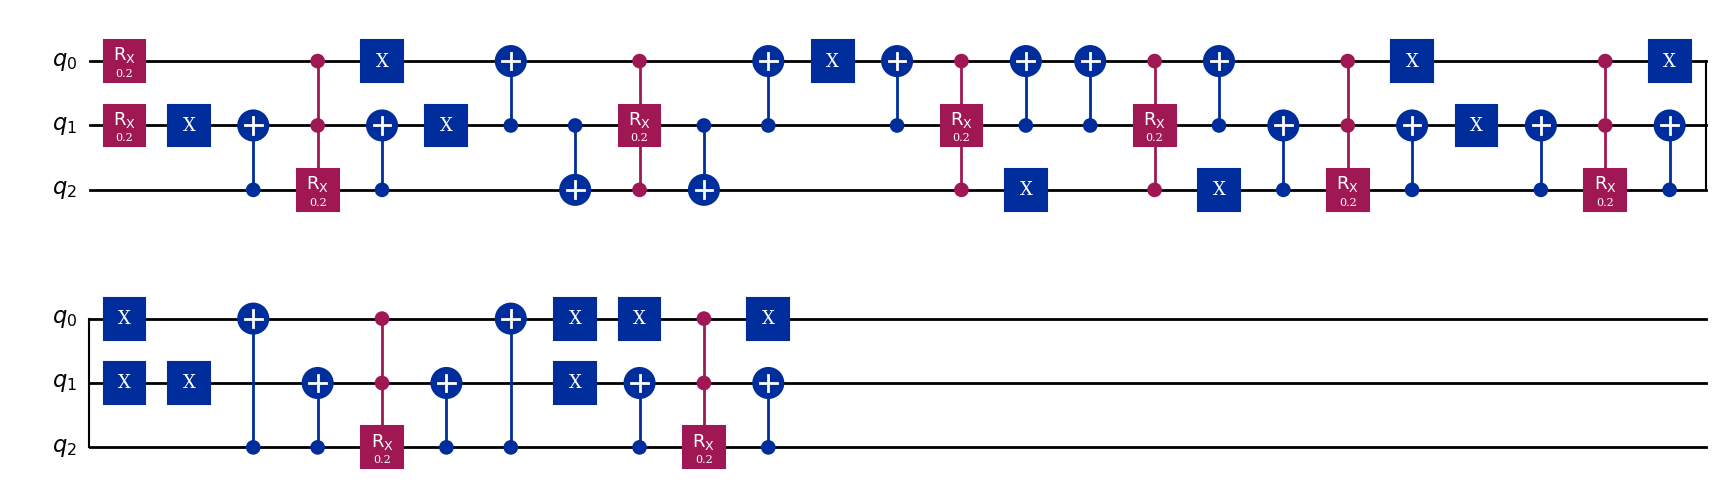


Sample Circuit - Compression-Aware Matching (n_steps=1):


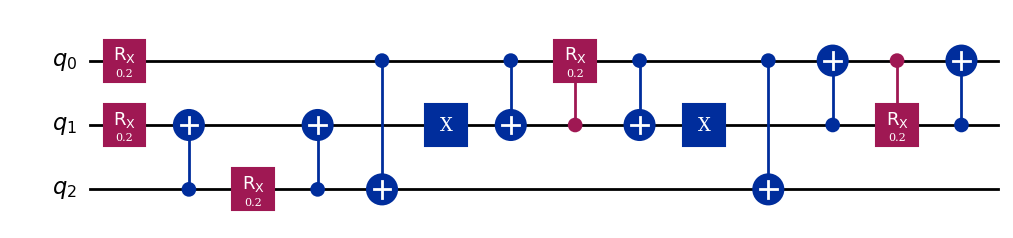


Gate Count Summary (U3/CX) for Circulant Graph C8(1,2) (3 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1          138/84        80/67               11/12             14/8          31/14        18/9
       2         276/168      156/133               22/24            26/16          62/28       32/18
       5         690/420      384/331               55/60            62/40         155/70       74/45
      10        1380/840      764/661             110/120           122/80        310/140      144/90
      20       2760/1680    1524/1321             220/240          242/160        620/280     284/180
      50       6900/4200    3804/3301             550/600          602/400       1550/700     753/450
     100      13800/8400    7604/6601           1100/1200         1202/800      3100/1400    1503/900

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      67 CX
  Comp-Aware Matching:  8 CX  (+88.1% vs gr

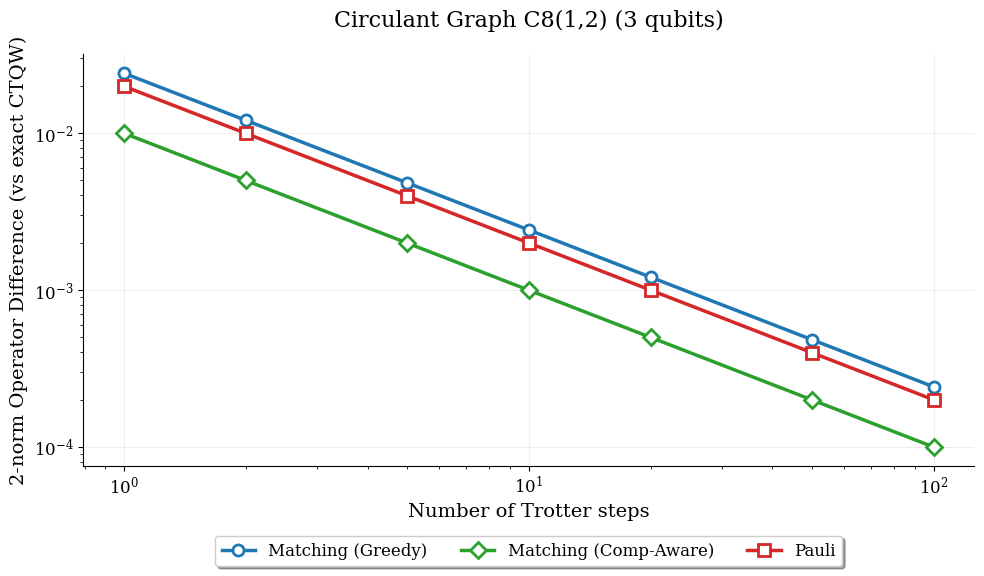

In [20]:
circulant_8 = set()
n = 8
offsets_8 = [1, 2]
for i in range(n):
    for offset in offsets_8:
        j = (i + offset) % n
        z1 = format(min(i, j), '03b')
        z2 = format(max(i, j), '03b')
        circulant_8.add((z1, z2))
analyze_and_plot(circulant_8, "Circulant Graph C8(1,2) (3 qubits)")


Circulant Graph C16(1,3,5) (4 qubits)
Original edges: {('0011', '0110'), ('0010', '1101'), ('1001', '1110'), ('1011', '1110'), ('0011', '1110'), ('0010', '0101'), ('1000', '1011'), ('1000', '1001'), ('1001', '1010'), ('0101', '1000'), ('0100', '0111'), ('1010', '1111'), ('0000', '1111'), ('0001', '0010'), ('1000', '1101'), ('0011', '0100'), ('1001', '1100'), ('1011', '1100'), ('1101', '1110'), ('0101', '0110'), ('0010', '1111'), ('0111', '1000'), ('0000', '0011'), ('0110', '0111'), ('1100', '1101'), ('0100', '1001'), ('0101', '1010'), ('0010', '0011'), ('1110', '1111'), ('0010', '0111'), ('0001', '0110'), ('0100', '0101'), ('0110', '1011'), ('1010', '1011'), ('0110', '1001'), ('0000', '0001'), ('0000', '1011'), ('0001', '1110'), ('0111', '1010'), ('1100', '1111'), ('0011', '1000'), ('1010', '1101'), ('0000', '1101'), ('0111', '1100'), ('0001', '0100'), ('0100', '1111'), ('0000', '0101'), ('0001', '1100')}
Number of qubits: 4

Graph:


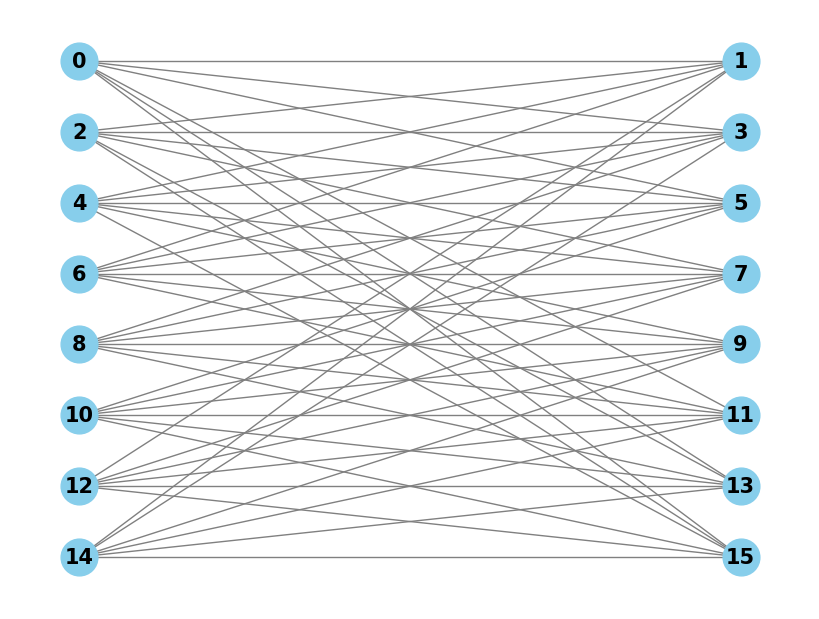

None


Greedy Matchings: 7
Compression-Aware Matchings: 6
Number of qubits: 4

Hamming Cost Analysis:
Total = 118, Edges = 48, Per Edge = 2.458

Sample Circuit - Greedy Matching (n_steps=1):


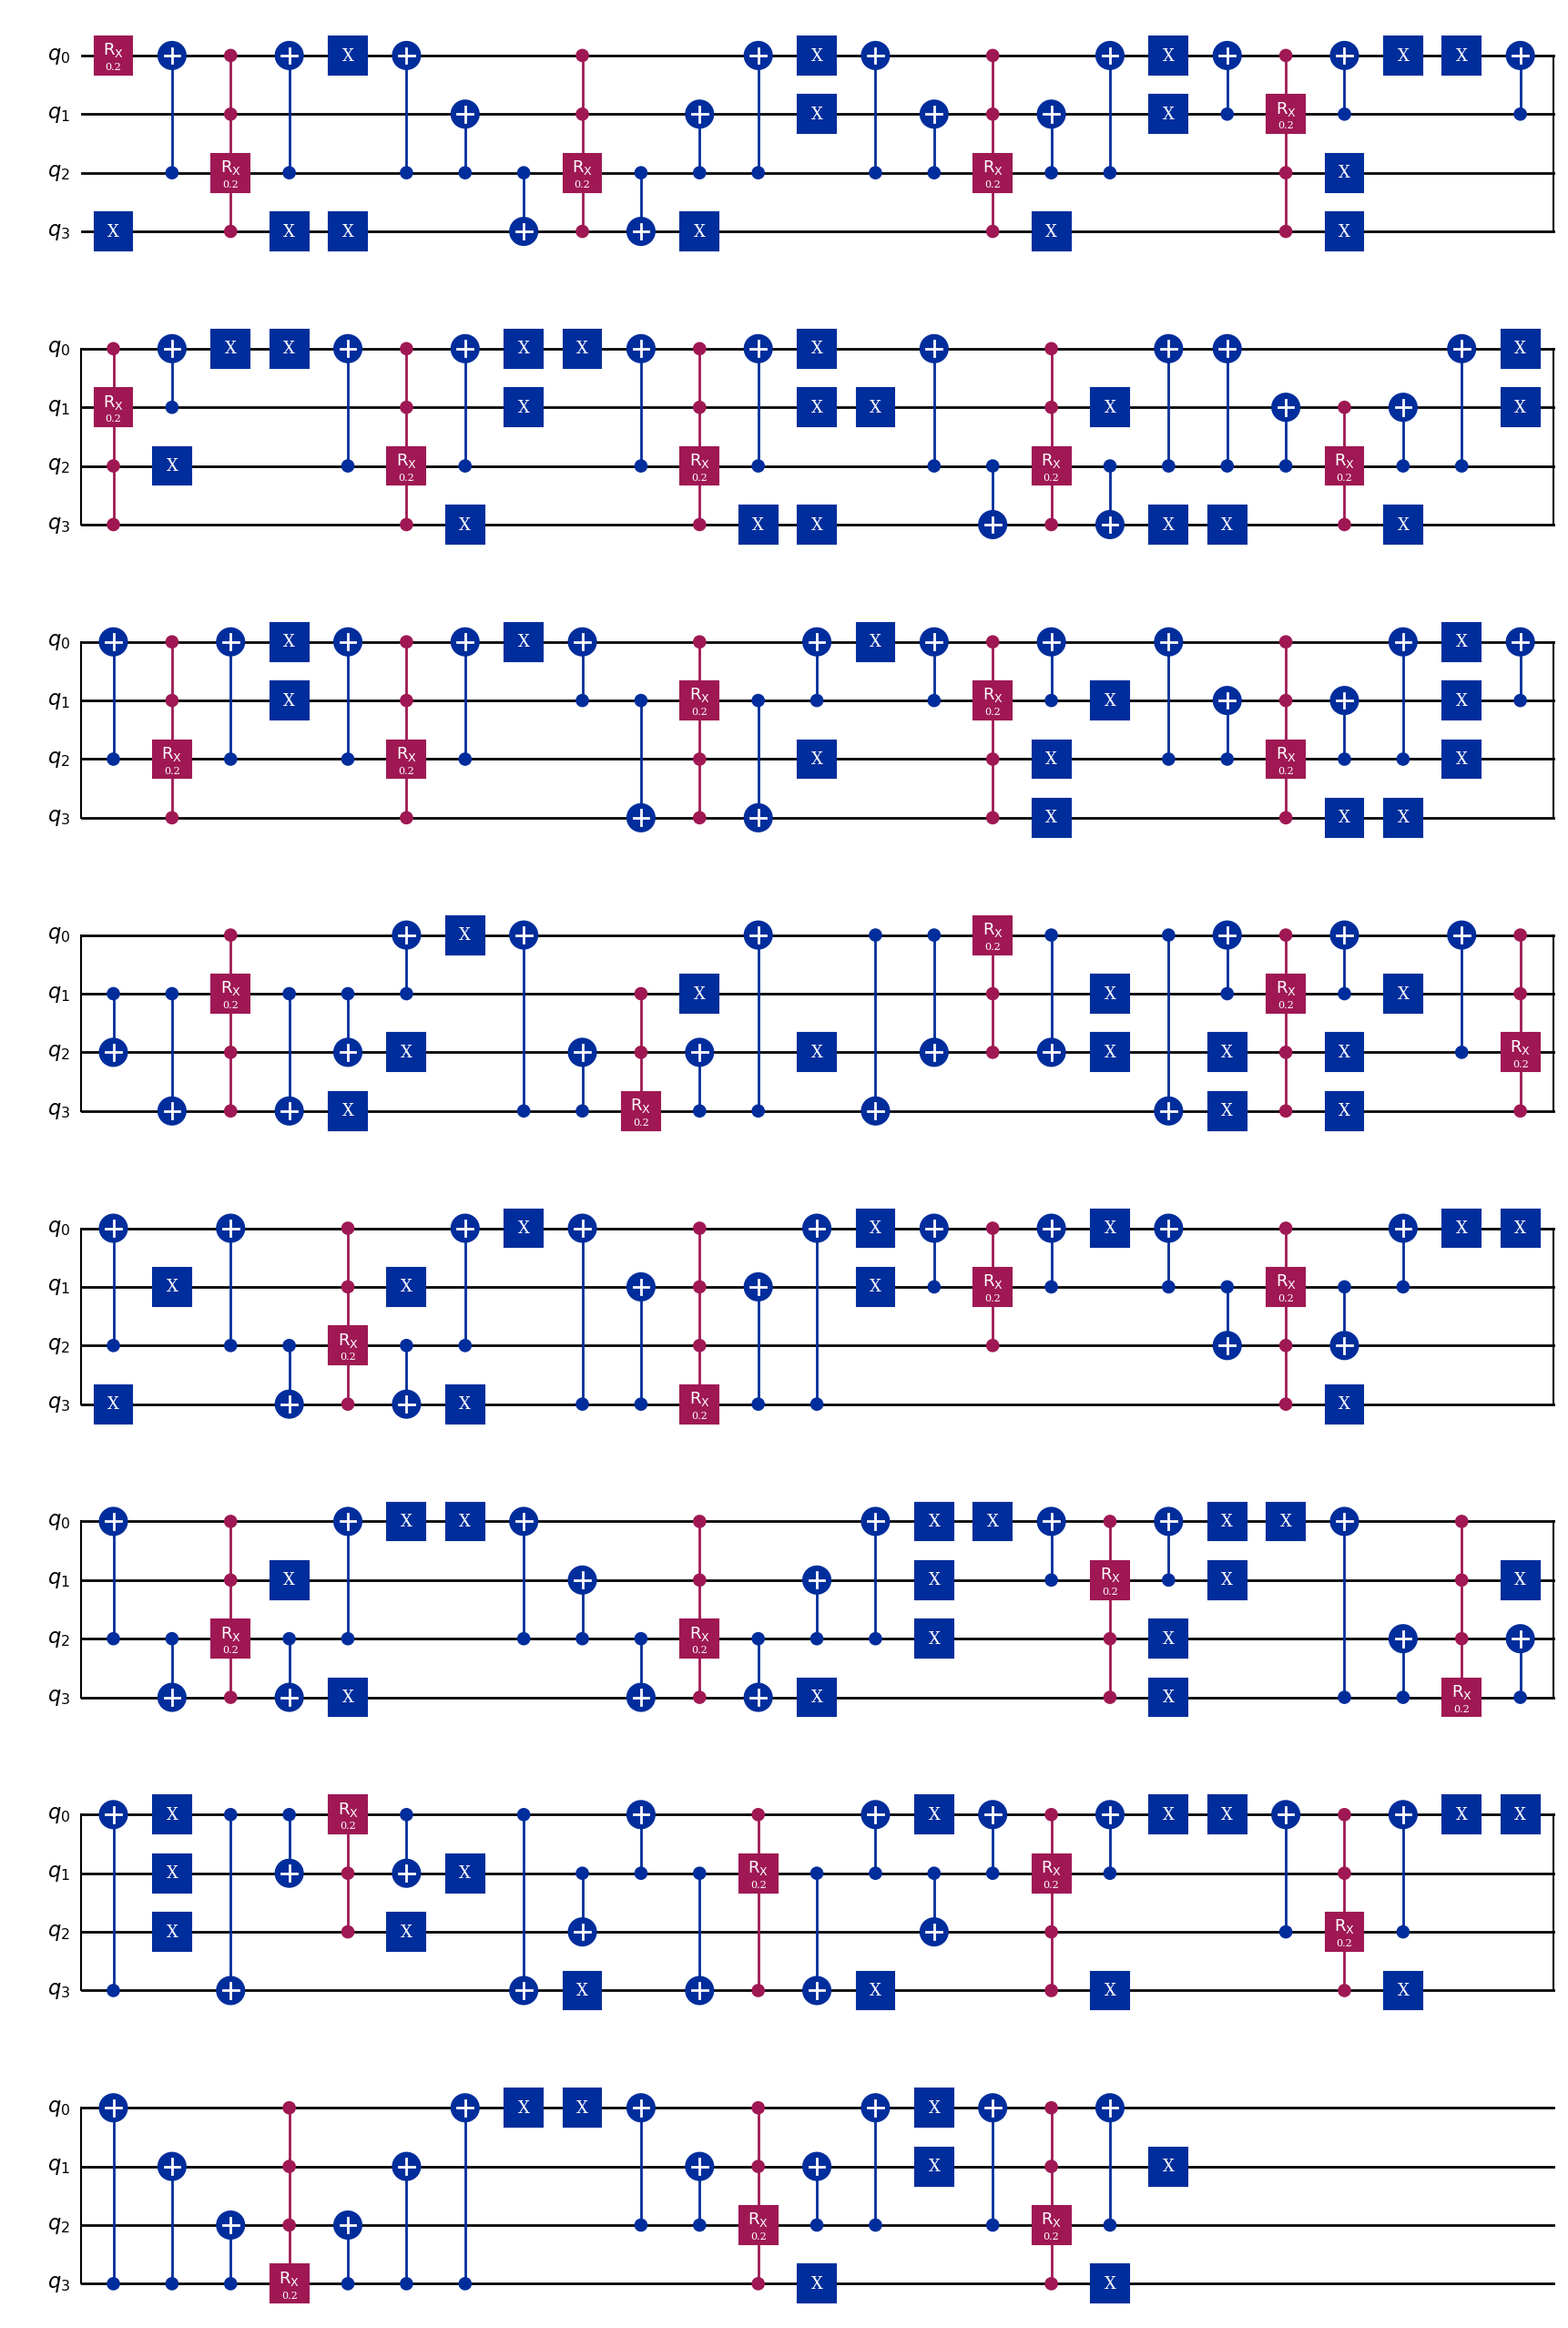


Sample Circuit - Compression-Aware Matching (n_steps=1):


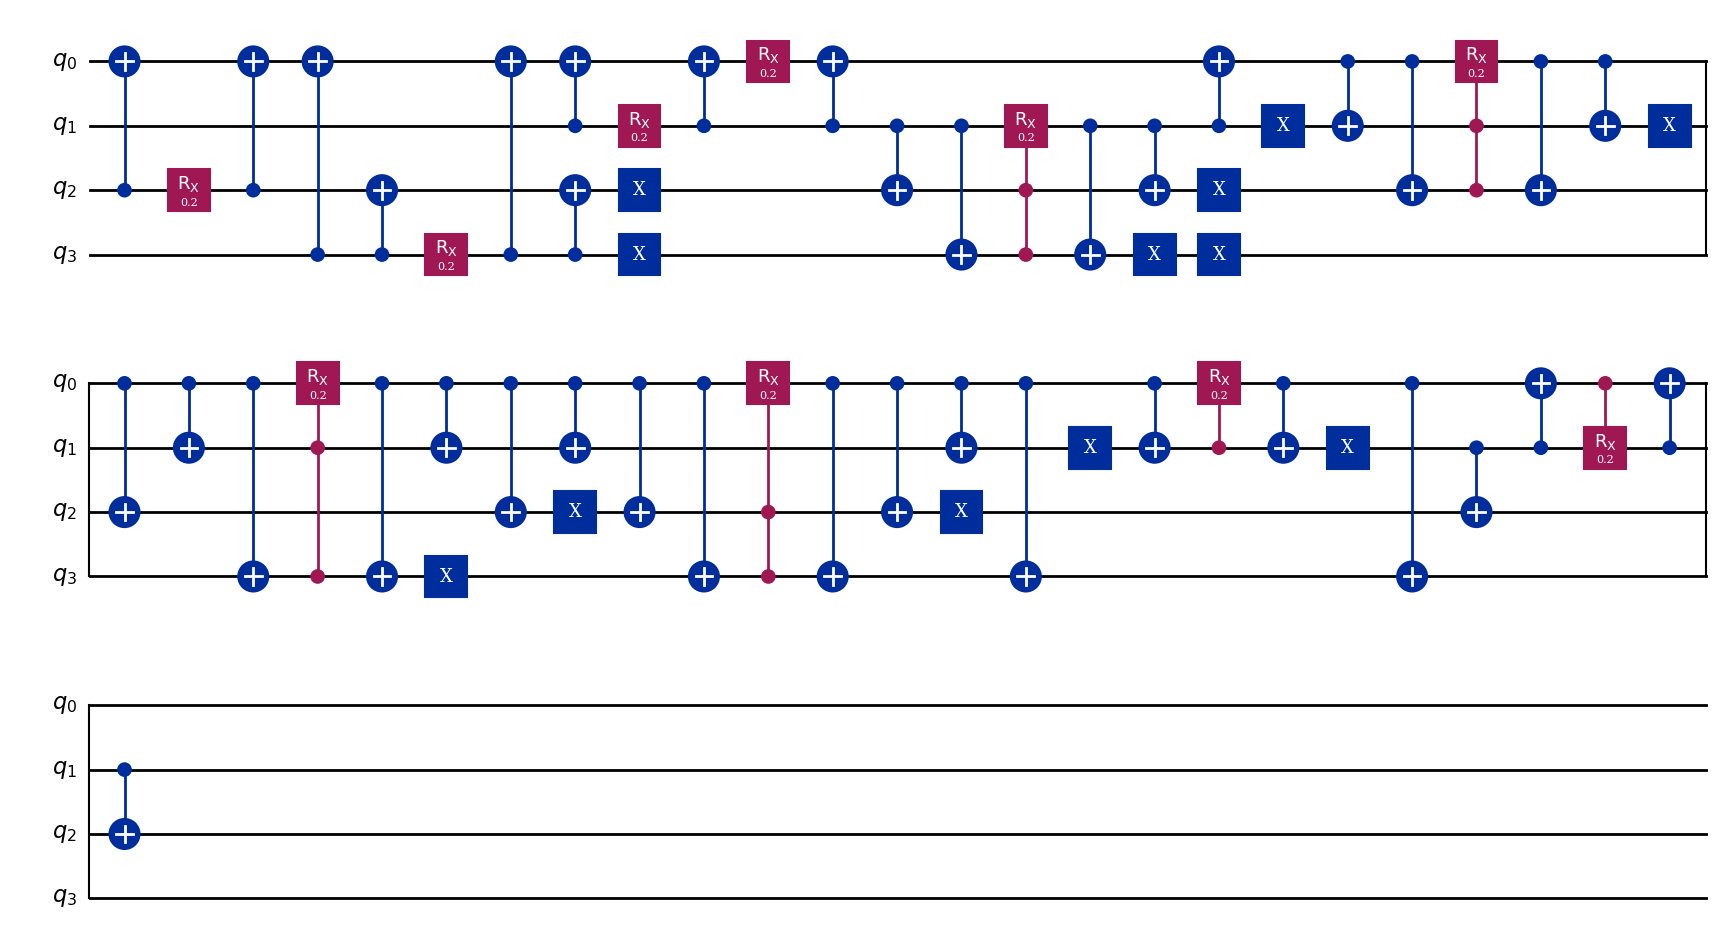


Gate Count Summary (U3/CX) for Circulant Graph C16(1,3,5) (4 qubits):
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1        1175/724      579/667               82/74            57/51          96/56       57/44
       2       2350/1448    1152/1333             164/148          114/101        192/112      109/88
       5       5875/3620    2871/3331             410/370          285/251        480/280     265/220
      10      11750/7240    5736/6661             820/740          570/501        960/560     525/440
      20     23500/14480  11486/13321           1640/1480        1140/1001      1920/1120    1045/880
      50     58750/36200  28706/33301           4100/3700        2900/2501      4800/2800   2605/2200
     100    117500/72400  57406/66601           8200/7400        5800/5001      9600/5600   5205/4400

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      667 CX
  Comp-Aware Matching:  51 CX  (+92.4% 

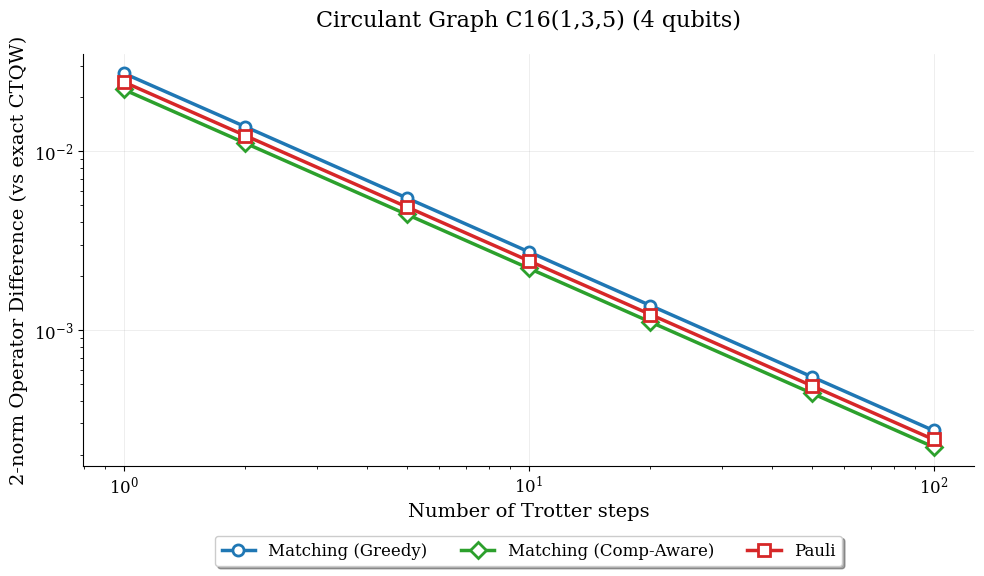

In [21]:
circulant_16 = set()
n = 16
offsets_16 = [1, 3, 5]
for i in range(n):
    for offset in offsets_16:
        j = (i + offset) % n
        z1 = format(min(i, j), '04b')
        z2 = format(max(i, j), '04b')
        circulant_16.add((z1, z2))
analyze_and_plot(circulant_16, "Circulant Graph C16(1,3,5) (4 qubits)")


Cayley Z2^5
Original edges: {('11000', '11010'), ('10110', '11110'), ('00110', '00111'), ('00100', '10100'), ('00010', '00011'), ('10001', '11001'), ('01101', '11101'), ('01101', '01111'), ('00000', '00100'), ('00100', '00110'), ('01011', '11011'), ('01100', '01101'), ('10000', '10010'), ('10011', '11011'), ('00111', '10111'), ('00101', '01101'), ('01011', '01111'), ('10100', '10101'), ('10011', '10111'), ('00001', '00101'), ('00100', '00101'), ('01001', '11001'), ('00011', '01011'), ('01000', '01100'), ('00000', '01000'), ('00101', '10101'), ('01000', '11000'), ('10000', '11000'), ('00001', '00011'), ('10100', '11100'), ('10010', '11010'), ('10110', '10111'), ('00000', '00001'), ('10101', '11101'), ('00100', '01100'), ('00010', '01010'), ('11010', '11110'), ('00110', '01110'), ('10010', '10110'), ('11010', '11011'), ('00000', '10000'), ('11000', '11001'), ('01010', '01110'), ('00101', '00111'), ('00011', '10011'), ('00000', '00010'), ('11000', '11100'), ('00011', '00111'), ('11011', 

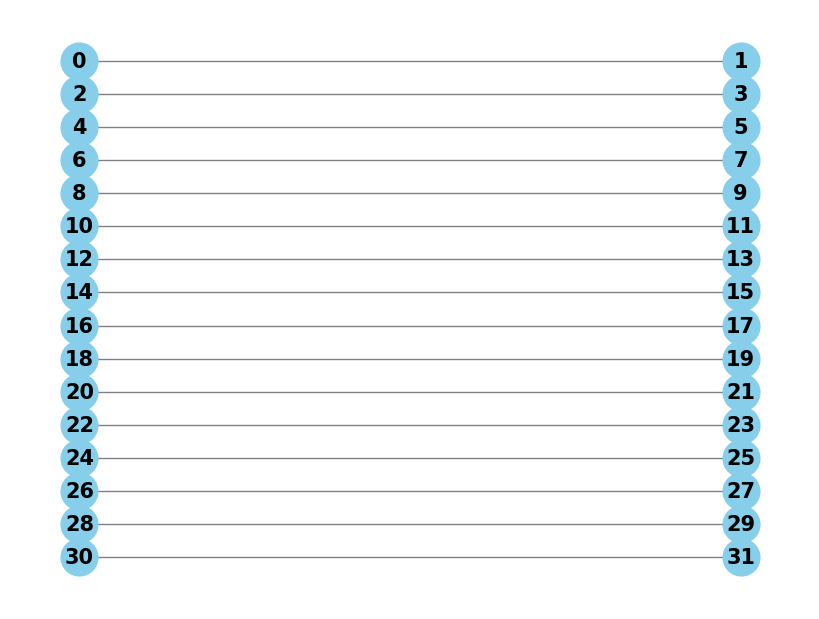

None


Greedy Matchings: 5
Compression-Aware Matchings: 5
Number of qubits: 5

Hamming Cost Analysis:
Total = 80, Edges = 80, Per Edge = 1.000

Sample Circuit - Greedy Matching (n_steps=1):


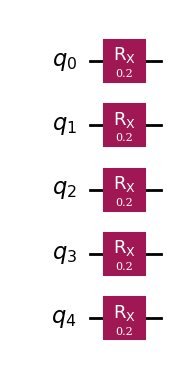


Sample Circuit - Compression-Aware Matching (n_steps=1):


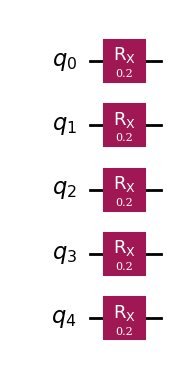


Gate Count Summary (U3/CX) for Cayley Z2^5:
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1             5/0          5/0                 5/0              5/0            5/0         5/0
       2            10/0          5/0                10/0              5/0           10/0         5/0
       5            25/0          5/0                25/0              5/0           25/0         5/0
      10            50/0          5/0                50/0              5/0           50/0         5/0
      20           100/0          5/0               100/0              5/0          100/0         5/0
      50           250/0          5/0               250/0              5/0          250/0         5/0
     100           500/0          5/0               500/0              5/0          500/0         5/0

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      0 CX
  Comp-Aware Matching:  0 CX
  Pauli:                0 CX

Hamming 

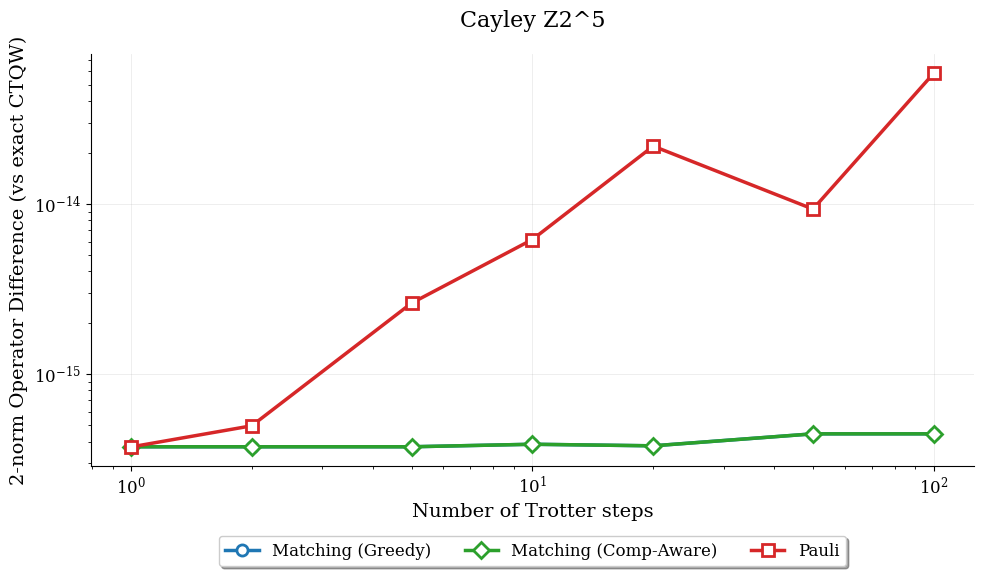

In [22]:
# 5 qubits: Cayley graph of Z2^5 with standard generators (bit flips)
cayley_edges = set()
for i in range(32):
    node_i = format(i, '05b')
    for bit_pos in range(5):
        j = i ^ (1 << bit_pos)  # XOR to flip bit
        node_j = format(j, '05b')
        if i < j:  # Avoid duplicates
            cayley_edges.add((node_i, node_j))

analyze_and_plot(cayley_edges, "Cayley Z2^5")


Circulant C32(1,2,5)
Original edges: {('11000', '11010'), ('00110', '00111'), ('01011', '01101'), ('01111', '10100'), ('01110', '10000'), ('00010', '00011'), ('10010', '10100'), ('10111', '11100'), ('00000', '00101'), ('01101', '01111'), ('00001', '00110'), ('00100', '00110'), ('01100', '01101'), ('00011', '00101'), ('10000', '10010'), ('01001', '01010'), ('00011', '00100'), ('01010', '01111'), ('10100', '10101'), ('11000', '11101'), ('00100', '00101'), ('10100', '11001'), ('01011', '10000'), ('10101', '10110'), ('00000', '11110'), ('10110', '11011'), ('00000', '11011'), ('00011', '11110'), ('00011', '01000'), ('00001', '00011'), ('10110', '10111'), ('10011', '10100'), ('00010', '00111'), ('00000', '00001'), ('10001', '10010'), ('10000', '10101'), ('00111', '01100'), ('11010', '11011'), ('00000', '11111'), ('11000', '11001'), ('10101', '11010'), ('00101', '00111'), ('00101', '01010'), ('00111', '01000'), ('10111', '11000'), ('11011', '11101'), ('01001', '01110'), ('11001', '11010'), (

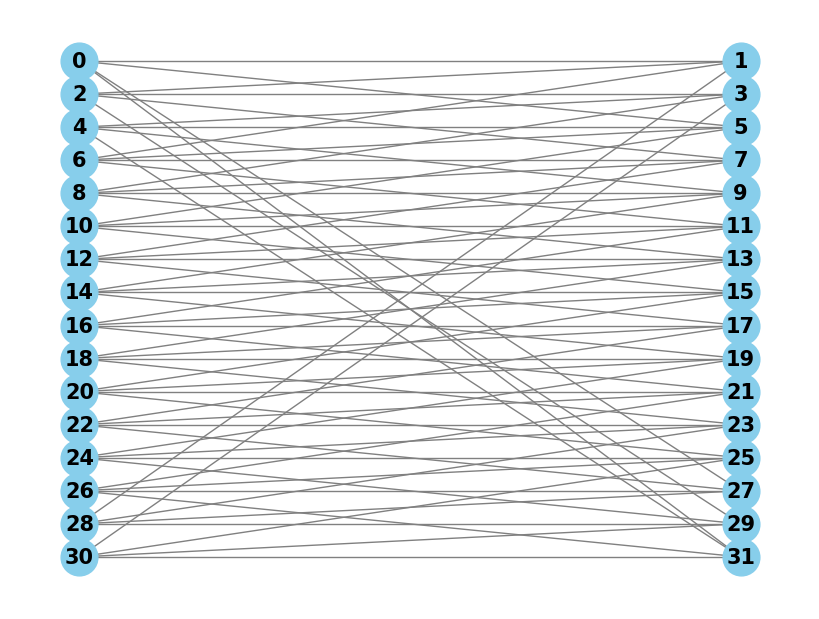

None


Greedy Matchings: 8
Compression-Aware Matchings: 6
Number of qubits: 5

Hamming Cost Analysis:
Total = 224, Edges = 96, Per Edge = 2.333

Sample Circuit - Greedy Matching (n_steps=1):


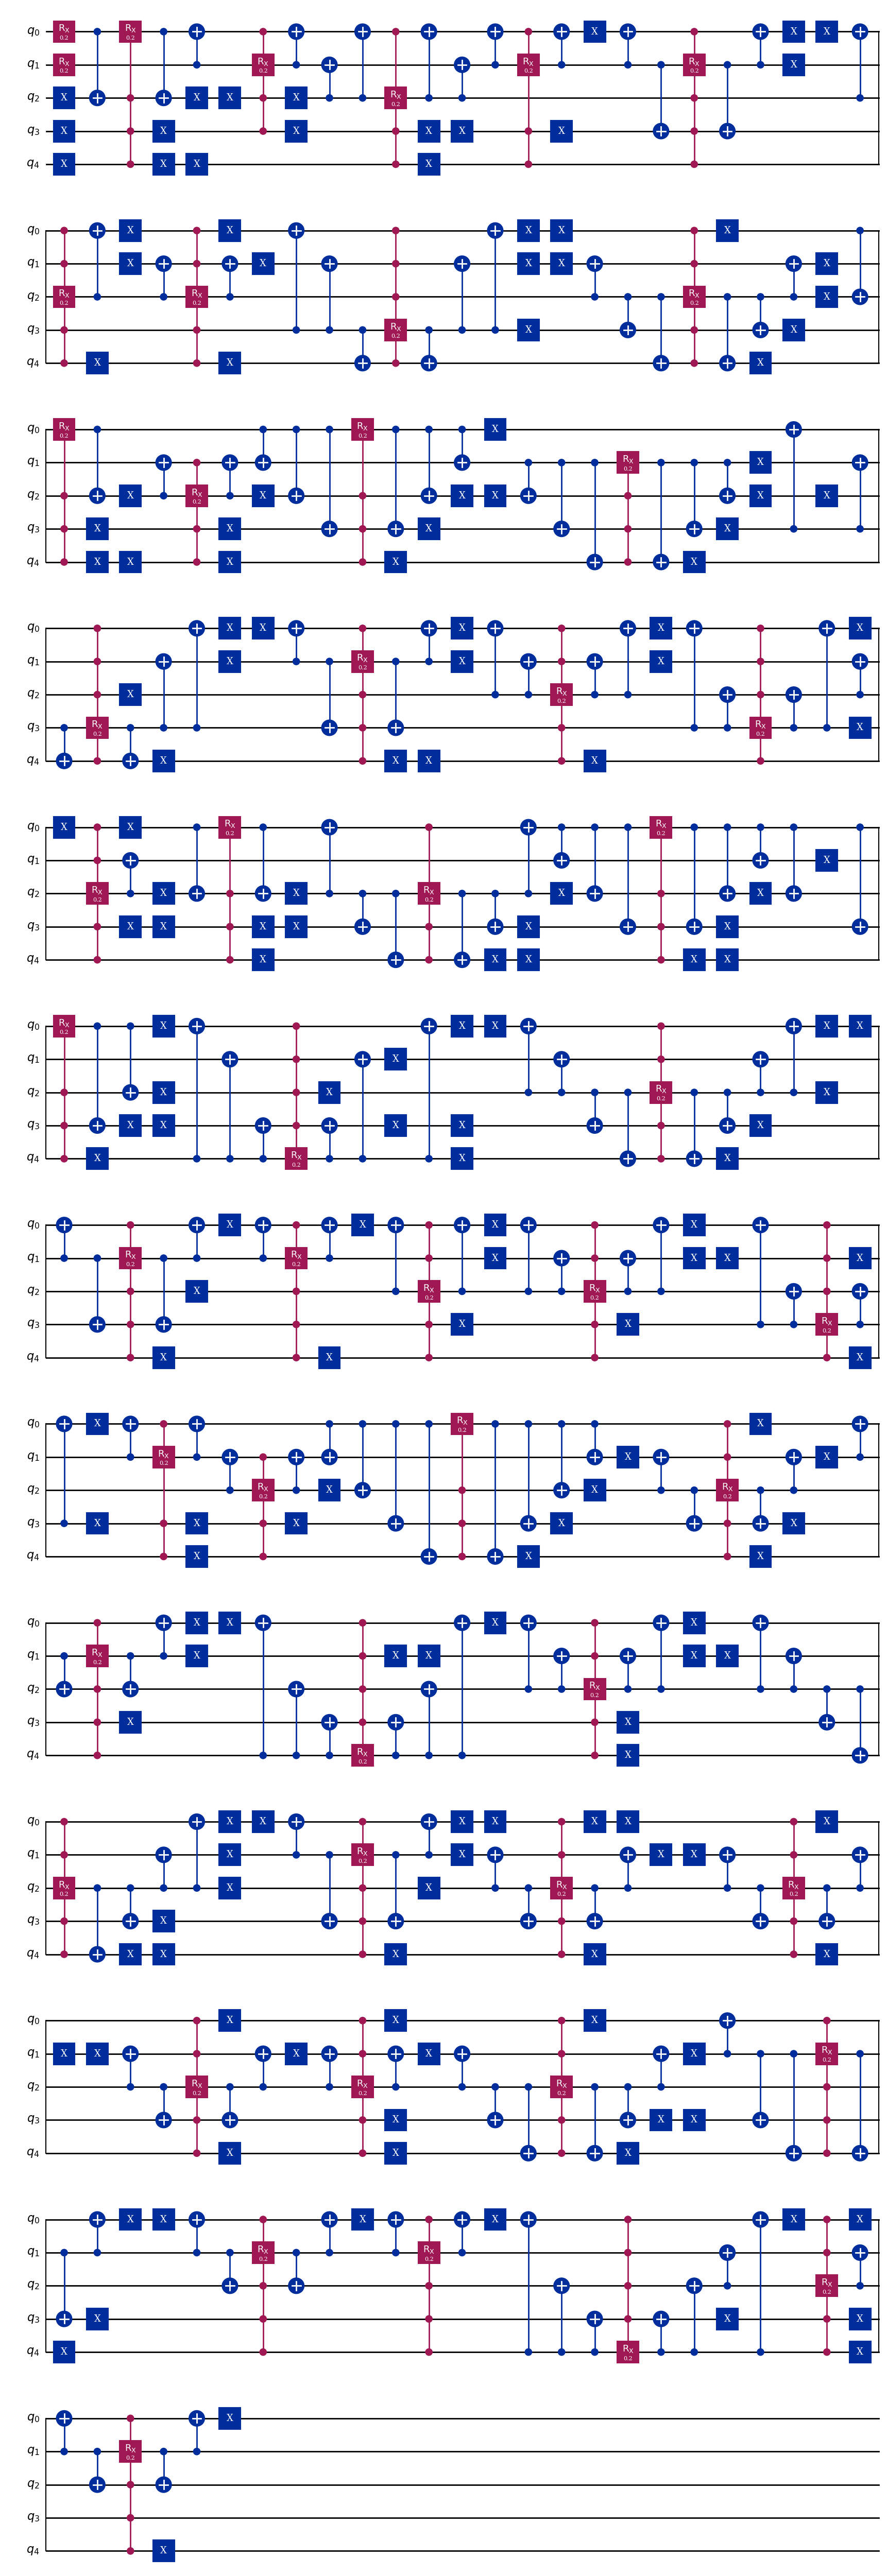


Sample Circuit - Compression-Aware Matching (n_steps=1):


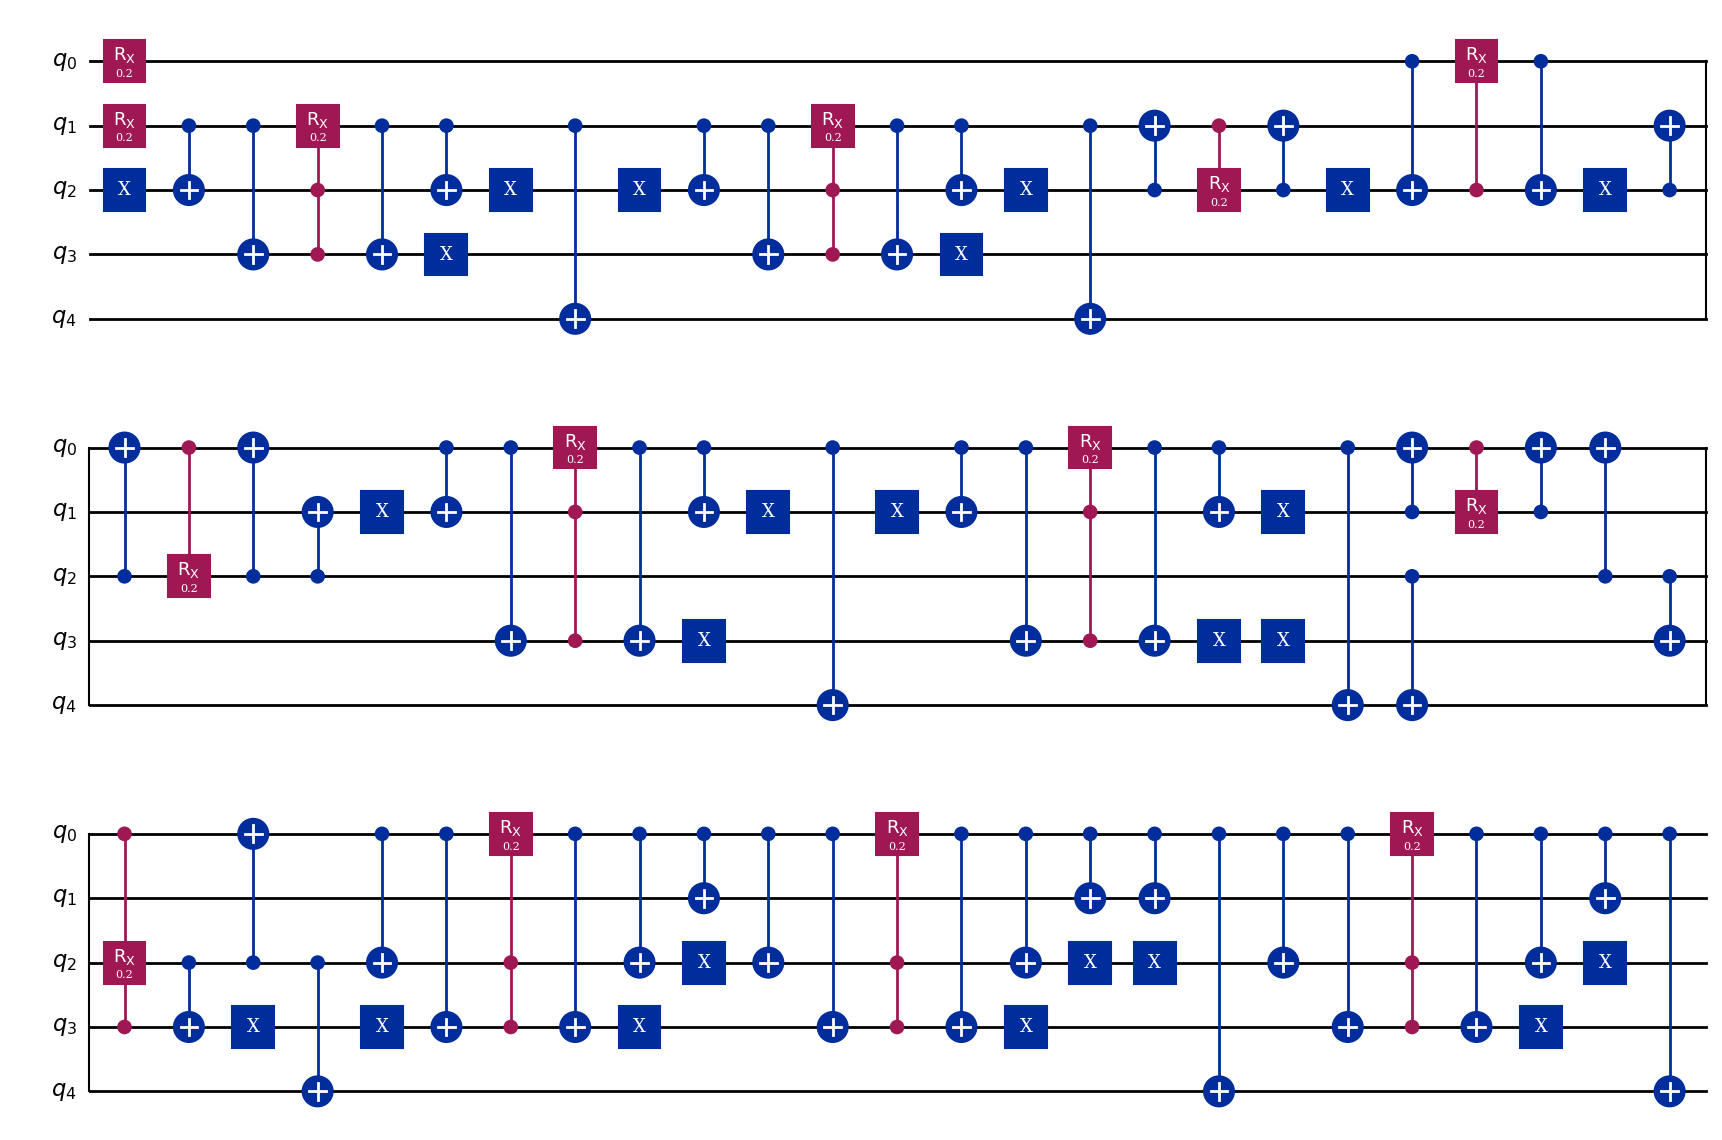


Gate Count Summary (U3/CX) for Circulant C32(1,2,5):
 n_steps Greedy (No Opt)  Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1       2141/1316     1256/1271             158/126           100/96        318/196     135/105
       2       4282/2632     2509/2542             316/252          197/192        636/392     264/210
       5      10705/6580     6268/6355             790/630          488/480       1590/980     651/525
      10     21410/13160   12543/12710           1580/1260          973/960      3180/1960   1296/1050
      20     42820/26320   25083/25420           3160/2520        1943/1920      6360/3920   2586/2100
      50    107050/65800   62703/63550           7900/6300        4853/4800     15900/9800   6456/5250
     100   214100/131600 125403/127100         15800/12600        9703/9600    31800/19600 12906/10500

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      1271 CX
  Comp-Aware Matching:  96 CX  (+92.4% vs greed

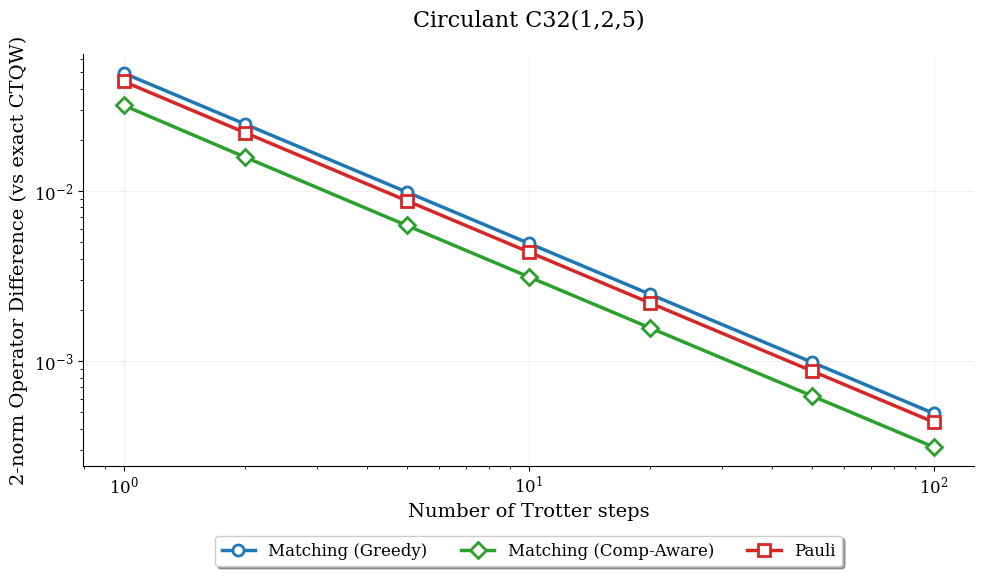

In [23]:
# 5 qubits: Circulant graph C32(1,2,5)
circ_edges = set()
offsets = [1, 2, 5]
for i in range(32):
    for offset in offsets:
        j = (i + offset) % 32
        z1 = format(min(i, j), '05b')
        z2 = format(max(i, j), '05b')
        circ_edges.add((z1, z2))

analyze_and_plot(circ_edges, "Circulant C32(1,2,5)")


Path P32
Original edges: {('00110', '00111'), ('01011', '01100'), ('00111', '01000'), ('10101', '10110'), ('11100', '11101'), ('10111', '11000'), ('01000', '01001'), ('11001', '11010'), ('00010', '00011'), ('10000', '10001'), ('01100', '01101'), ('00101', '00110'), ('01001', '01010'), ('00011', '00100'), ('10110', '10111'), ('01111', '10000'), ('11101', '11110'), ('10011', '10100'), ('00000', '00001'), ('01101', '01110'), ('10001', '10010'), ('10010', '10011'), ('10100', '10101'), ('11011', '11100'), ('11110', '11111'), ('11010', '11011'), ('01110', '01111'), ('11000', '11001'), ('01010', '01011'), ('00100', '00101'), ('00001', '00010')}
Number of qubits: 5

Graph:


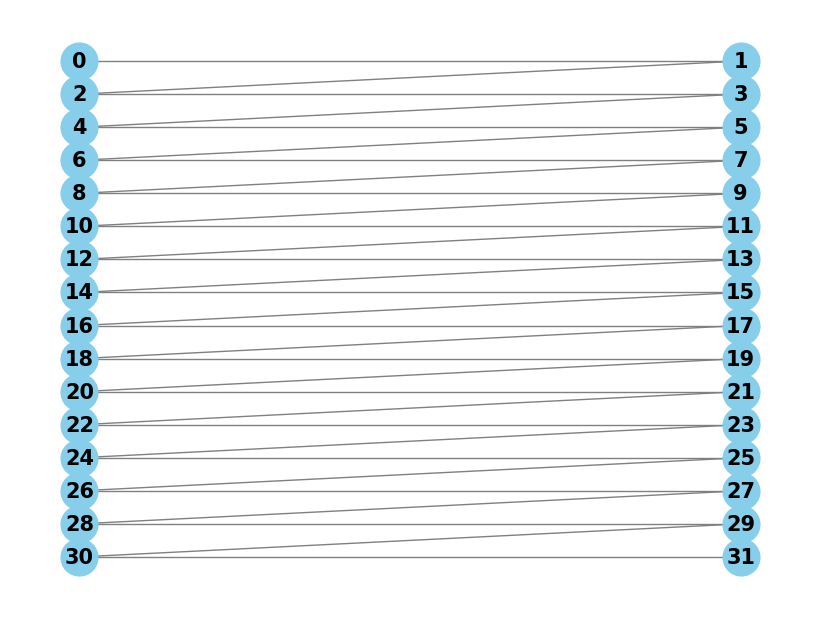

None


Greedy Matchings: 2
Compression-Aware Matchings: 2
Number of qubits: 5

Hamming Cost Analysis:
Total = 57, Edges = 31, Per Edge = 1.839

Sample Circuit - Greedy Matching (n_steps=1):


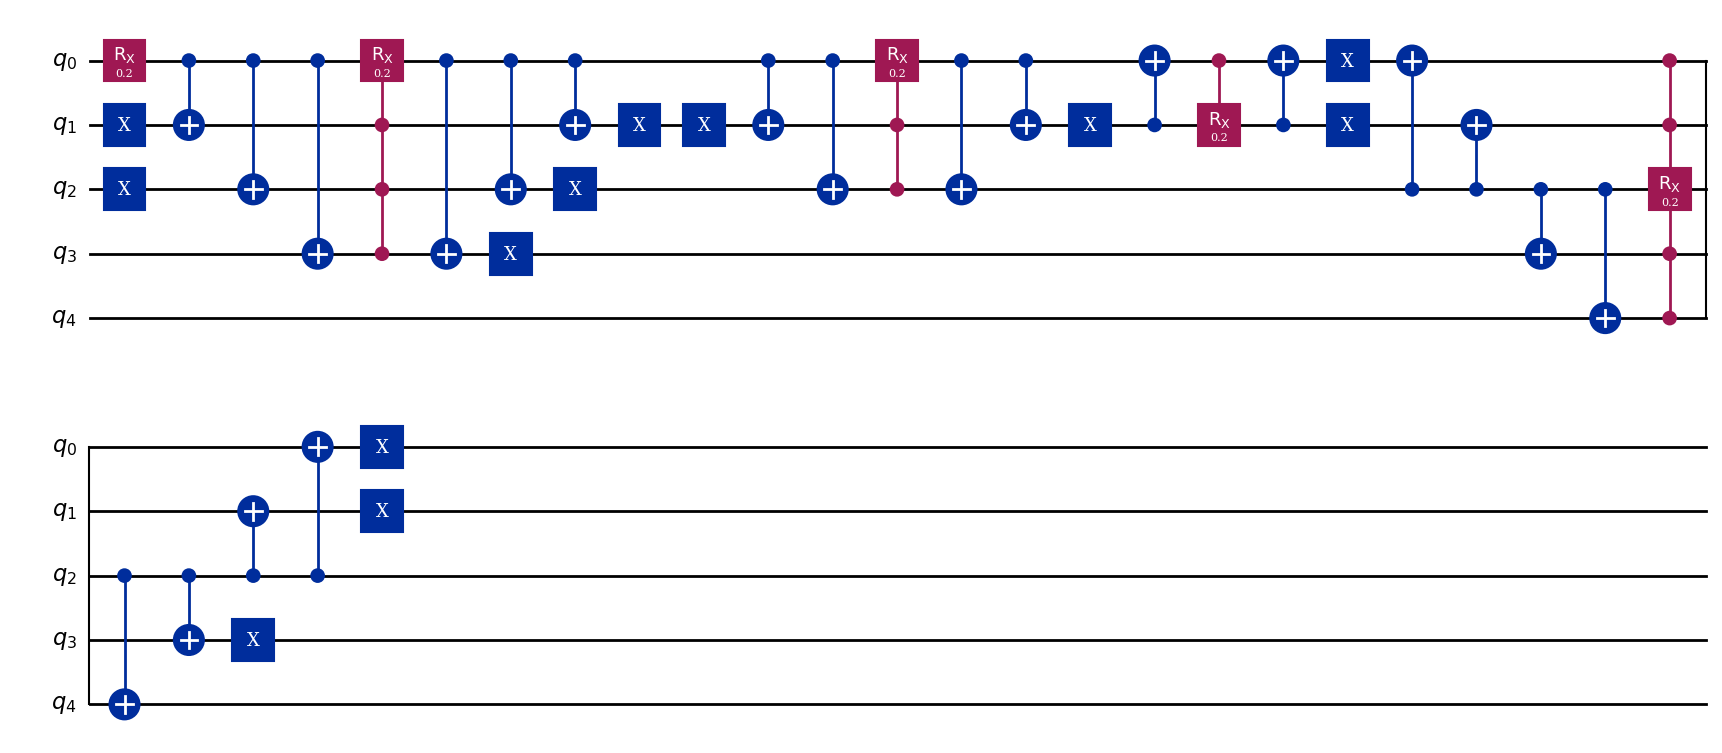


Sample Circuit - Compression-Aware Matching (n_steps=1):


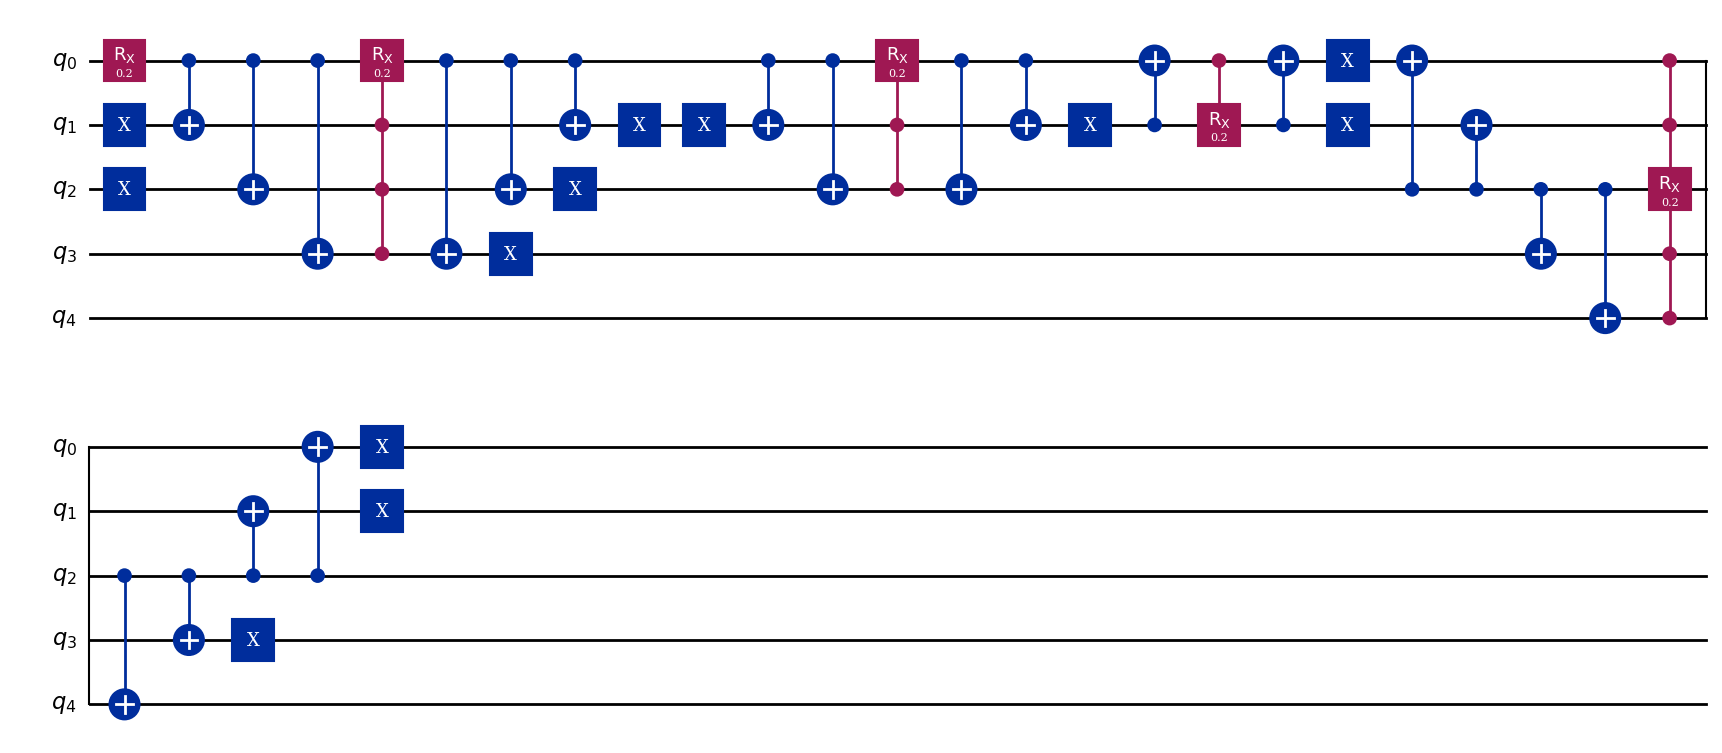


Gate Count Summary (U3/CX) for Path P32:
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1          108/74        64/66              108/74            64/66        287/196     172/124
       2         216/148      124/132             216/148          124/132        574/392     339/248
       5         540/370      304/330             540/370          304/330       1435/980     840/620
      10        1080/740      604/660            1080/740          604/660      2870/1960   1675/1240
      20       2160/1480    1204/1320           2160/1480        1204/1320      5740/3920   3345/2480
      50       5400/3700    3004/3300           5400/3700        3004/3300     14350/9800   8355/6200
     100      10800/7400    6004/6600          10800/7400        6004/6600    28700/19600 16705/12400

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      66 CX
  Comp-Aware Matching:  66 CX  (+0.0% vs greedy)
  Pauli:            

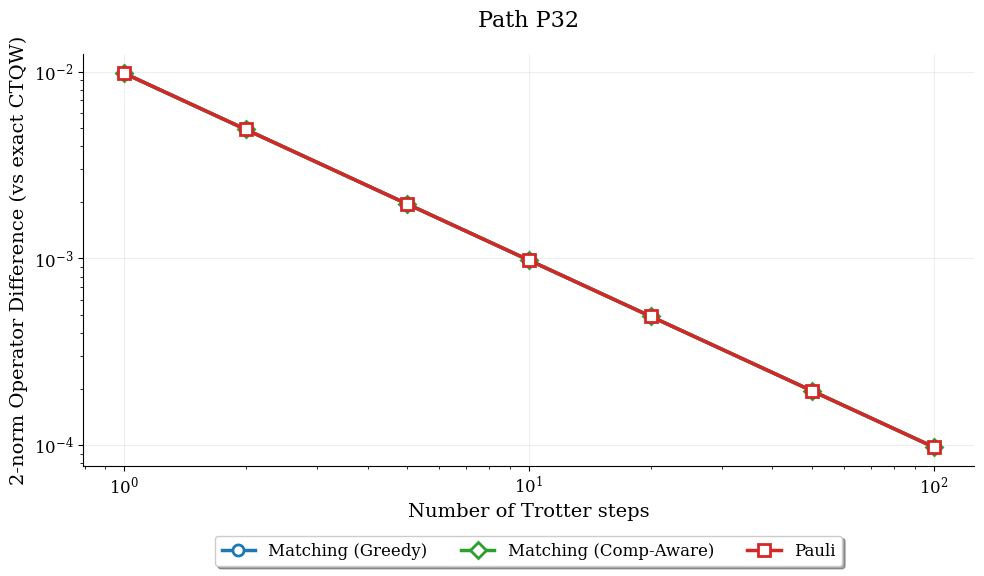

In [24]:
# 5 qubits: Path graph P32
path_edges = set()
for i in range(31):
    node_i = format(i, '05b')
    node_j = format(i+1, '05b')
    path_edges.add((node_i, node_j))

analyze_and_plot(path_edges, "Path P32")


Cycle C32
Original edges: {('00110', '00111'), ('01011', '01100'), ('00111', '01000'), ('10101', '10110'), ('11100', '11101'), ('10111', '11000'), ('01000', '01001'), ('11001', '11010'), ('00010', '00011'), ('10000', '10001'), ('01100', '01101'), ('00101', '00110'), ('01001', '01010'), ('00011', '00100'), ('10110', '10111'), ('01111', '10000'), ('11101', '11110'), ('10011', '10100'), ('00000', '00001'), ('01101', '01110'), ('10001', '10010'), ('10010', '10011'), ('10100', '10101'), ('11011', '11100'), ('11110', '11111'), ('11010', '11011'), ('01110', '01111'), ('00000', '11111'), ('11000', '11001'), ('01010', '01011'), ('00100', '00101'), ('00001', '00010')}
Number of qubits: 5

Graph:


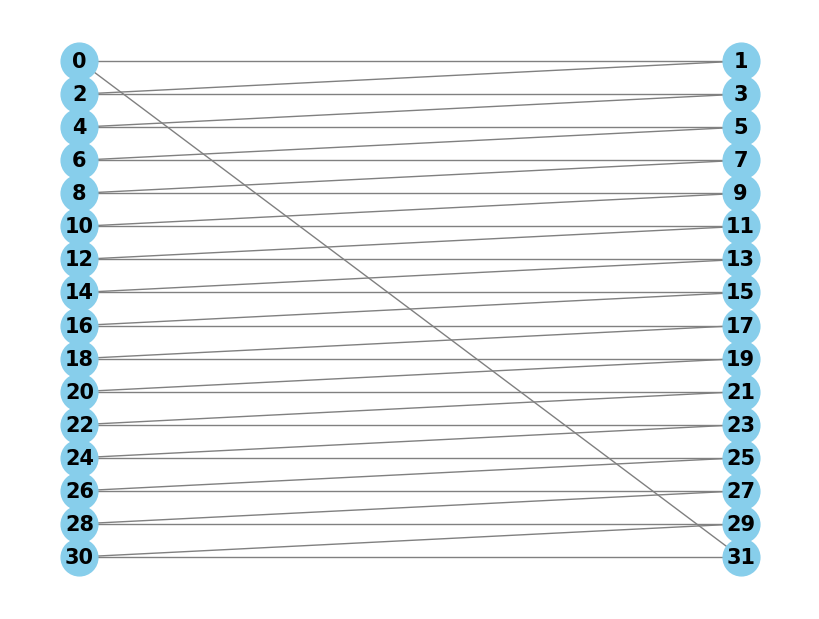

None


Greedy Matchings: 2
Compression-Aware Matchings: 2
Number of qubits: 5

Hamming Cost Analysis:
Total = 62, Edges = 32, Per Edge = 1.938

Sample Circuit - Greedy Matching (n_steps=1):


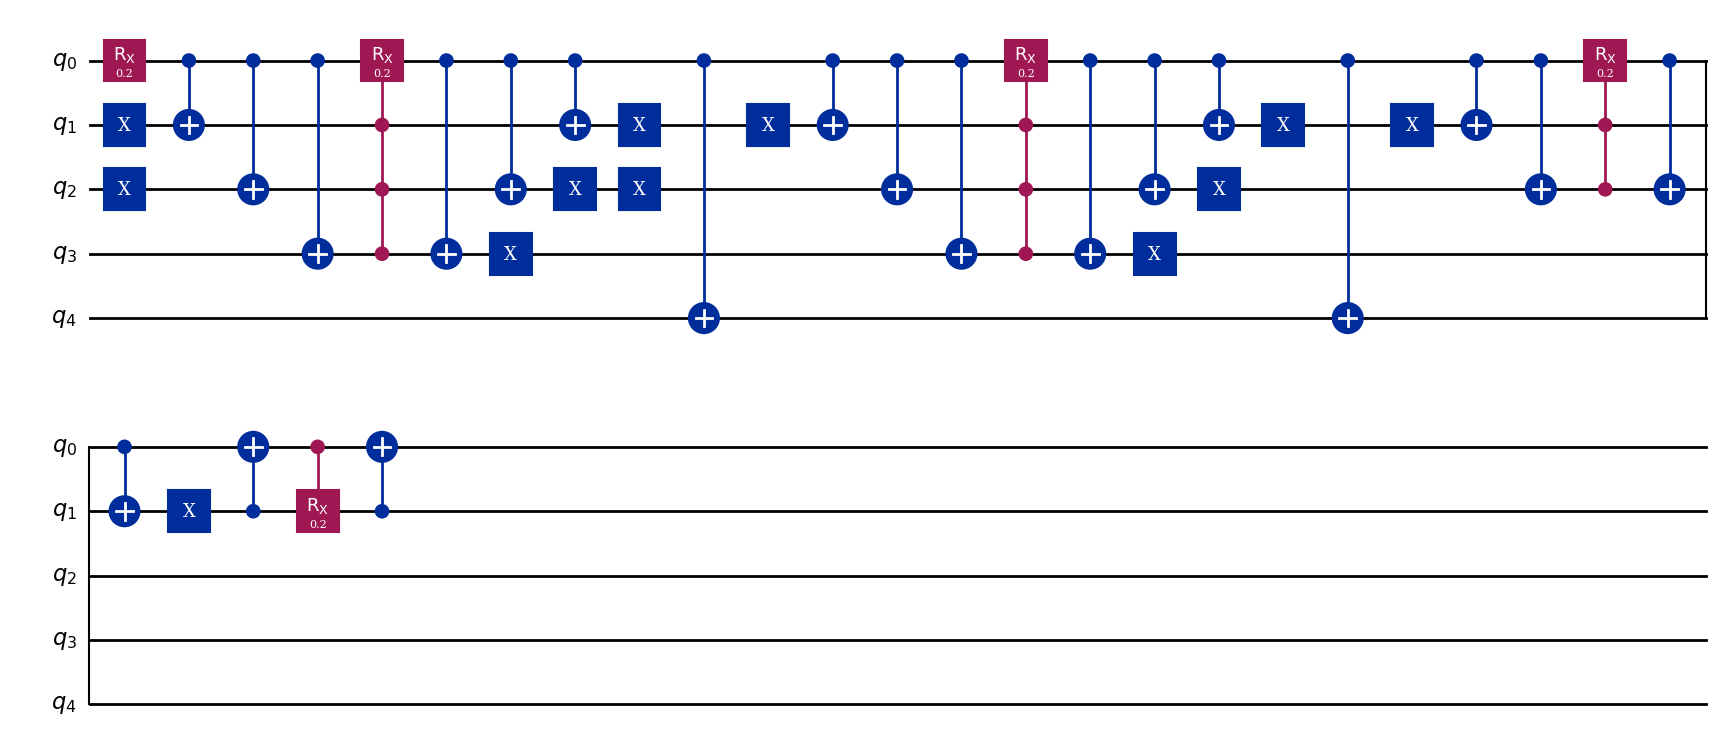


Sample Circuit - Compression-Aware Matching (n_steps=1):


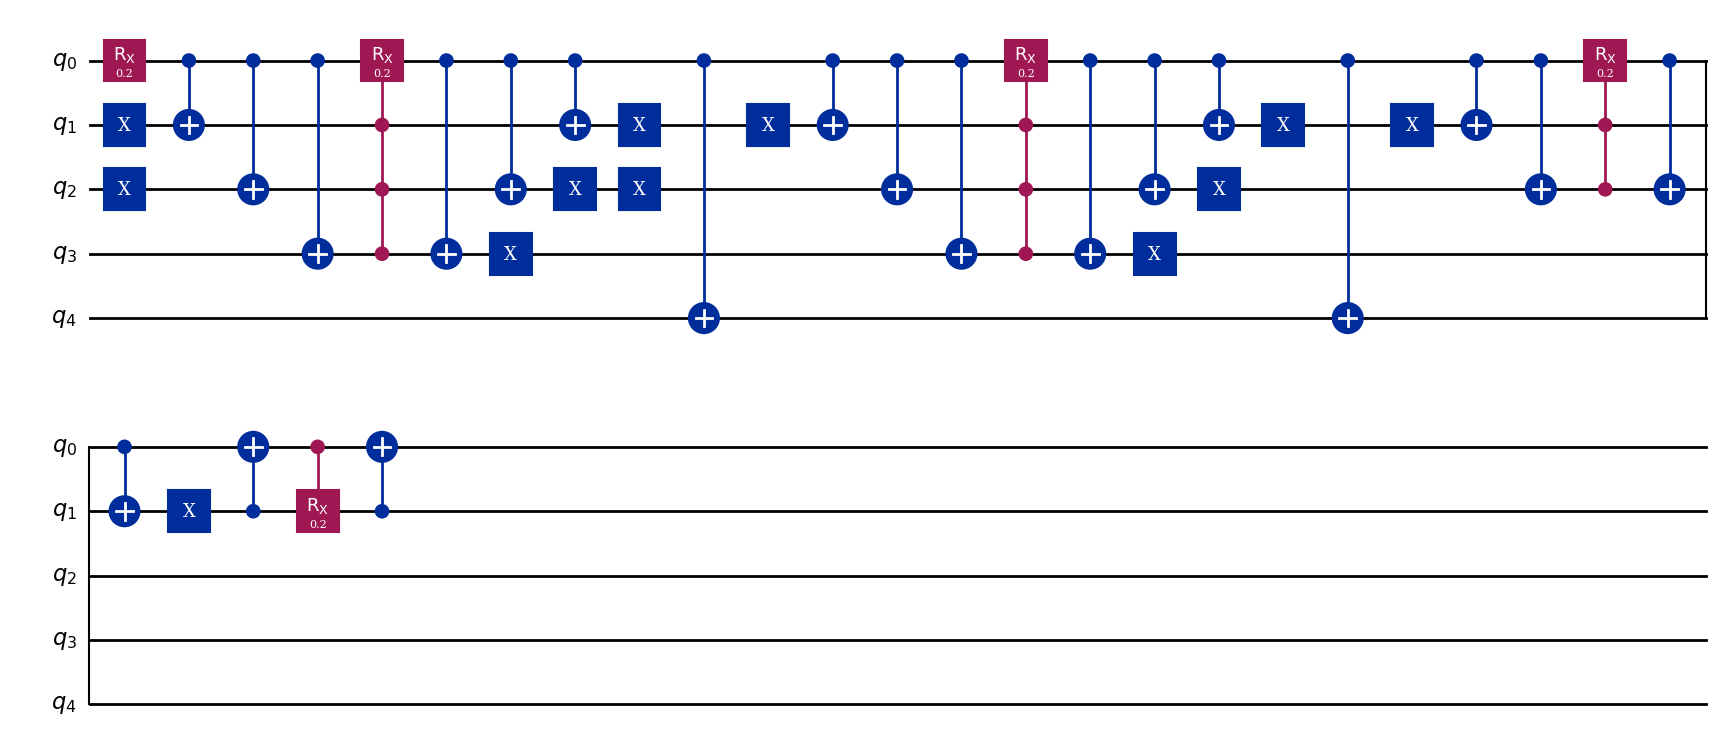


Gate Count Summary (U3/CX) for Cycle C32:
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1          101/70        52/56              101/70            52/56        199/132      123/87
       2         202/140      101/111             202/140          101/111        398/264     240/174
       5         505/350      248/276             505/350          248/276        995/660     591/435
      10        1010/700      493/551            1010/700          493/551      1990/1320    1176/870
      20       2020/1400     983/1101           2020/1400         983/1101      3980/2640   2346/1740
      50       5050/3500    2453/2751           5050/3500        2453/2751      9950/6600   5856/4350
     100      10100/7000    4903/5501          10100/7000        4903/5501    19900/13200  11706/8700

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      56 CX
  Comp-Aware Matching:  56 CX  (+0.0% vs greedy)
  Pauli:           

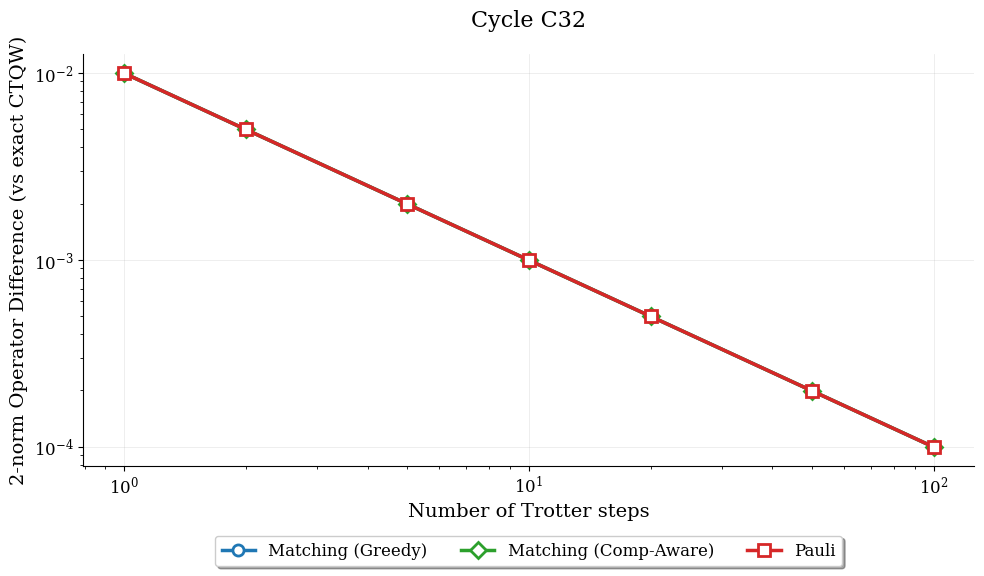

In [25]:
# 5 qubits: Cycle graph C32
cycle_edges = set()
for i in range(32):
    j = (i + 1) % 32
    z1 = format(min(i, j), '05b')
    z2 = format(max(i, j), '05b')
    cycle_edges.add((z1, z2))

analyze_and_plot(cycle_edges, "Cycle C32")


Star S32
Original edges: {('00000', '11000'), ('00000', '10001'), ('00000', '11110'), ('00000', '01000'), ('00000', '11100'), ('00000', '10010'), ('00000', '00111'), ('00000', '00101'), ('00000', '01010'), ('00000', '11011'), ('00000', '00010'), ('00000', '00100'), ('00000', '10100'), ('00000', '10101'), ('00000', '11101'), ('00000', '01111'), ('00000', '00001'), ('00000', '11001'), ('00000', '10111'), ('00000', '00110'), ('00000', '11010'), ('00000', '00011'), ('00000', '01011'), ('00000', '10000'), ('00000', '01110'), ('00000', '11111'), ('00000', '01001'), ('00000', '10110'), ('00000', '01100'), ('00000', '01101'), ('00000', '10011')}
Number of qubits: 5

Graph:


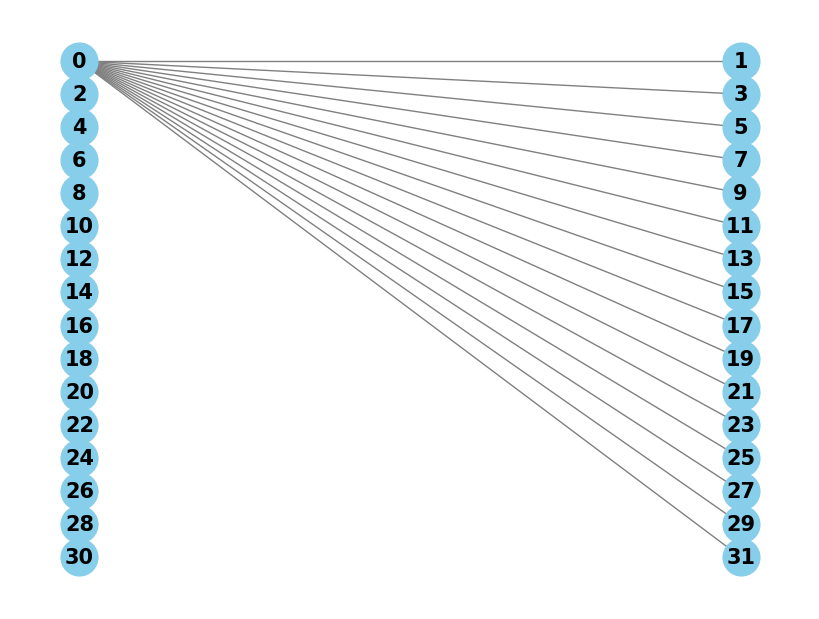

None


Greedy Matchings: 31
Compression-Aware Matchings: 31
Number of qubits: 5

Hamming Cost Analysis:
Total = 80, Edges = 31, Per Edge = 2.581

Sample Circuit - Greedy Matching (n_steps=1):


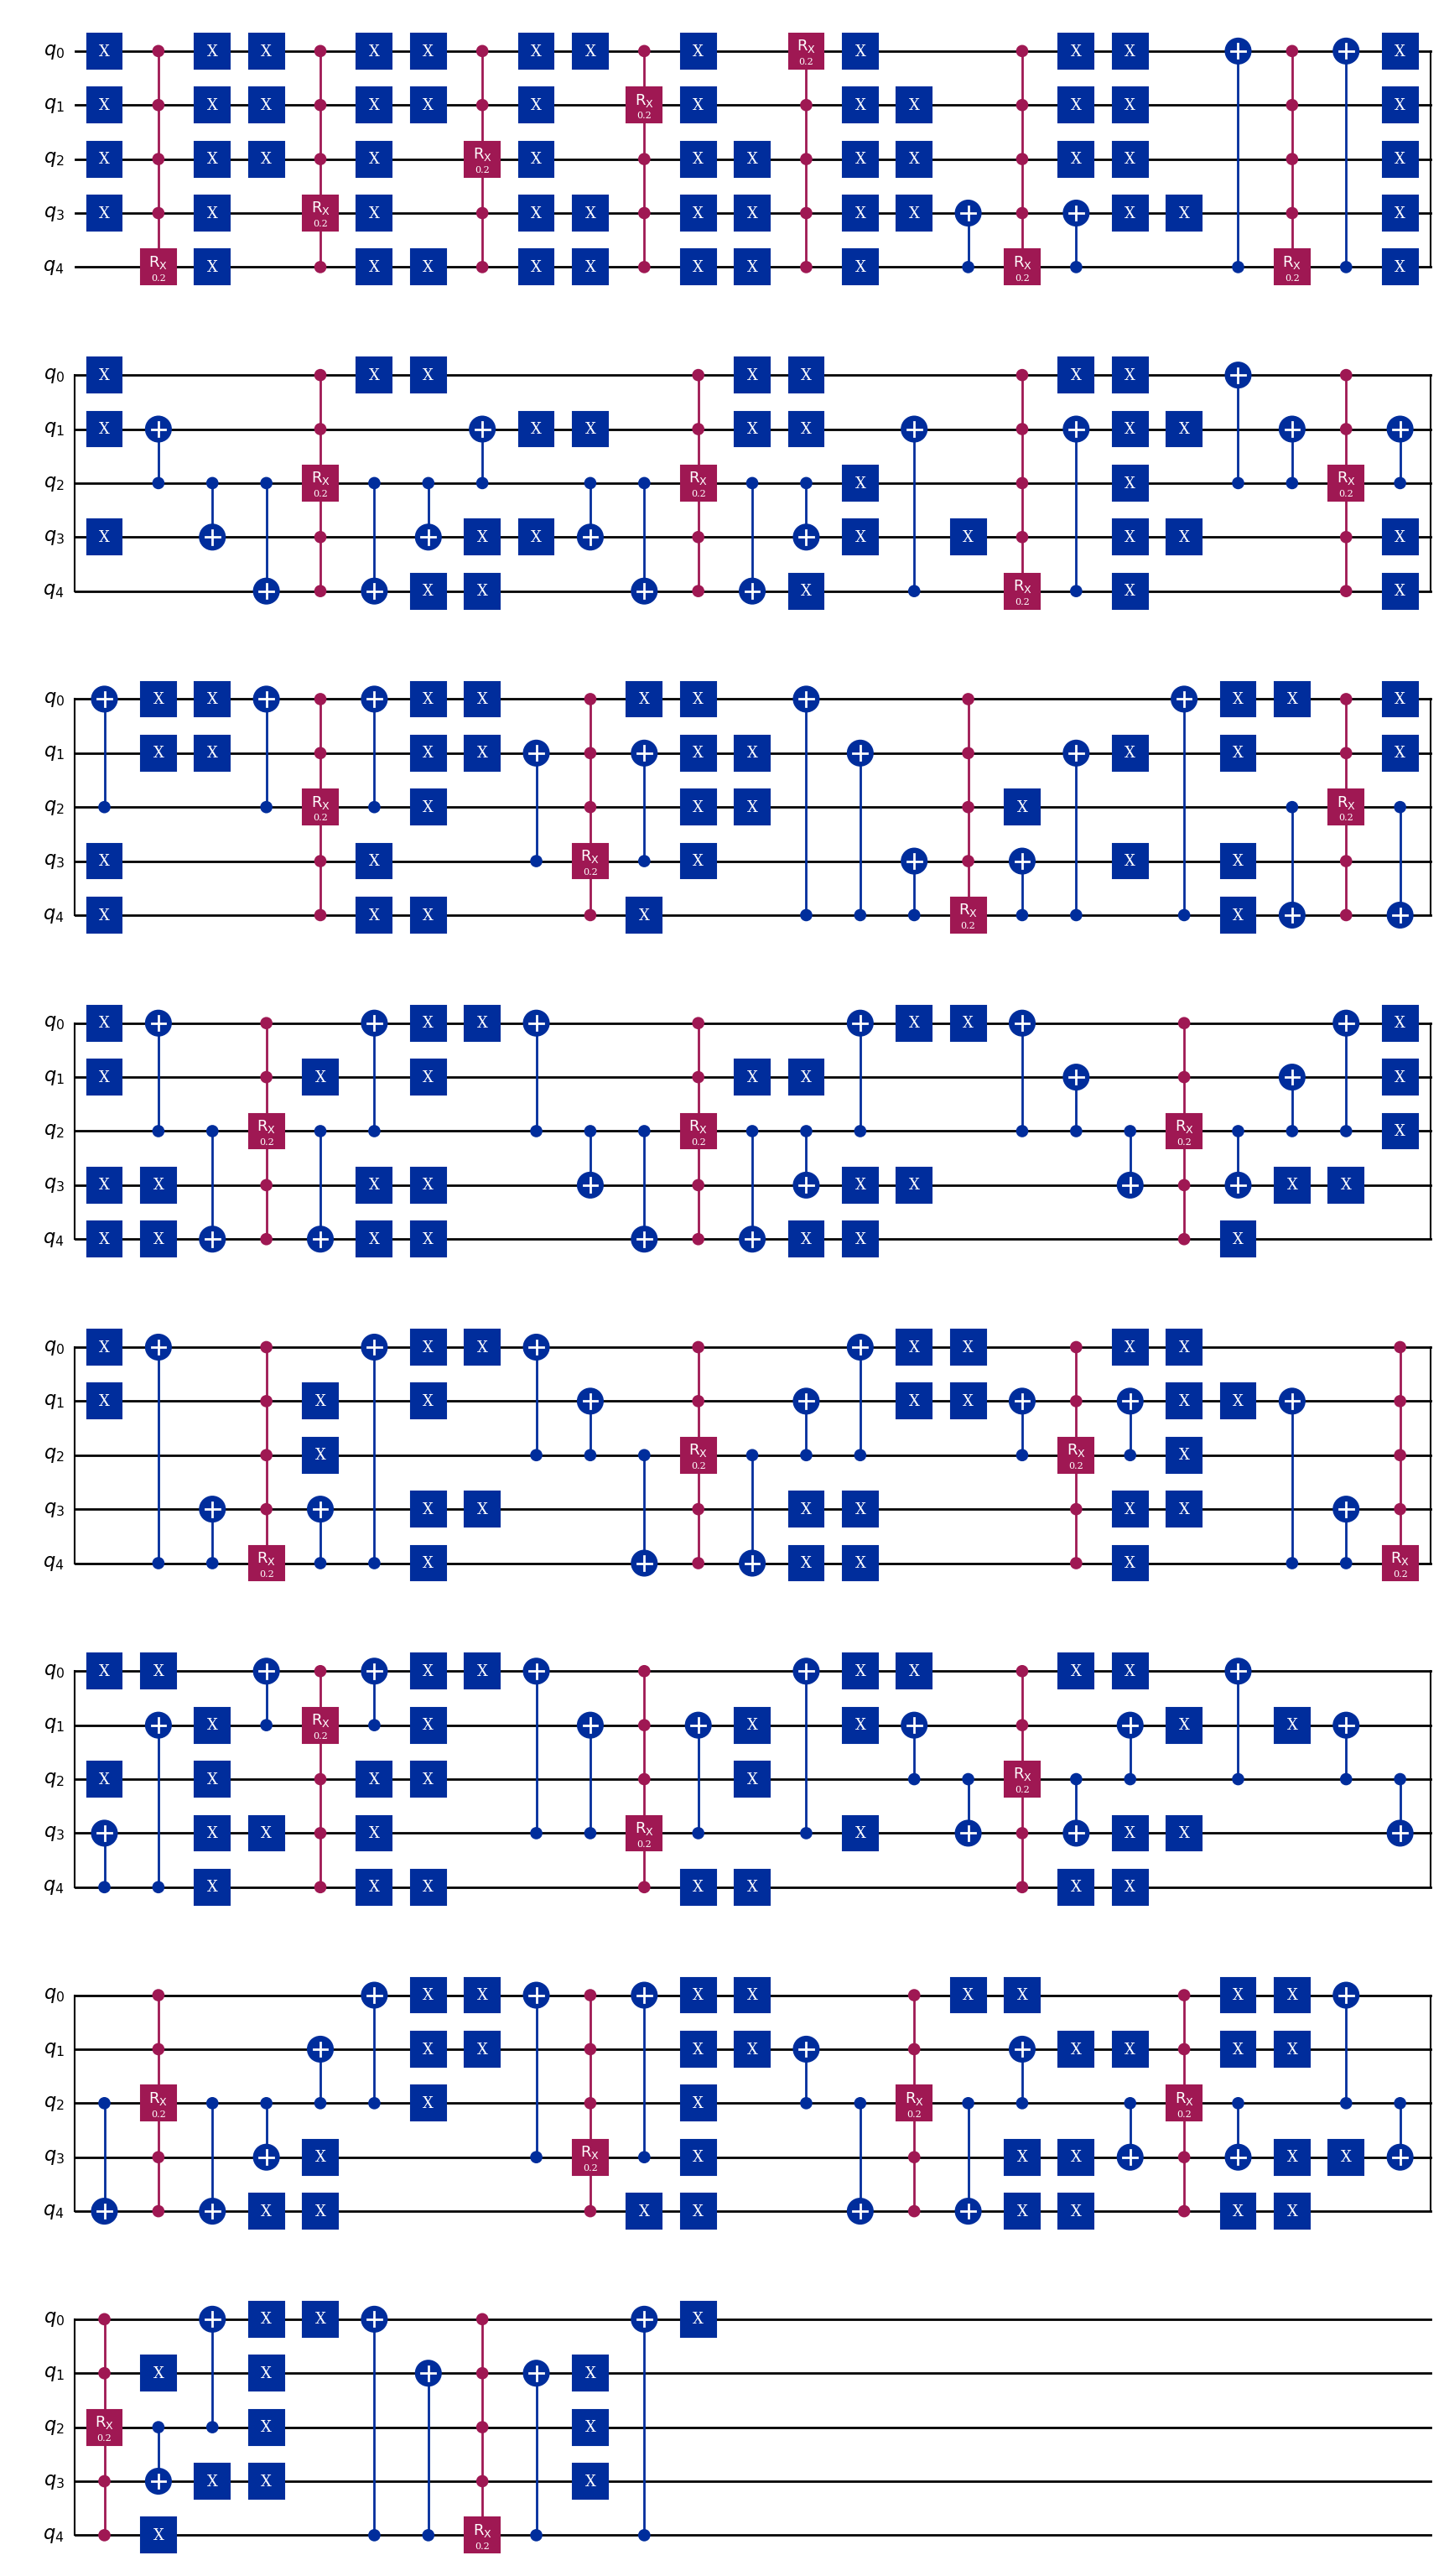


Sample Circuit - Compression-Aware Matching (n_steps=1):


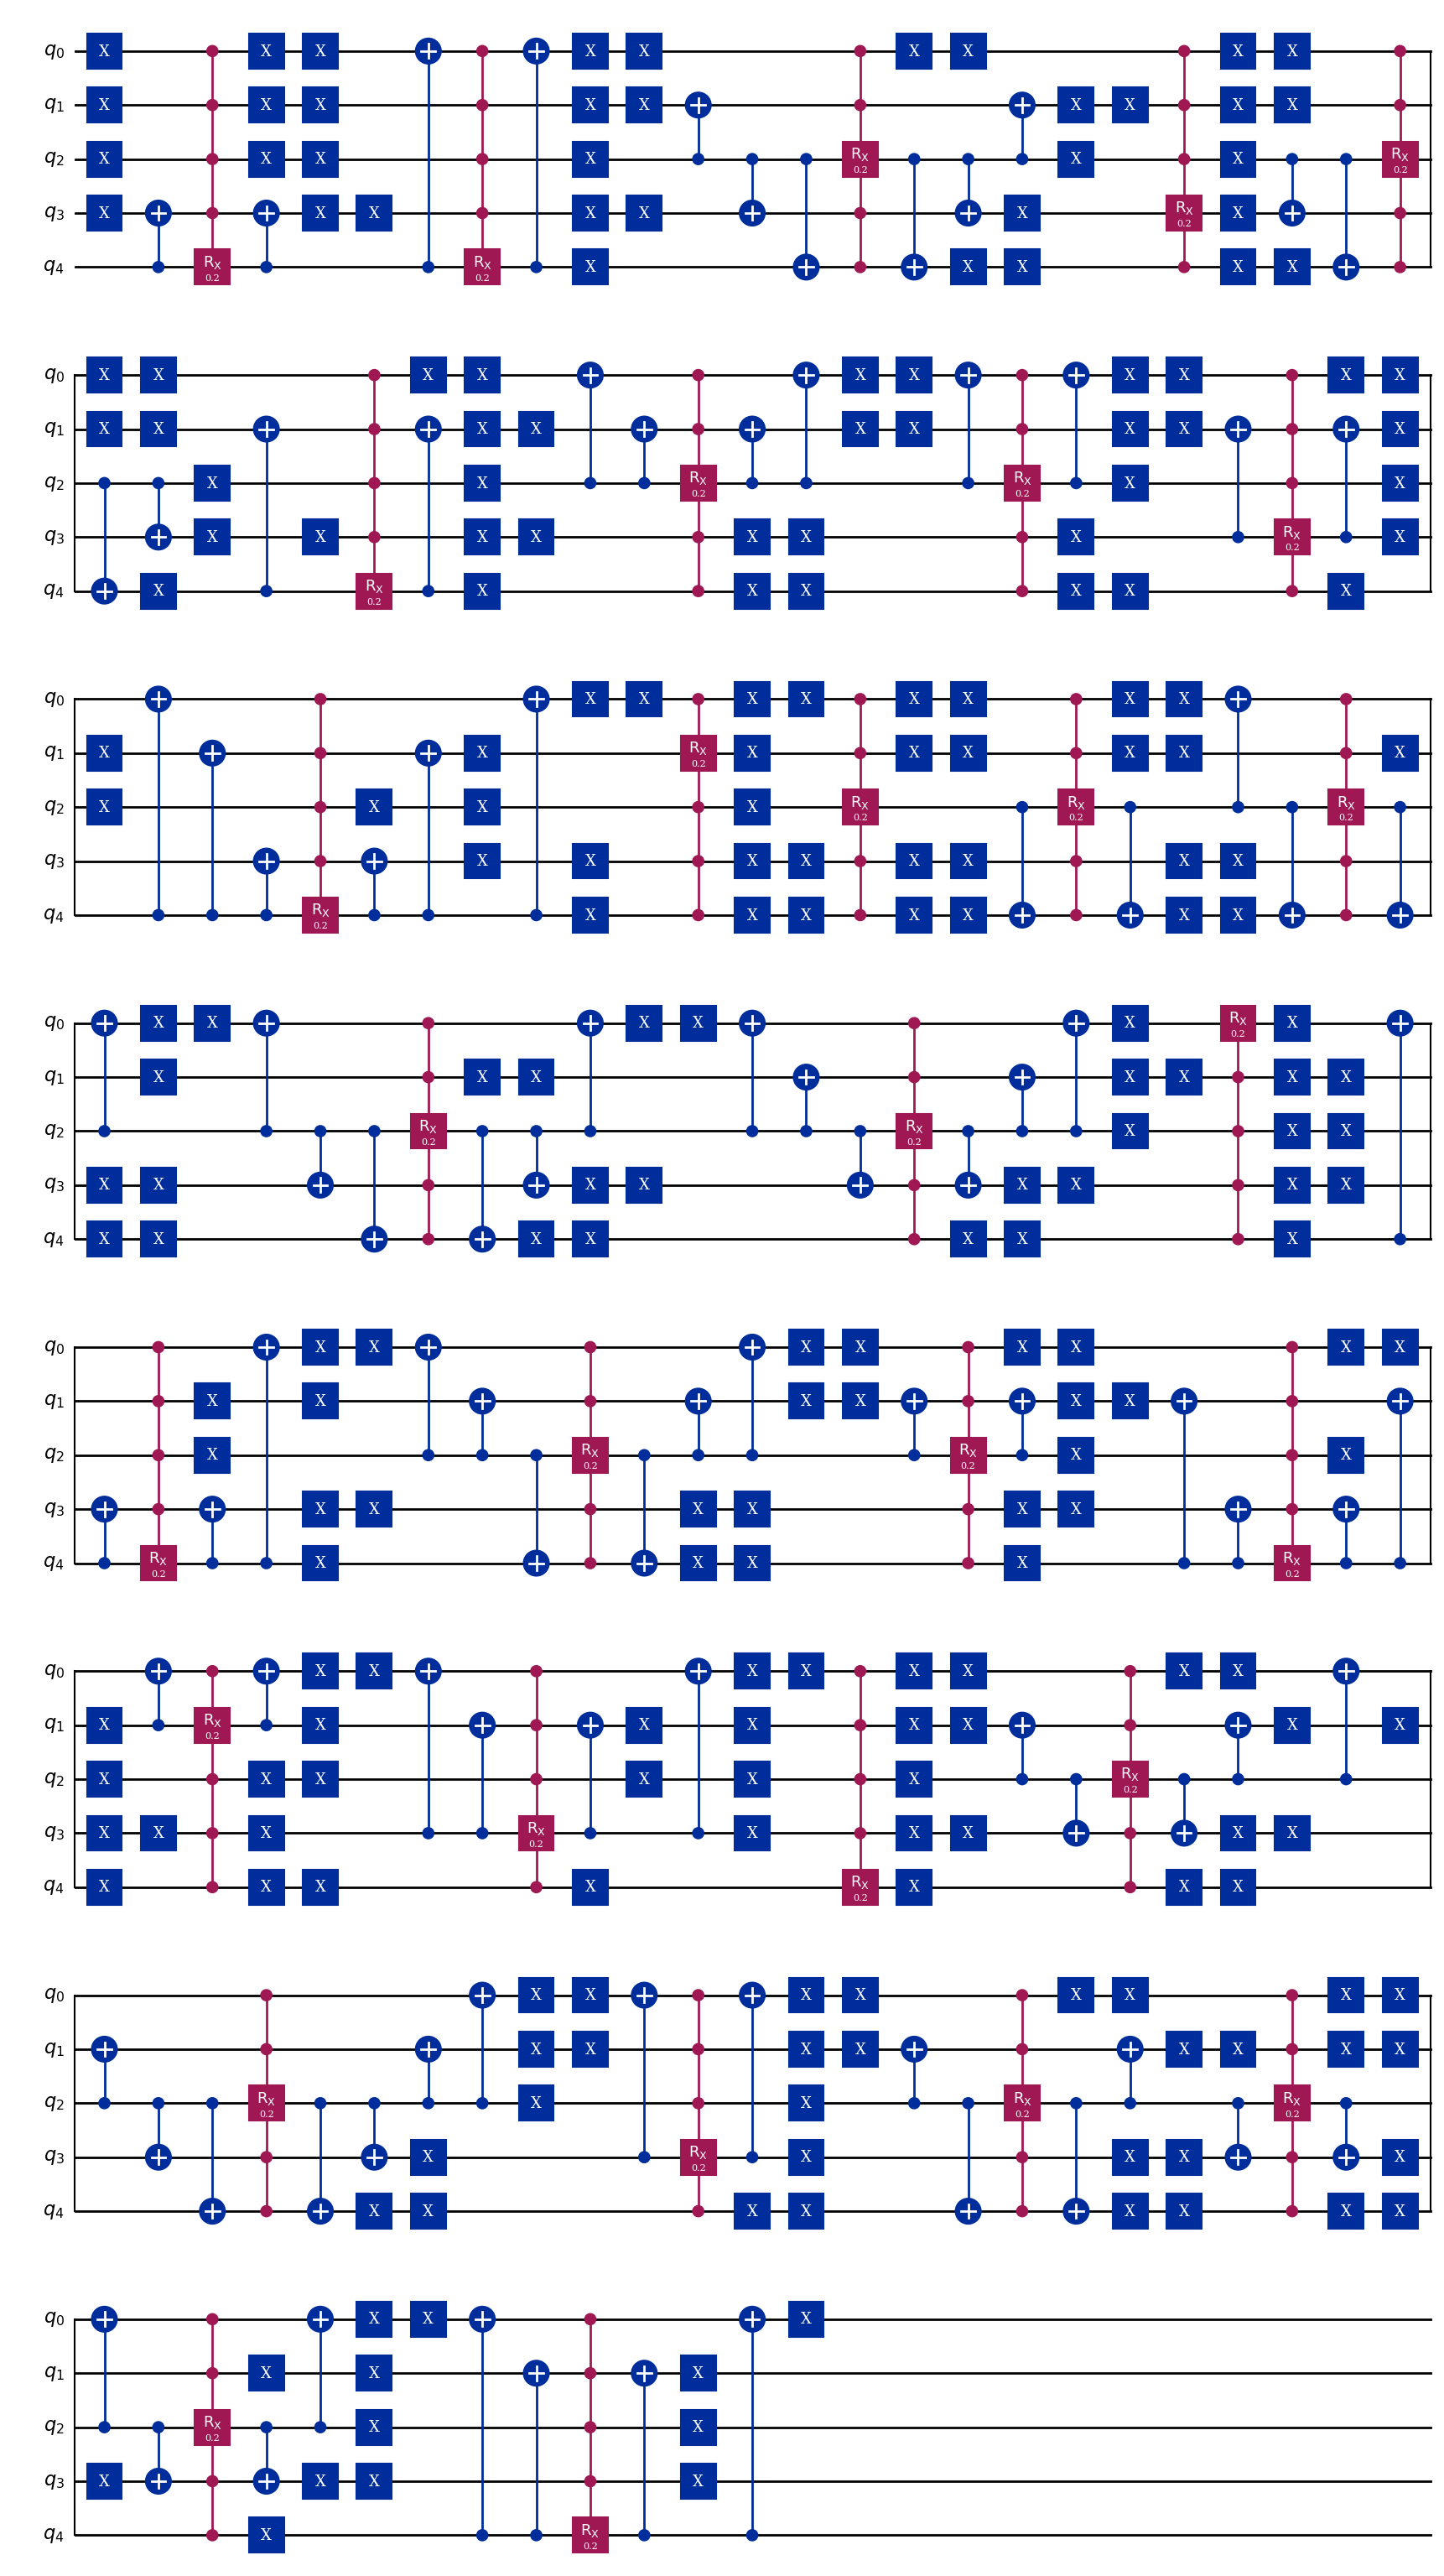


Gate Count Summary (U3/CX) for Star S32:
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt)  Pauli (Opt)
       1        1550/842      832/814            1550/842          828/820      3046/2768     1057/624
       2       3100/1684    1655/1628           3100/1684        1647/1640      6092/5536    2125/1248
       5       7750/4210    4124/4070           7750/4210        4104/4100    15230/13840    5296/3120
      10      15500/8420    8239/8140          15500/8420        8199/8200    30460/27680   10531/6240
      20     31000/16840  16469/16280         31000/16840      16389/16400    60920/55360  21301/12480
      50     77500/42100  41159/40700         77500/42100      40959/41000  152300/138400  52651/31200
     100    155000/84200  82309/81400        155000/84200      81909/82000  304600/276800 105301/62400

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      814 CX
  Comp-Aware Matching:  820 CX  (-0.7% vs greedy)
  Pauli:  

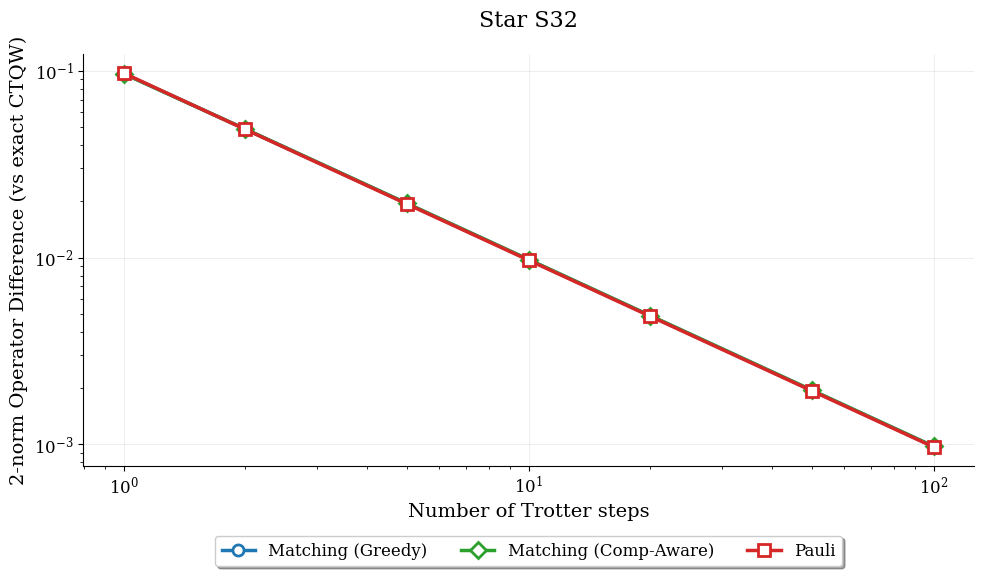

In [26]:
# 5 qubits: Star graph (node 0 connected to all others)
star_edges = set()
node_0 = '00000'
for i in range(1, 32):
    node_i = format(i, '05b')
    star_edges.add((node_0, node_i))

analyze_and_plot(star_edges, "Star S32")


Bipartite K16,16
Original edges: {('00101', '10010'), ('00111', '10001'), ('01010', '10011'), ('01011', '10011'), ('00001', '10100'), ('00111', '11100'), ('01001', '10000'), ('01001', '11111'), ('01111', '10100'), ('00110', '11011'), ('00100', '10100'), ('00010', '11010'), ('01101', '10101'), ('01110', '10000'), ('00010', '11111'), ('01001', '10011'), ('00000', '10010'), ('01100', '11010'), ('00101', '11101'), ('01010', '11110'), ('01101', '11101'), ('01011', '11110'), ('00111', '10100'), ('01110', '10001'), ('01101', '11001'), ('01010', '11011'), ('01110', '11100'), ('00011', '10010'), ('01000', '10010'), ('01011', '11011'), ('01100', '10110'), ('00110', '10111'), ('00010', '11110'), ('00110', '11001'), ('01100', '11000'), ('01010', '10101'), ('01101', '10000'), ('01101', '11111'), ('00101', '11111'), ('01001', '11011'), ('01100', '11110'), ('00111', '10111'), ('00010', '11011'), ('00101', '10011'), ('01101', '10011'), ('01110', '10100'), ('00110', '10000'), ('00000', '11010'), ('010

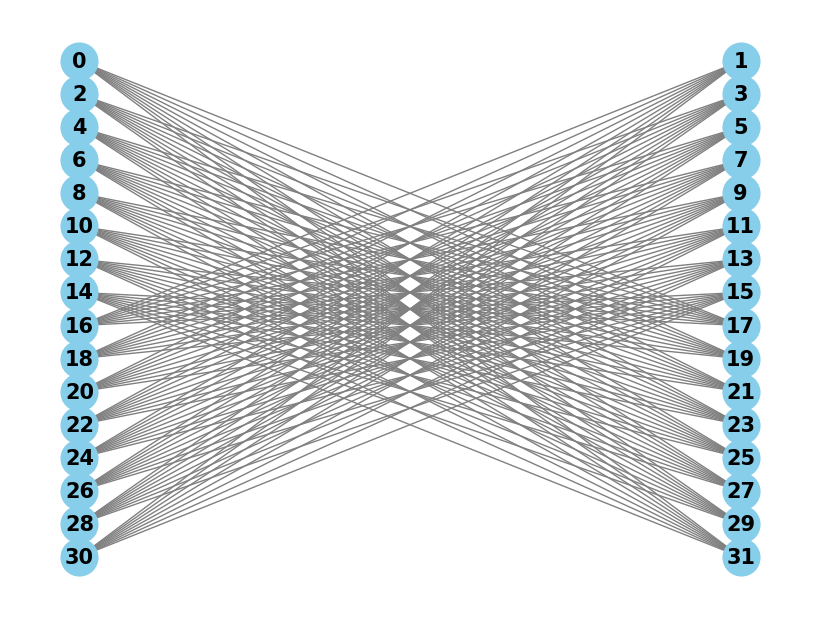

None


Greedy Matchings: 16
Compression-Aware Matchings: 16
Number of qubits: 5

Hamming Cost Analysis:
Total = 768, Edges = 256, Per Edge = 3.000

Sample Circuit - Greedy Matching (n_steps=1):


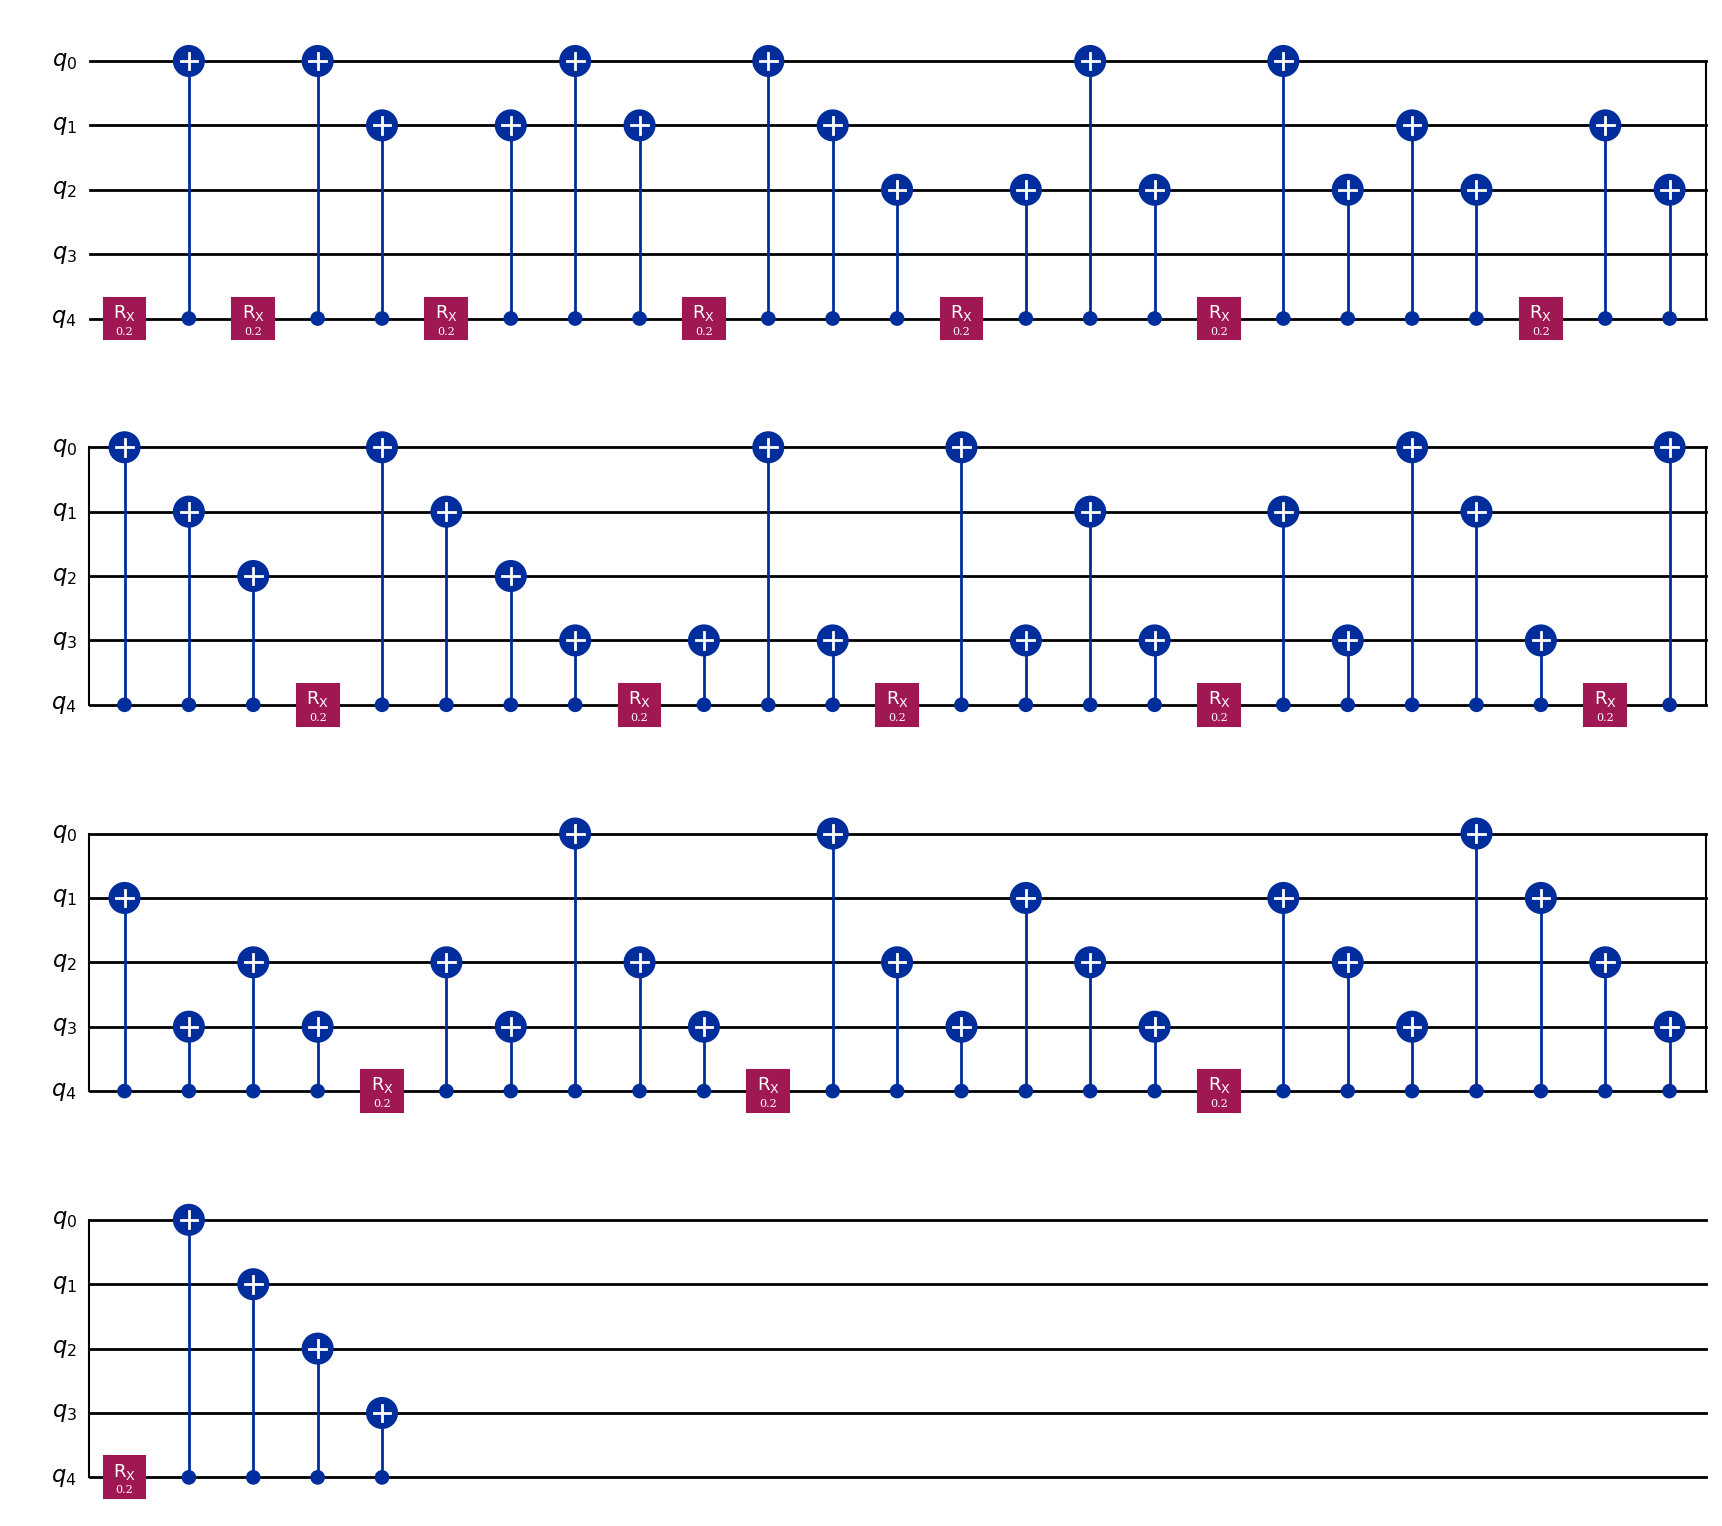


Sample Circuit - Compression-Aware Matching (n_steps=1):


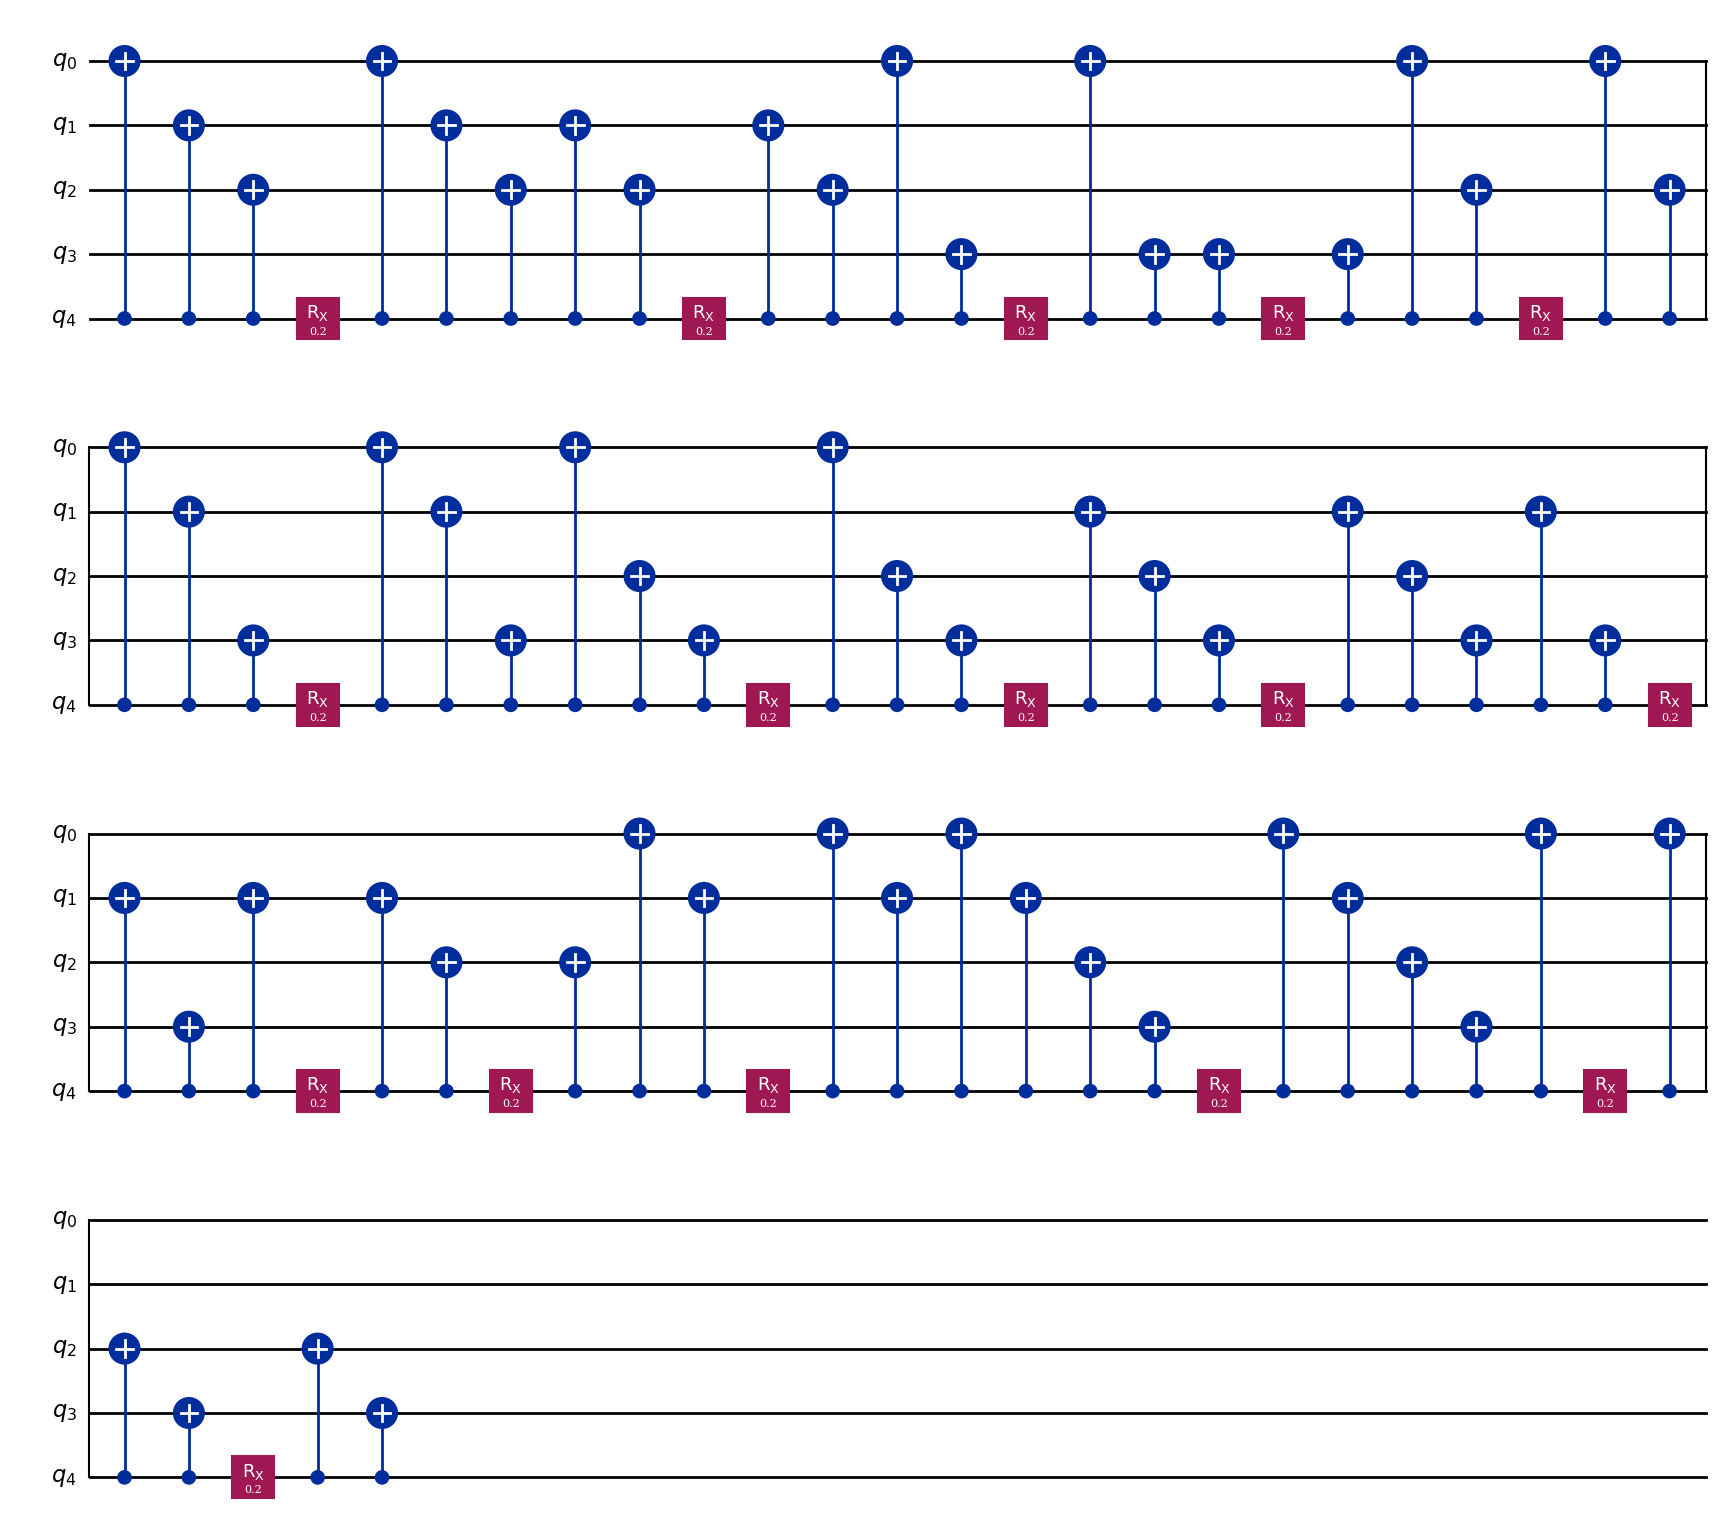


Gate Count Summary (U3/CX) for Bipartite K16,16:
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1           16/64        16/30               16/64            16/40         110/64       43/30
       2          32/128        32/60              32/128            32/78        220/128       77/60
       5          80/320       80/150              80/320           80/192        550/320     188/150
      10         160/640      160/300             160/640          160/382       1100/640     373/300
      20        320/1280      320/600            320/1280          320/762      2200/1280     743/600
      50        800/3200     800/1500            800/3200         800/1902      5500/3200   1856/1500
     100       1600/6400    1600/3000           1600/6400        1600/3802     11000/6400   3706/3000

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      30 CX
  Comp-Aware Matching:  40 CX  (-33.3% vs greedy)
  Pauli:   

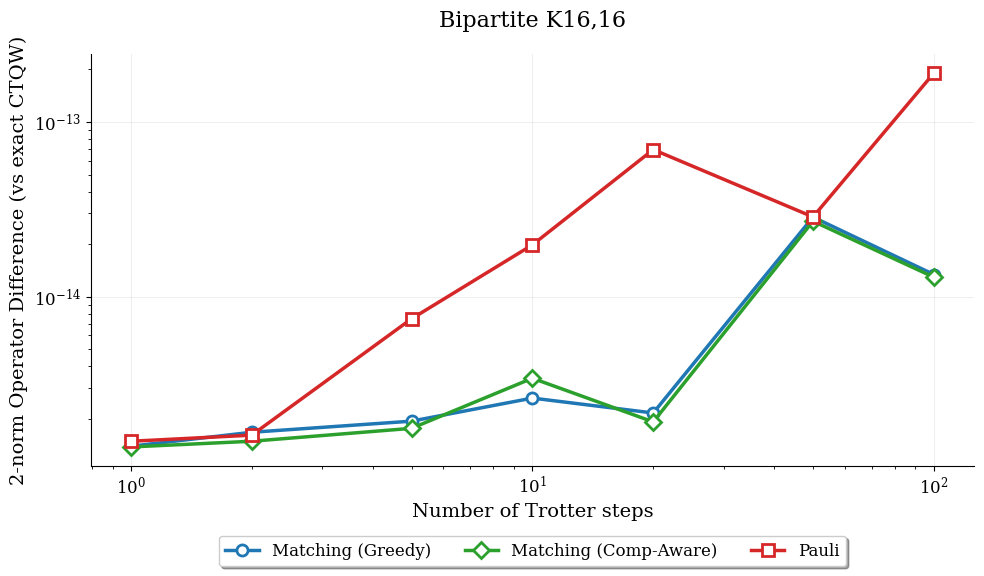

In [27]:
# 5 qubits: Complete bipartite K16,16
bipartite_edges = set()
# Connect all nodes with MSB=0 to all nodes with MSB=1
for i in range(16):
    node_i = format(i, '05b')  # MSB=0
    for j in range(16, 32):
        node_j = format(j, '05b')  # MSB=1
        bipartite_edges.add((node_i, node_j))

analyze_and_plot(bipartite_edges, "Bipartite K16,16")


Peterson Graph
Original edges: {('010', '011'), ('010', '111'), ('100', '000'), ('000', '001'), ('111', '001'), ('101', '111'), ('110', '000'), ('000', '101'), ('011', '100'), ('001', '010'), ('100', '001'), ('011', '000'), ('001', '110')}
Number of qubits: 3

Graph:


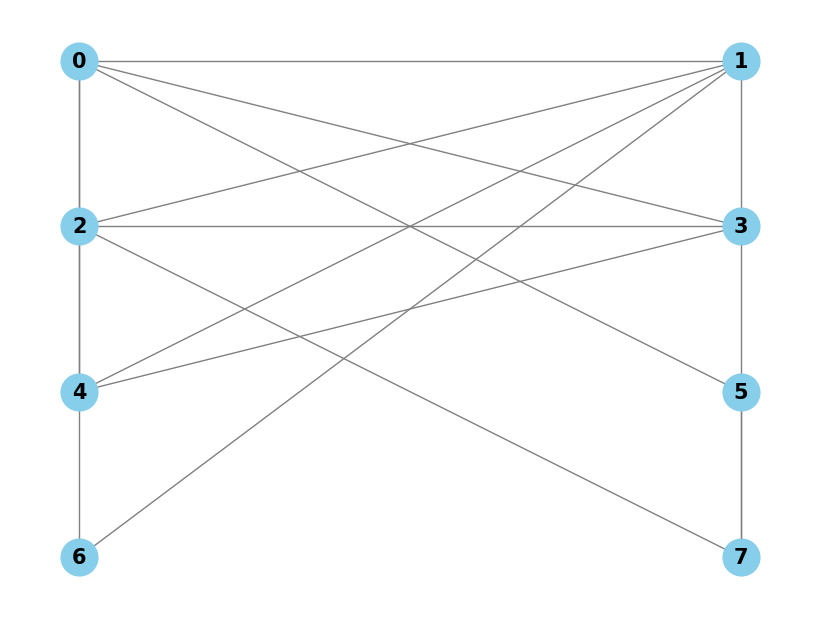

None


Greedy Matchings: 5
Compression-Aware Matchings: 6
Number of qubits: 3

Hamming Cost Analysis:
Total = 24, Edges = 13, Per Edge = 1.846

Sample Circuit - Greedy Matching (n_steps=1):


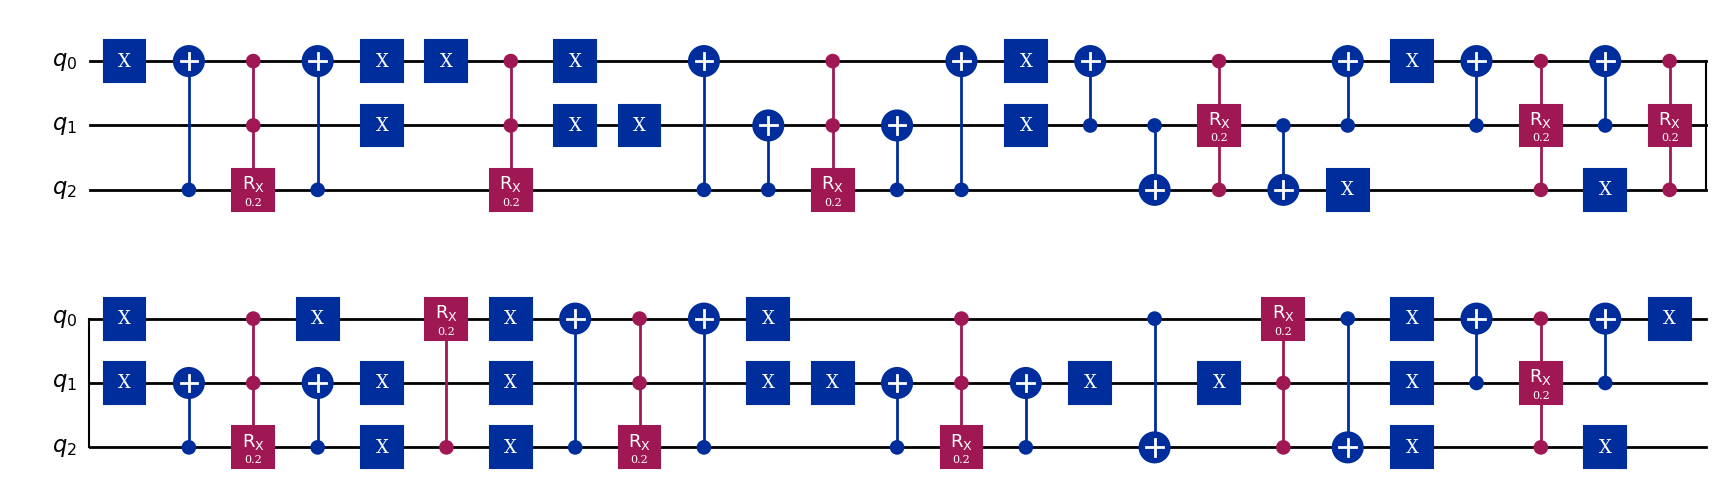


Sample Circuit - Compression-Aware Matching (n_steps=1):


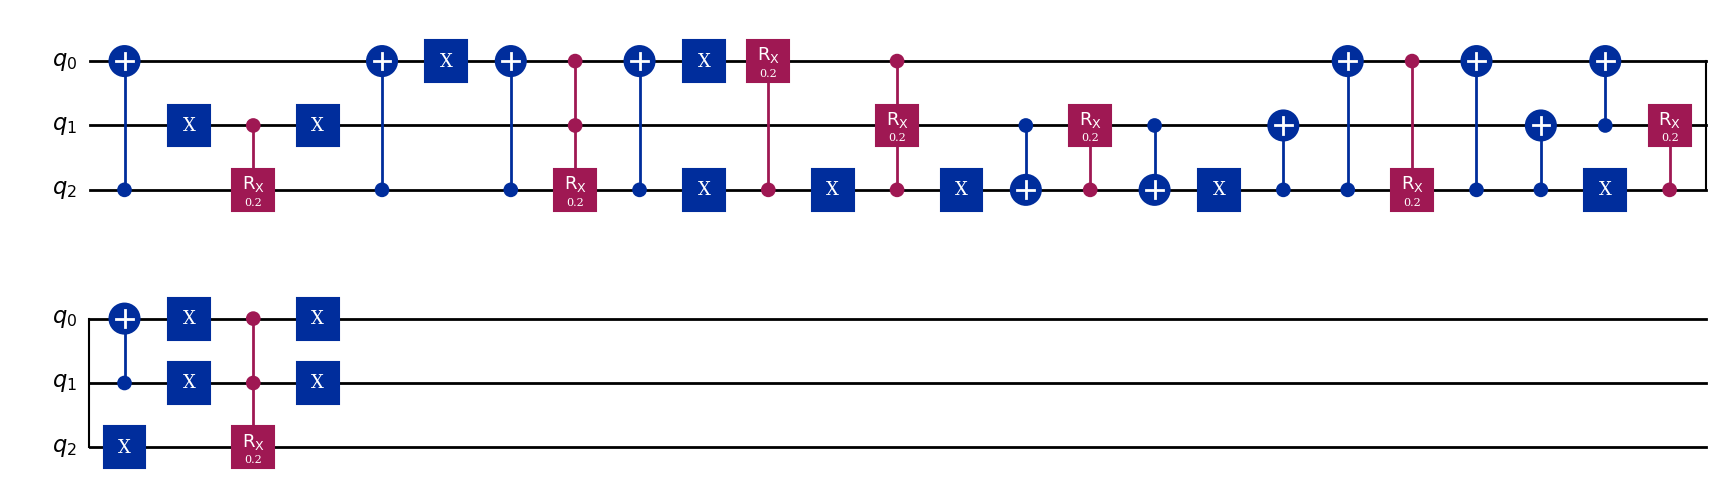


Gate Count Summary (U3/CX) for Peterson Graph:
 n_steps Greedy (No Opt) Greedy (Opt) Comp-Aware (No Opt) Comp-Aware (Opt) Pauli (No Opt) Pauli (Opt)
       1         198/112       120/98               74/46            46/34          78/48       44/26
       2         396/224      239/196              148/92            91/67         156/96       86/52
       5         990/560      596/490             370/230          226/166        390/240     207/130
      10       1980/1120     1191/980             740/460          451/331        780/480     422/260
      20       3960/2240    2381/1960            1480/920          901/661       1560/960     822/520
      50       9900/5600    5951/4900           3700/2300        2251/1651      3900/2400   2102/1300
     100     19800/11200   11901/9800           7400/4600        4501/3301      7800/4800   4102/2600

--- CX Summary (n_steps=1, optimized) ---
  Greedy Matching:      98 CX
  Comp-Aware Matching:  34 CX  (+65.3% vs greedy)
  Pauli:     

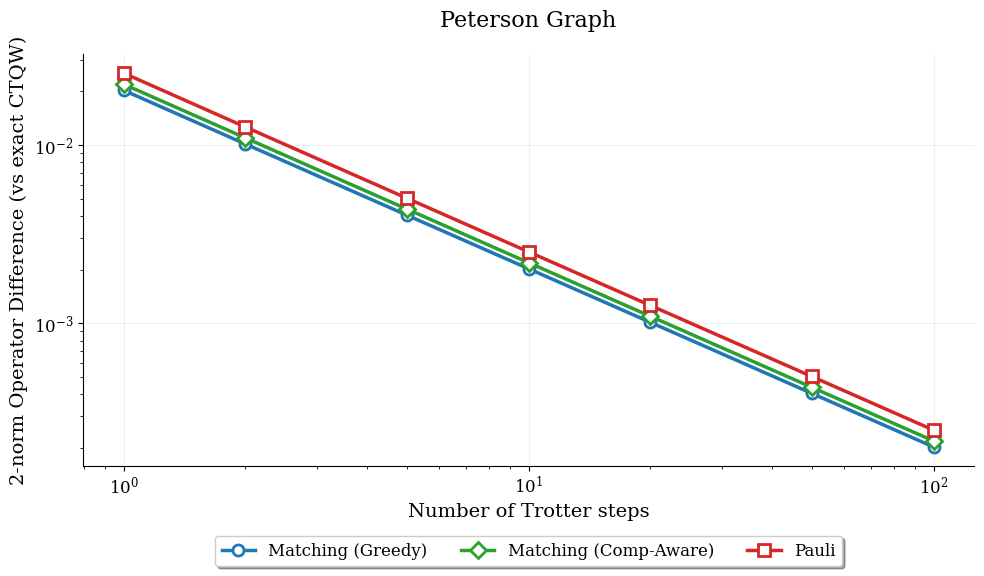

In [28]:
# Peterson graph (needs 10 nodes, we'll use first 10 of 3-qubit space)
# Outer pentagon: 0-1-2-3-4-0
# Inner pentagram: 5-7-9-6-8-5
# Connections: 0-5, 1-6, 2-7, 3-8, 4-9
peterson_edges = {
    # Outer pentagon (using 3-bit labels)
    ('000', '001'), ('001', '010'), ('010', '011'), ('011', '100'), ('100', '000'),
    # Inner pentagram
    ('101', '111'), ('111', '001'), ('001', '110'), ('110', '000'), ('000', '101'),
    # Spoke connections
    ('000', '101'), ('001', '110'), ('010', '111'), ('011', '000'), ('100', '001')
}

analyze_and_plot(peterson_edges, "Peterson Graph")